In [1]:
# @title Install

# !pip uninstall -y tensorflow jax jaxlib

# !pip install pytorch-ignite
# !pip install ipynbname
# !pip install lightning
# !pip install torch_tb_profiler
# !pip install colormaps
# !pip install captum

In [2]:
# @title Importing

from __future__ import annotations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.profiler import schedule
import torchmetrics
from ignite.engine import Events
from ignite.metrics import Metric, Loss
from ignite.handlers import global_step_from_engine, EarlyStopping
from torch.optim.lr_scheduler import _LRScheduler, ReduceLROnPlateau, CosineAnnealingWarmRestarts, ChainedScheduler
from ignite.contrib.handlers import TensorboardLogger
from ignite.contrib.handlers.tensorboard_logger import *
from ignite.exceptions import NotComputableError

import lightning as L
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, ModelSummary
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from lightning.pytorch.profilers import SimpleProfiler, PyTorchProfiler
from lightning.pytorch.utilities.warnings import PossibleUserWarning

from torch.optim.lr_scheduler import SequentialLR

from captum.attr import Saliency, IntegratedGradients, Occlusion, GradientShap
import shap
import joblib

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import FastICA
from sklearn.metrics import r2_score

import statsmodels.api as sm
from statsmodels.multivariate.factor_rotation import promax

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib import colors
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import colormaps as cmaps
import plotly.graph_objects as go

from tqdm.auto import tqdm

import seaborn as sns

from scipy import stats
from scipy.stats import norm, ttest_rel
import scipy.io as sio
from scipy.interpolate import griddata

from joblib import Parallel, delayed

import numpy as np
import pandas as pd
import datetime
import time
import os
import sys
import glob
import ipynbname
import pickle
import json
import math
import warnings
import copy
import logging
import random

logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)

warnings.filterwarnings("ignore", category=PossibleUserWarning)
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=r".*Checkpoint directory .* exists and is not empty.*", category=UserWarning, module=r"lightning\.pytorch\.callbacks\.model_checkpoint")
seed = 1
torch.manual_seed(seed)
np.random.seed(seed)
rng = np.random.default_rng(seed)

torch.set_float32_matmul_precision("high")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


C:\Users\The_Death\AppData\Local\Temp\ipykernel_20336\2043987054.py:17: DeprecationWarning: g:\Neurosicenc\workspace\env\Lib\site-packages\ignite\contrib\handlers\tensorboard_logger.py has been moved to /ignite/handlers/tensorboard_logger.py and will be removed in version 0.6.0.
 Please refer to the documentation for more details.
  from ignite.contrib.handlers.tensorboard_logger import *


In [37]:
# @title Configuration

RESULTS: str = "./results_full/"            
FIGURES: str = "./figures_full/"  

def ensure_dirs() -> None:
    """Create the results/ and figures/ output directories if absent."""
    os.makedirs(RESULTS, exist_ok=True)
    os.makedirs(FIGURES, exist_ok=True)

def seed_everything(seed, deterministic=True):
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = deterministic
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    torch.set_float32_matmul_precision("highest")
    torch.use_deterministic_algorithms(deterministic, warn_only=False)

SEED = 1
seed_everything(SEED)

class DotDict(dict):
    def __init__(self, d=None):
        super().__init__()
        if d:
            for k, v in d.items():
                self[k] = self._wrap(v)

    def _wrap(self, value):
        if isinstance(value, dict):
            return DotDict(value)
        if isinstance(value, list):
            return [self._wrap(v) for v in value]
        return value

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = self._wrap(value)

    def __delattr__(self, name):
        try:
            del self[name]
        except KeyError:
            raise AttributeError(name)

    def to_dict(self):
        out = {}
        for k, v in self.items():
            if isinstance(v, DotDict):
                out[k] = v.to_dict()
            elif isinstance(v, list):
                out[k] = [x.to_dict() if isinstance(x, DotDict) else x for x in v]
            else:
                out[k] = v
        return out

    def __deepcopy__(self, memo):
        return DotDict(copy.deepcopy(self.to_dict(), memo))


Conf = DotDict({
    "run_id": 1,
    "seed": SEED,
    "paths": {
        "data": "data_new.mat",
        "logs": "/lightning_logs",
    },
    "session_idx": 18,
    "device": device,
    "training": {
        "batch_size": 256,
        "max_epoch": 500,
        "min_delta": 1e-4,
        "patience": 20,
        "n_seeds": 10,          # number of random seeds per fold for stability testing
    },
    "model_type": {
        "name": "mean",
        "mean": {
            "n_hidden": 16,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
        "cov": {
            "n_latent": 32,
            "n_hidden": 4,
            "n_heads": 2,
            "n_layers": 1,
            "nonlinearity": "gelu",
            "dropout": 0,
        },
    },
    "optimization": {
        "optimizer_type": {
            "name": "Adam",
            "Adam": {
                "lr": 0.01,
                "weight_decay": 0,
            },
            "AdamW": {
                "lr": 0.01,
                "weight_decay": 0,
            },
        },
        "scheduler_type": {
            "name": "Reduce",
            "Reduce": {
                "factor": 0.5,
                "patience":5,
                "min_lr": 1e-10,
            },
            "Cosine": {
                "T_mult": 1,
                "eta_min": 1e-5,
                "last_epoch": -1,
            }
        }
    }
})

os.makedirs(FIGURES, exist_ok=True)
os.makedirs(RESULTS, exist_ok=True)

# Allow PyTorch to safely unpickle the Conf dict inside checkpoints
import torch
if hasattr(torch.serialization, 'add_safe_globals'):
    torch.serialization.add_safe_globals([DotDict])


In [4]:
# @title Model

class Model(nn.Module):
    def __init__(self, Conf=None, **kwargs):
        super().__init__()
        self.n_position_vars = Conf.data.n_position_vars
        self.n_dense_vars = Conf.data.n_dense_vars
        self.n_sparse_vars = Conf.data.n_sparse_vars
        self.n_vars = Conf.data.n_vars
        self.n_bins = Conf.data.n_bins
        self.n_units = Conf.data.n_units
        self.device = Conf.device


class Time2Vec(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.w0 = nn.Parameter(torch.randn(1))
        self.b0 = nn.Parameter(torch.randn(1))
        self.w = nn.Parameter(torch.randn(n_hidden - 1))
        self.b = nn.Parameter(torch.randn(n_hidden - 1))

    def forward(self, t):
        t = t.unsqueeze(-1)
        linear = self.w0 * t + self.b0
        periodic = torch.sin(self.w * t + self.b)
        return torch.cat([linear, periodic], dim=-1)


class Time2VecPositionalEncoding(nn.Module):
    def __init__(self, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        self.t2v = Time2Vec(n_hidden)

    def forward(self, n_bins, device):
        t = torch.arange(n_bins, device=device).float()
        enc = self.t2v(t)
        return enc.unsqueeze(0)


class Transformer():
    def __init__(self, Conf=None, **kwargs):
        super().__init__(Conf=Conf, **kwargs)
        self.n_hidden = Conf.model_type[Conf.model_type.name].n_hidden
        self.n_heads = Conf.model_type[Conf.model_type.name].n_heads
        self.n_layers = Conf.model_type[Conf.model_type.name].n_layers
        self.nonlinearity = Conf.model_type[Conf.model_type.name].nonlinearity
        self.dropout = Conf.model_type[Conf.model_type.name].dropout

        self.sparse_var_embeds = nn.ModuleList([
            nn.Linear(1, 1) for _ in range(self.n_sparse_vars)
        ])
        
        self.dense_vars_proj = nn.Linear(self.n_dense_vars, self.n_dense_vars)
        self.position_vars_proj = nn.Linear(self.n_position_vars, self.n_position_vars)
        self.vars_proj = nn.Linear(self.n_vars, self.n_hidden)
        
        self.positional_encoding = Time2VecPositionalEncoding(self.n_hidden)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.n_hidden,
            nhead=self.n_heads,
            dim_feedforward=self.n_hidden * 4,
            dropout=self.dropout,
            activation=self.nonlinearity,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=self.n_layers)
        self.dropout_layer = nn.Dropout(self.dropout)
        

    def forward_transformer(self, x):
        x_position_vars, x_dense_vars, x_sparse_vars = x
        
        sparse_vars = torch.stack([self.sparse_var_embeds[i](x_sparse_vars[:, i].unsqueeze(-1)) for i in range(x_sparse_vars.size(1))], dim=1).squeeze(-1)
        sparse_vars = sparse_vars.unsqueeze(1).expand(-1, self.n_bins, -1)
        dense_vars = self.dense_vars_proj(x_dense_vars).unsqueeze(1)
        dense_vars = dense_vars.expand(-1, self.n_bins, -1)
        position_vars = self.position_vars_proj(x_position_vars)
        stacked = torch.cat([position_vars, dense_vars, sparse_vars], dim=2)
        stacked = self.vars_proj(stacked)
        
        pos_enc = self.positional_encoding(self.n_bins, stacked.device)
        combined = stacked + pos_enc
        transformed = self.transformer_encoder(combined)
        transformed = self.dropout_layer(transformed)
        return transformed


class MeanModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)


class ZeroMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        batchsize = x[0].size(0)
        return torch.zeros(batchsize, self.n_bins, self.n_units, device=x[0].device, dtype=x[0].dtype)


class BaselineMeanModel(MeanModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.theta = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            nn.init.normal_(self.theta, mean=0, std=1e-1)
            
    def forward(self, x):
        batch_size = x[0].size(0)
        mean = self.theta
        return mean.view(1, self.n_bins, self.n_units).expand(batch_size, -1, -1)


class ConditionalMeanModel(Transformer, MeanModel):
    def __init__(self, Conf):
        Conf_ = copy.deepcopy(Conf)
        Conf_.model_type.name = "mean"
        super().__init__(Conf=Conf_)

        self.output_size = self.n_units
        self.head = nn.Linear(self.n_hidden, self.output_size)

    def forward(self, x):
        transformed = self.forward_transformer(x)
        mean = self.head(transformed)
        return mean
             

class CovModel(Model):
    def __init__(self, Conf):
        super().__init__(Conf)
        self.n_latent = Conf.model_type.cov.n_latent
        
        self.register_buffer("I", torch.eye(self.n_bins * self.n_units, dtype=torch.float32, device=self.device))
        self.length_scales = nn.Parameter(torch.empty(self.n_latent, device=self.device))
        self.noise = nn.Parameter(torch.empty(self.n_bins, self.n_units, device=self.device))

        with torch.no_grad():
            ls0 = math.log(math.expm1(0.5))
            self.length_scales.fill_(ls0)
            nn.init.normal_(self.length_scales, mean=ls0, std=1)
            nn.init.normal_(self.noise, mean=-20.0, std=1)

    def kernel(self, fun, n_samples1, n_samples2, l):
        i_grid = torch.arange(n_samples1, dtype=torch.float32, device=l.device).view(-1, 1)
        j_grid = torch.arange(n_samples2, dtype=torch.float32, device=l.device).view(1, -1)
        return fun(i_grid, j_grid, l)

    def squared_exponential_kernel(self, x1, x2, l):
        distances = (x2 - x1).unsqueeze(0)
        frac = distances / l.unsqueeze(-1).unsqueeze(-1)
        return torch.exp(-0.5 * (frac**2))
    
    def build_covariance_matrix(self, lambda_matrix):
        l = F.softplus(self.length_scales)
        K = self.kernel(self.squared_exponential_kernel, self.n_bins, self.n_bins, l=l)
    
        blocks = torch.einsum('btok,kts,bsuk->btosu', lambda_matrix, K, lambda_matrix)
        cov = blocks.reshape(
            lambda_matrix.size(0),
            self.n_bins * self.n_units,
            self.n_bins * self.n_units
        )
    
        cov = cov + self.I.unsqueeze(0)
        noise_diag = torch.sigmoid(self.noise.flatten())
        cov.diagonal(dim1=-2, dim2=-1).add_(noise_diag)
    
        L = torch.linalg.cholesky(cov)
        return L


class IdentityCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)

    def forward(self, x):
        return self.I.unsqueeze(0)
            

class SharedCovModel(CovModel):
    def __init__(self, Conf):
        super().__init__(Conf)
        
        self.lambda_matrix = nn.Parameter(torch.empty(self.n_bins, self.n_units, self.n_latent, device=self.device))
        with torch.no_grad():
            nn.init.normal_(self.lambda_matrix, mean=0.0, std=1e-1)

    def forward(self, x):
        return self.build_covariance_matrix(self.lambda_matrix.unsqueeze(0))


class FullModel(Model):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__(Conf)
        if mean_model == 'zero':
            self.mean_model = ZeroMeanModel(Conf)
        elif mean_model == 'baseline':
            self.mean_model = BaselineMeanModel(Conf)
        elif mean_model == 'conditional':
            self.mean_model = ConditionalMeanModel(Conf)

        if cov_model == 'identity':
            self.cov_model = IdentityCovModel(Conf)
        elif cov_model == 'shared':
            self.cov_model = SharedCovModel(Conf)
    
    def forward(self, x):
        mean = self.mean_model(x)
        L = self.cov_model(x)
        return mean, L


class ConditionalGaussian(Model): 
    def __init__(self, Conf, variant):
        super().__init__(Conf)
        self.variant = variant

    def predict(self, mean, cov, y, **kwargs):
        if self.variant == 'mean':
            return mean
        elif self.variant == 'past':
            return self.__predict_by_past(mean, cov, y)
        elif self.variant == 'others':
            return self.__predict_by_others(mean, cov, y)
        elif self.variant == 'past_and_others':
            return self.__predict_by_past_and_others(mean, cov, y)
        elif self.variant == 'all':
            return self.__predict_by_all(mean, cov, y)
        else:
            raise ValueError(f'Variant is not supported: {self.variant}')
    
    def __predict_by_past(self, mean, cov, y, max_t_past_prediction=None):
        y_flat = y.flatten()
        mean_flat = mean.flatten()
        conditioned_mean = mean.clone().reshape((-1, self.n_units))
    
        for t in range(1, conditioned_mean.shape[0]):
            conditioned_indices = torch.arange(t * self.n_units, device=mean.device).reshape(t, self.n_units).t()
            cross_cov = cov[time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(1)
            I = conditioned_indices.unsqueeze(-1)
            J = conditioned_indices.unsqueeze(-2)
            partial_cov = cov[I, J]
            diff = (y_flat[conditioned_indices] - mean_flat[conditioned_indices]).unsqueeze(-1)
    
            conditioned_mean[t] += torch.matmul(torch.matmul(cross_cov, torch.linalg.inv(partial_cov)), diff).reshape(self.n_units)
        
        return conditioned_mean

    def __predict_by_all(self, mean, cov, y, max_t_past_prediction=None):
        # Add batching support if mean is (batch, bins, units)
        is_batched = mean.dim() == 3
        if not is_batched:
            mean = mean.unsqueeze(0)
            if cov.dim() == 2:
                cov = cov.unsqueeze(0)
            y = y.unsqueeze(0)
            
        B = mean.size(0)
        N = self.n_bins * self.n_units
        y_flat = y.reshape(B, N, 1)
        mean_flat = mean.reshape(B, N, 1)
        
        is_cov_shared = (cov.shape[0] == 1) or (cov.dim() == 2)
        cov_to_use = cov[0:1] if is_cov_shared else cov

        # 1. Compute Precision Matrix (\Lambda = \Sigma^{-1}) ONLY ONCE per batch!
        # Memory footprint drops from 1.29 GiB -> ~25 MB!
        Lambda = torch.linalg.inv(cov_to_use) # shape: (1 or B, N, N)
        
        # 2. Extract diagonal precision values (\Lambda_{kk})
        Lambda_diag = torch.diagonal(Lambda, dim1=-2, dim2=-1).unsqueeze(-1)
        
        # 3. Zero out the diagonal to isolate off-diagonal interactions (\Lambda_{k, -k})
        Lambda_off = Lambda.clone()
        torch.diagonal(Lambda_off, dim1=-2, dim2=-1).zero_()
        
        # 4. Apply conditioning formula in one single matrix multiplication:
        #    update = - (1 / \Lambda_{kk}) * \Lambda_{k, -k} (y_{-k} - \mu_{-k})
        diff = y_flat - mean_flat
        update = -torch.matmul(Lambda_off, diff) / (Lambda_diag + 1e-8)
        
        conditioned_mean = (mean_flat + update).reshape(B, self.n_bins, self.n_units)
        
        if not is_batched:
            conditioned_mean = conditioned_mean.squeeze(0)
            
        return conditioned_mean



    # def __predict_by_all(self, mean, cov, y, max_t_past_prediction=None):
    #     # We add batching support. If mean is (batch, bins, units)
    #     is_batched = mean.dim() == 3
    #     if not is_batched:
    #         mean = mean.unsqueeze(0)
    #         if cov.dim() == 2:
    #             cov = cov.unsqueeze(0)
    #         y = y.unsqueeze(0)
            
    #     B = mean.size(0)
    #     y_flat = y.reshape(B, -1)
    #     mean_flat = mean.reshape(B, -1)
    #     conditioned_mean = mean.clone()
        
    #     N = self.n_bins * self.n_units
    #     all_rep = torch.arange(N, device=mean.device).repeat((self.n_units, 1))
    #     nr_all_but_one = self.n_bins * self.n_units - 1

    #     is_cov_shared = cov.shape[0] == 1
    #     cov_to_use = cov[0:1] if is_cov_shared else cov

    #     for t in range(self.n_bins):
    #         time_indices = torch.arange(t * self.n_units, (t + 1) * self.n_units, device=mean.device)
            
    #         mask = torch.ones((self.n_units, N), dtype=torch.bool, device=mean.device)
    #         mask[torch.arange(self.n_units, device=mean.device), time_indices] = False
    #         conditioned_indices = all_rep[mask].reshape(self.n_units, nr_all_but_one)
    
    #         cross_cov = cov_to_use[:, time_indices.unsqueeze(-1), conditioned_indices].unsqueeze(2) 
    #         I = conditioned_indices.unsqueeze(-1)
    #         J = conditioned_indices.unsqueeze(-2)
    #         partial_cov = cov_to_use[:, I, J]
            
    #         diff = (y_flat[:, conditioned_indices] - mean_flat[:, conditioned_indices]).unsqueeze(-1) 
            
    #         inv_partial_cov = torch.linalg.inv(partial_cov)
    #         update = torch.matmul(torch.matmul(cross_cov, inv_partial_cov), diff).reshape(B, self.n_units)
    
    #         conditioned_mean[:, t, :] += update
        
    #     if not is_batched:
    #         conditioned_mean = conditioned_mean.squeeze(0)
            
    #     return conditioned_mean



def eval_mean_model(module):
    if not any(p.requires_grad for p in module.full_model.mean_model.parameters()):
        module.full_model.mean_model.eval()


class LitModel(L.LightningModule):
    def __init__(self, Conf, mean_model, cov_model):
        super().__init__()
        self.save_hyperparameters(ignore=["optimizer_type", "scheduler_type", "data", "model_params"])        
        self.optimizer_name = Conf.optimization.optimizer_type.name
        self.optimizer_params = Conf.optimization.optimizer_type[self.optimizer_name]
        self.scheduler_name = Conf.optimization.scheduler_type.name
        if self.scheduler_name != None:
            self.scheduler_params = Conf.optimization.scheduler_type[self.scheduler_name]

        self.full_model = FullModel(Conf, mean_model, cov_model)
        self.mvn_nll_loss = MVNNLLLoss()
        self.anscombe = Anscombe()
     
    def forward(self, x):
        return self.full_model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        if not loss.requires_grad:
            loss.requires_grad_(True)

        # --- MSE Calculation ---
        pred_mean = out[0] if isinstance(out, (tuple, list)) else out
        mse = F.mse_loss(pred_mean, y)

        self.log("train_loss_step", loss, on_step=True, on_epoch=False, logger=False, prog_bar=False)
        self.log("train_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("train_mse_epoch", mse, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("learning_rate_step", self.trainer.optimizers[0].param_groups[0]['lr'],
                on_step=False, on_epoch=True, logger=False)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        x = tuple(t.to(self.device, non_blocking=True) for t in x)
        y = y.to(self.device, non_blocking=True)
        eval_mean_model(self)
        out = self(x)
        loss = self.mvn_nll_loss(out, y).mean()

        # --- MSE Calculation ---
        pred_mean = out[0] if isinstance(out, (tuple, list)) else out
        mse = F.mse_loss(pred_mean, y)

        self.log("valid_loss_epoch", loss, on_step=False, on_epoch=True, logger=False, prog_bar=True)
        self.log("valid_mse_epoch", mse, on_step=False, on_epoch=True, logger=False, prog_bar=True)
    
    def on_validation_epoch_end(self):
        loss = self.trainer.callback_metrics.get('valid_loss_epoch')
        if loss is not None and self.scheduler_name == 'CosineReduce':
            self.scheduler.step_on_plateau(loss.item())

    def configure_optimizers(self):
        params = [p for p in self.parameters() if p.requires_grad]

        if self.optimizer_name == "Adam":
            optimizer = torch.optim.Adam(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )
        elif self.optimizer_name == "AdamW":
            optimizer = torch.optim.AdamW(
                params,
                lr=self.optimizer_params.lr,
                weight_decay=self.optimizer_params.weight_decay
            )

        if self.scheduler_name == None:
            return optimizer

        elif self.scheduler_name == 'Reduce':
            scheduler = ReduceLROnPlateau(
                optimizer,
                mode='min',
                factor=self.scheduler_params.factor,
                patience=self.scheduler_params.patience,
                min_lr=self.scheduler_params.min_lr
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }

        elif self.scheduler_name == 'Cosine':
            scheduler = CosineAnnealingWarmRestarts(
                optimizer,
                T_0=1,
                T_mult=self.scheduler_params.T_mult,
                eta_min=self.scheduler_params.eta_min,
                last_epoch=self.scheduler_params.last_epoch
            )
            return {
                'optimizer': optimizer,
                'lr_scheduler': {
                    'scheduler': scheduler,
                    'monitor': 'valid_loss_epoch',
                    'interval': 'epoch',
                    'frequency': 1
                }
            }

### Gaussian Conditioning: `variant = 'all'`

This variant performs full Bayesian sequence conditioning. For a given neural unit $i$ at time step $t$, it predicts its activity by conditioning on **literally everything else** in the sequence. 

**Specifically, it conditions on:**
1. All **past** time steps for all units.
2. All **future** time steps for all units.
3. All **other** units at the current time step $t$.

**How it works mathematically:**
Given a sequence of length $T$ with $U$ units, we have a total of $N = T \times U$ variables. To predict a single variable $y_{i,t}$, we partition the joint multivariate Gaussian distribution (provided by the `SharedCovModel` and `ConditionalMeanModel`) into two sets:
- **Set A (Target):** The single variable $y_{i,t}$ we want to predict.
- **Set B (Conditioning):** The remaining $N - 1$ observed variables.

The conditioned mean for the target variable is computed using the standard Gaussian update rule:
$$ \mu_{A|B} = \mu_A + \Sigma_{AB} \Sigma_{BB}^{-1} (\mathbf{y}_B - \mu_B) $$

Where:
- $\mu_A$: The base mean prediction for unit $i$ at time $t$.
- $\Sigma_{AB}$: The cross-covariance vector (size $1 \times (N-1)$) between the target and all other variables.
- $\Sigma_{BB}^{-1}$: The inverse of the partial covariance matrix (size $(N-1) \times (N-1)$) of all other variables.
- $(\mathbf{y}_B - \mu_B)$: The observed prediction errors of all other variables.

This allows the model to maximally leverage the learned correlation structure—propagating information both forward and backward through time, and across all units simultaneously.


In [5]:
# @title Training & Evaluation Loop Function

import copy
import os
import numpy as np
import pandas as pd
import torch
import lightning as L
from torch.utils.data import DataLoader
from sklearn.model_selection import KFold
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
from tqdm.auto import tqdm


class EpochProgressBar(L.Callback):
    def __init__(self, max_epochs, model_name):
        super().__init__()
        self.max_epochs = max_epochs
        self.model_name = model_name
        self.pbar = None

    def on_fit_start(self, trainer, pl_module):
        # Initialize tqdm progress bar
        self.pbar = tqdm(total=self.max_epochs, desc=f"Training {self.model_name}", leave=True)

    def on_train_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics
        
        train_loss = metrics.get("train_loss_epoch")
        val_loss = metrics.get("valid_loss_epoch")
        
        postfix = {}
        if train_loss is not None:
            postfix["train_loss"] = f"{train_loss.item():.4f}"
        if val_loss is not None:
            postfix["val_loss"] = f"{val_loss.item():.4f}"
            
        self.pbar.set_postfix(postfix)
        self.pbar.update(1)

    def on_fit_end(self, trainer, pl_module):
        if self.pbar is not None:
            self.pbar.close()


def run_model_comparisons(
    training_datasets: dict, 
    x_position_vars: np.ndarray, 
    x_dense_vars: np.ndarray, 
    x_sparse_vars: np.ndarray, 
    Conf, 
    device,
    model_variants=None,
    n_splits=10,
    force_retrain=False,
    plot_stability=False,
    use_multi_seed=False,
    hidden_vars_step4='rew_ratio'  # Accepts str or list of strings (default: 'rew_ratio')
):
    """
    Iterates over datasets and model variants, performing K-Fold CV.
    Normalizes data, trains the models, extracts histories, computes 
    per-unit Pearson correlations and MSE on training and validation sets.
    Will skip models that are already saved in the CSVs unless force_retrain=True.
    
    For condition 'step4', automatically checks any variables specified in 
    hidden_vars_step4 against active feature columns and zeroes them out 
    from input features so they function as unobserved/hidden variables.
    """

    if model_variants is None:
        model_variants = [
            ('zero', 'identity'),
            ('baseline', 'identity'),
            ('conditional', 'identity'),
            ('conditional', 'shared')
        ]
        
    # Standardize hidden_vars_step4 into a list
    if isinstance(hidden_vars_step4, str):
        hidden_vars_step4 = [hidden_vars_step4]
    elif hidden_vars_step4 is None:
        hidden_vars_step4 = []
        
    def compute_metrics_for_units(model, dataloader, Y_mean, variant='all'):
        """Helper to run the model over a dataloader and compute per-unit Pearson r, MSE, and R² in original count space."""
        model = model.to(device)
        model.eval()
        
        if variant != 'mean':
            cond_gauss = ConditionalGaussian(Conf, variant).to(device)
            
        anscombe = Anscombe().to(device)
        Y_mean = Y_mean.to(device)
            
        all_preds, all_targets = [], []
        with torch.no_grad():
            for x, y in dataloader:
                x = tuple(t.to(device, non_blocking=True) for t in x)
                y = y.to(device, non_blocking=True)
                
                out = model(x)
                
                if isinstance(out, (tuple, list)) and len(out) == 2:
                    mean, L = out
                else:
                    mean = out
                    L = None
                
                if variant != 'mean' and L is not None:
                    cov = L @ L.transpose(-1, -2)
                    
                    cov_abs_sum = cov.abs().sum()
                    diag_abs_sum = torch.diagonal(cov, dim1=-2, dim2=-1).abs().sum()
                    if (cov_abs_sum - diag_abs_sum) < 1e-5:
                        pred_mean = mean
                    else:
                        pred_mean = cond_gauss.predict(mean, cov, y)
                else:
                    pred_mean = mean
                
                y = anscombe.inv(y + Y_mean)
                pred_mean = anscombe.inv(pred_mean + Y_mean)
                
                all_preds.append(pred_mean.detach().cpu())
                all_targets.append(y.detach().cpu())
                
        all_preds = torch.cat(all_preds, dim=0).numpy()
        all_targets = torch.cat(all_targets, dim=0).numpy()
        
        n_units = all_preds.shape[2]
        preds_flat = all_preds.transpose(2, 0, 1).reshape(n_units, -1)
        targets_flat = all_targets.transpose(2, 0, 1).reshape(n_units, -1)
        
        pearsons = np.zeros(n_units)
        mses = np.zeros(n_units)
        r2s = np.zeros(n_units)
        for u in range(n_units):
            mses[u] = np.mean((preds_flat[u] - targets_flat[u])**2)
            if np.var(targets_flat[u]) > 1e-8:
                r2s[u] = r2_score(targets_flat[u], preds_flat[u])
            else:
                r2s[u] = 0.0
            
            if np.std(preds_flat[u]) > 1e-8 and np.std(targets_flat[u]) > 1e-8:
                r, _ = pearsonr(preds_flat[u], targets_flat[u])
                pearsons[u] = r
            else:
                pearsons[u] = 0.0
                
        return pearsons, mses, r2s

    history_path = RESULTS + "training_history_full.csv"
    units_path = RESULTS + "unit_metrics_full.csv"
    seed_summary_path = RESULTS + "seed_stability_summary.csv"
    
    all_history_dfs = []
    unit_results_list = []
    all_seed_summary_dfs = []
    _pretrained_mean_state_dicts = {}
    
    existing_history_df = pd.DataFrame()
    existing_units_df = pd.DataFrame()
    
    if not force_retrain and os.path.exists(history_path) and os.path.exists(units_path):
        print("Loading existing progress from CSVs...")
        existing_history_df = pd.read_csv(history_path)
        existing_units_df = pd.read_csv(units_path)
        all_history_dfs.append(existing_history_df)
        unit_results_list.append(existing_units_df)
        
        if os.path.exists(seed_summary_path):
            existing_seed_summary = pd.read_csv(seed_summary_path)
            all_seed_summary_dfs.append(existing_seed_summary)
        else:
            existing_seed_summary = pd.DataFrame()
    else:
        existing_seed_summary = pd.DataFrame()

    sample_Y = next(iter(training_datasets.values()))
    random_seed = getattr(Conf, 'seed', 42)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_seed)
    folds_indices = list(kf.split(sample_Y))
    
    for condition, Y_current in training_datasets.items():
        print(f"\n{'='*40}\nTraining on {condition}\n{'='*40}")
        
        # ---> FEATURE PREPARATION & DYNAMIC HIDDEN VARIABLE MASKING FOR STEP 4
        cur_x_pos = x_position_vars.copy()
        cur_x_den = x_dense_vars.copy()
        cur_x_spa = x_sparse_vars.copy()

        if condition == 'step4' and len(hidden_vars_step4) > 0:
            print(f"  [HIDDEN VARIABLES ACTIVATED] Checking status of {hidden_vars_step4}...")
            try:
                # Resolve task variable lists from globals or from 'prep' dictionary
                t_names = list(task_var_names) if 'task_var_names' in globals() else list(prep['task_var_names'])
                dense_idx_list = list(dense) if 'dense' in globals() else list(prep.get('dense_indices', []))
                sparse_idx_list = list(sparse) if 'sparse' in globals() else list(prep.get('sparse_indices', []))
                
                for var_name in hidden_vars_step4:
                    if var_name in t_names:
                        idx = t_names.index(var_name)
                        if idx in dense_idx_list:
                            col_idx = dense_idx_list.index(idx)
                            cur_x_den[:, col_idx] = 0.0
                            print(f"    -> Zeroed out active feature '{var_name}' (dense column index {col_idx}).")
                        elif idx in sparse_idx_list:
                            col_idx = sparse_idx_list.index(idx)
                            cur_x_spa[:, col_idx] = 0.0
                            print(f"    -> Zeroed out active feature '{var_name}' (sparse column index {col_idx}).")
                        else:
                            print(f"    -> Confirmed: '{var_name}' (index {idx}) was already excluded when building x_dense/x_sparse. It is already hidden!")
                    elif 'position_var_names' in globals() and var_name in position_var_names:
                        var_idx = np.where(position_var_names == var_name)[0][0]
                        cur_x_pos[:, var_idx] = 0.0
                        print(f"    -> Zeroed out '{var_name}' (column index {var_idx} in position variables).")
                    else:
                        print(f"    -> Warning: '{var_name}' does not exist in task_var_names or position_var_names.")
            except NameError as e:
                print(f"    -> WARNING: Could not inspect task_var_names/dense/sparse in scope: {e}")
        
        for mean_type, cov_type in model_variants:
            model_label = f"{mean_type.capitalize()} / {cov_type.capitalize()}"
            
            if not existing_history_df.empty and not existing_units_df.empty:
                hist_folds = existing_history_df[(existing_history_df['condition'] == condition) & (existing_history_df['model'] == model_label)]['fold'].nunique()
                unit_folds = existing_units_df[(existing_units_df['condition'] == condition) & (existing_units_df['model_label'] == model_label)]['fold'].nunique()
                
                if hist_folds == n_splits and unit_folds == n_splits:
                    print(f"  [SKIPPED] Model: {model_label} (All {n_splits} folds already in CSV)")
                    continue
                    
            print(f"  Training Model: {model_label}")
            
            pbar_folds = tqdm(folds_indices, desc=f"Folds ({model_label})", leave=True)
            for fold_idx, (train_idx, valid_idx) in enumerate(pbar_folds):
                
                if not existing_history_df.empty and not existing_units_df.empty:
                    has_hist_fold = ((existing_history_df['condition'] == condition) & (existing_history_df['model'] == model_label) & (existing_history_df['fold'] == fold_idx)).any()
                    has_unit_fold = ((existing_units_df['condition'] == condition) & (existing_units_df['model_label'] == model_label) & (existing_units_df['fold'] == fold_idx)).any()
                    if has_hist_fold and has_unit_fold:
                        print(f"    [SKIPPED] Fold {fold_idx} (Already in CSV)")
                        continue
                        
                x_pos_train, x_pos_valid = cur_x_pos[train_idx], cur_x_pos[valid_idx]
                x_den_train, x_den_valid = cur_x_den[train_idx], cur_x_den[valid_idx]
                x_spa_train, x_spa_valid = cur_x_spa[train_idx], cur_x_spa[valid_idx]
                Y_train, Y_valid = Y_current[train_idx], Y_current[valid_idx]
                
                pos_mean, pos_std = x_pos_train.mean(axis=0, keepdims=True), x_pos_train.std(axis=0, keepdims=True)
                x_pos_train = (x_pos_train - pos_mean) / (pos_std + 1e-8)
                x_pos_valid = (x_pos_valid - pos_mean) / (pos_std + 1e-8)
                
                den_mean, den_std = x_den_train.mean(axis=0, keepdims=True), x_den_train.std(axis=0, keepdims=True)
                x_den_train = (x_den_train - den_mean) / (den_std + 1e-8)
                x_den_valid = (x_den_valid - den_mean) / (den_std + 1e-8)
                
                Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
                Y_train_mean = torch.mean(Anscombe().forward(Y_train_tensor), dim=(0, 1), keepdim=True)
                
                train_ds = NeuralDataset(x_pos_train, x_den_train, x_spa_train, Y_train, Y_train_mean)
                valid_ds = NeuralDataset(x_pos_valid, x_den_valid, x_spa_valid, Y_valid, Y_train_mean)
                train_loader = DataLoader(train_ds, batch_size=Conf.training.batch_size, shuffle=True)
                valid_loader = DataLoader(valid_ds, batch_size=Conf.training.batch_size, shuffle=False)
                
                _frozen_sd = None
                if mean_type == 'conditional' and cov_type == 'shared':
                    _mean_key = f"conditional_identity_fold{fold_idx}"
                    weight_path = f"{RESULTS}ckpt_{condition}_Conditional_Identity_fold{fold_idx}.pt"
                    if _mean_key in _pretrained_mean_state_dicts:
                        _frozen_sd = _pretrained_mean_state_dicts[_mean_key]
                        # print(f"    [TWO-STAGE] Using pre-trained mean from fold {fold_idx} (memory)")
                    elif os.path.exists(weight_path):
                        _full_sd = torch.load(weight_path, map_location=device, weights_only=True)
                        _frozen_sd = {k.replace('full_model.mean_model.', ''): v 
                                      for k, v in _full_sd.items() if k.startswith('full_model.mean_model.')}
                        # print(f"    [TWO-STAGE] Loaded pre-trained mean from fold {fold_idx} (disk)")
                    else:
                        print(f"    [TWO-STAGE] WARNING: no pre-trained mean for fold {fold_idx}; training jointly")

                _builder = (lambda mt=mean_type, ct=cov_type:
                            LitModel(Conf, mean_model=mt, cov_model=ct))

                ckpt_prefix = f"{RESULTS}checkpoints/{condition}/{model_label.replace(' / ', '_')}/fold{fold_idx}/{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}"
                os.makedirs(os.path.dirname(ckpt_prefix), exist_ok=True)

                _all_hist, model, _seed_sum = run_seeded_training(
                    builder_fn        = _builder,
                    train_loader      = train_loader,
                    valid_loader      = valid_loader,
                    n_seeds           = getattr(Conf.training, 'n_seeds', 1) if use_multi_seed else 1,
                    frozen_state_dict = _frozen_sd,
                    verbose           = True,
                    ckpt_prefix       = ckpt_prefix
                )

                checkpoint_path = f"{RESULTS}ckpt_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.pt"
                torch.save(model.state_dict(), checkpoint_path)

                if mean_type == 'conditional' and cov_type == 'identity':
                    _mean_key = f"conditional_identity_fold{fold_idx}"
                    _pretrained_mean_state_dicts[_mean_key] = copy.deepcopy(
                        model.full_model.mean_model.state_dict())

                if _seed_sum is not None:
                    _seed_sum['condition'] = condition
                    _seed_sum['fold']      = fold_idx
                    _seed_sum['model']     = model_label
                    all_seed_summary_dfs.append(_seed_sum)

                for _si, _h in enumerate(_all_hist):
                    if len(_h.get('epoch', [])) > 0:
                        _df_h = pd.DataFrame(_h)
                        _df_h['condition'] = condition
                        _df_h['fold']      = fold_idx
                        _df_h['model']     = model_label
                        _df_h['seed']      = _si
                        all_history_dfs.append(_df_h)
                
                N_units = Conf.data.n_units
                df_unit = pd.DataFrame({'unit': np.arange(N_units)})
                
                val_pearson, val_mse, val_r2 = compute_metrics_for_units(model, valid_loader, Y_train_mean, variant='all')
                train_pearson, train_mse, train_r2 = compute_metrics_for_units(model, train_loader, Y_train_mean, variant='all')

                df_unit['pearson'] = val_pearson
                df_unit['mse'] = val_mse
                df_unit['r2'] = val_r2 
                
                df_unit['train_pearson'] = train_pearson
                df_unit['train_mse'] = train_mse
                df_unit['train_r2'] = train_r2
                
                df_unit['condition'] = condition
                df_unit['fold'] = fold_idx
                df_unit['model_label'] = model_label
                unit_results_list.append(df_unit)
                
                if all_history_dfs:
                    pd.concat(all_history_dfs, ignore_index=True).to_csv(history_path, index=False)
                if unit_results_list:
                    pd.concat(unit_results_list, ignore_index=True).to_csv(units_path, index=False)
                    
                # ---> UPDATED HERE: Added 'real' to the list of conditions for SHAP calculation!
                if condition in ['real', 'step3', 'step3b', 'step5'] and mean_type == 'conditional' and cov_type == 'identity':
                    shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
                    if not os.path.exists(shap_save_path):
                        print(f"    Computing SHAP values for fold {fold_idx}...")
                        model_for_shap = model.to(device)
                        bg, ex, shap_vals, base_vals = compute_shap_values(Conf, model_for_shap, train_ds, valid_ds)
                        np.savez(
                            shap_save_path, 
                            background_pos=bg[0], background_den=bg[1], background_spa=bg[2],
                            explain_pos=ex[0], explain_den=ex[1], explain_spa=ex[2],
                            shap_values=shap_vals, base_values=base_vals
                        )
                        
                if all_seed_summary_dfs:
                    pd.concat(all_seed_summary_dfs, ignore_index=True).to_csv(seed_summary_path, index=False)

        if unit_results_list:
            _df_u = pd.concat(unit_results_list, ignore_index=True)
            _sub = _df_u[_df_u['condition'] == condition]

    df_history     = pd.concat(all_history_dfs,     ignore_index=True) if all_history_dfs     else pd.DataFrame()
    df_units       = pd.concat(unit_results_list,    ignore_index=True) if unit_results_list    else pd.DataFrame()
    df_seed_summary = pd.concat(all_seed_summary_dfs, ignore_index=True) if all_seed_summary_dfs else pd.DataFrame()

    if not df_seed_summary.empty:
        df_seed_summary.to_csv(RESULTS + "seed_stability_summary.csv", index=False)
        print("Saved seed stability summary -> results/seed_stability_summary.csv")

    return df_history, df_units, df_seed_summary


In [6]:
# @title Helpers

class Anscombe(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 2.0 * torch.sqrt(x + 3.0 / 8.0)

    def inv(self, x):
        return (x / 2.0) ** 2 - 3.0 / 8.0

     
class NeuralDataset(Dataset):
    def __init__(self, x_position_vars, x_dense_vars, x_sparse_vars, Y, mean):
        self.x_position_vars = torch.tensor(x_position_vars, dtype=torch.float32).transpose(1, 2)
        self.x_dense_vars = torch.tensor(x_dense_vars, dtype=torch.float32)
        self.x_sparse_vars = torch.tensor(x_sparse_vars, dtype=torch.float32)

        Y_tensor = torch.tensor(Y, dtype=torch.float32).transpose(1, 2)
        anscombe = Anscombe()
        Y_anscombed = anscombe.forward(Y_tensor)
        self.Y = Y_anscombed - mean.cpu()
        
    def __len__(self):
        return self.x_position_vars.size(0)

    def __getitem__(self, idx):
        X = (self.x_position_vars[idx], self.x_dense_vars[idx], self.x_sparse_vars[idx])
        y = self.Y[idx]
        return X, y

class MetricHistory(L.Callback):
    def __init__(self):
        super().__init__()
        self.history = {
            'epoch': [],
            'train_loss_epoch': [],
            'valid_loss_epoch': [],
            'train_correlation': [],
            'valid_correlation': [],
            'train_mse_epoch': [],  # <--- NEW
            'valid_mse_epoch': [],  # <--- NEW
            'learning_rate': [],
        }

    def on_validation_epoch_end(self, trainer, pl_module):
        metrics = trainer.callback_metrics

        self.history['epoch'].append(int(trainer.current_epoch))
        self.history['train_loss_epoch'].append(
            float(metrics['train_loss_epoch'].detach().cpu()) if 'train_loss_epoch' in metrics else np.nan
        )
        self.history['valid_loss_epoch'].append(
            float(metrics['valid_loss_epoch'].detach().cpu()) if 'valid_loss_epoch' in metrics else np.nan
        )
        self.history['train_correlation'].append(
            float(metrics['train_correlation'].detach().cpu()) if 'train_correlation' in metrics else np.nan
        )
        self.history['valid_correlation'].append(
            float(metrics['valid_correlation'].detach().cpu()) if 'valid_correlation' in metrics else np.nan
        )
        
        self.history['train_mse_epoch'].append(
            float(metrics['train_mse_epoch'].detach().cpu()) if 'train_mse_epoch' in metrics else np.nan
        )
        self.history['valid_mse_epoch'].append(
            float(metrics['valid_mse_epoch'].detach().cpu()) if 'valid_mse_epoch' in metrics else np.nan
        )

        lr = trainer.optimizers[0].param_groups[0]['lr'] if len(trainer.optimizers) > 0 else np.nan
        self.history['learning_rate'].append(float(lr))


class MVNNLLLoss(nn.Module):
    def __init__(self, reduction="mean"):
        super().__init__()

    def forward(self, out, y):
        mean, L = out
        
        if not torch.is_tensor(mean):
            mean = torch.stack(list(mean), dim=0)
        if not torch.is_tensor(y):
            y = torch.stack(list(y), dim=0)
        if L is not None and not torch.is_tensor(L):
            L = torch.stack(list(L), dim=0)

        B = mean.shape[0]
        mean = mean.reshape(B, -1)
        y = y.reshape(B, -1)
        D = mean.shape[1]
        
        diff = (y - mean).unsqueeze(-1)
        
        if L.dim() == 2 or (L.dim() == 3 and L.shape[0] == 1):
            if L.dim() == 2:
                L = L.unsqueeze(0)
            
            # TRSM Optimization: solve for the entire batch at once if L is shared
            diff_t = diff.squeeze(-1).transpose(0, 1).unsqueeze(0)
            sol_t = torch.linalg.solve_triangular(L, diff_t, upper=False)
            sol = sol_t.squeeze(0).transpose(0, 1)
            maha = (sol * sol).sum(dim=-1)
            logdet = 2.0 * torch.log(torch.diagonal(L[0], dim1=-1, dim2=-2)).sum().expand(B)
        else:
            sol = torch.linalg.solve_triangular(L, diff, upper=False).squeeze(-1)
            maha = (sol * sol).sum(dim=-1)
            logdet = 2.0 * torch.log(torch.diagonal(L, dim1=-2, dim2=-1)).sum(dim=-1)
        log_prob = -0.5 * (D * math.log(2.0 * math.pi) + logdet + maha)
        loss = (-log_prob / D)
        
        return loss


def build_lit_model(Conf, mean_model, cov_model, enable_progress_bar_epoch):
    run_name = f"{mean_model}-mean-{cov_model}-cov"
    ckpt_dir = f"{Conf.paths.logs}/{run_name}"

    logger = TensorBoardLogger(
        save_dir=Conf.paths.logs,
        name=run_name,
    )
    checkpoint_callback = ModelCheckpoint(
        dirpath=ckpt_dir,
        filename='model-{epoch:02d}-{valid_loss_epoch:.2f}',
        monitor='valid_loss_epoch',
        mode='min',
        save_top_k=3,
        save_last=True,
        verbose=False,
    )
    early_stop_callback = EarlyStopping(
        monitor='valid_loss_epoch',
        min_delta=Conf.training.min_delta,
        patience=Conf.training.patience,
        verbose=True,
        mode='min',
    )
    metric_history_callback = MetricHistory()
    
    trainer = L.Trainer(
        max_epochs=Conf.training.max_epoch,
        accelerator="gpu" if Conf.device.type == "cuda" else "cpu",
        devices=1,
        precision="16-mixed",
        deterministic=True,
        num_sanity_val_steps=0,
        logger=False,
        callbacks=[early_stop_callback, metric_history_callback],
        enable_progress_bar=enable_progress_bar_epoch,
        enable_checkpointing=False,
        enable_model_summary=False,
        detect_anomaly=False,
        check_val_every_n_epoch=1,
    )
    
    lit_model = LitModel(Conf, mean_model, cov_model).to(Conf.device)
    trainer.metric_history_callback = metric_history_callback
    
    return trainer, lit_model



def predict_loader(Conf, lit_model, loader, Y_mean, varient):
    device = Conf.device
    lit_model = lit_model.to(device)
    lit_model.eval()
    conditional_gaussian = ConditionalGaussian(Conf, varient).to(device)
    anscombe = Anscombe().to(device)
    Y = []
    Y_hat = []

    for batch in loader:
        x, y = batch
        x = tuple(t.to(device, non_blocking=True) for t in x)
        y = y.to(device, non_blocking=True)
        mean, L = lit_model.forward(x)
        cov = L @ L.transpose(-1, -2)

        y_hat = torch.stack(
            [conditional_gaussian.predict(mean_sample, cov_sample, y_sample) for mean_sample, cov_sample, y_sample in zip(mean, cov, y)],
            dim=0
        )
        y = anscombe.inv(y + Y_mean)
        y_hat = anscombe.inv(y_hat + Y_mean)        

        Y.append(y)
        Y_hat.append(y_hat)

    Y = torch.cat(Y, dim=0).detach().cpu().numpy()
    Y_hat = torch.cat(Y_hat, dim=0).detach().cpu().numpy()

    return Y, Y_hat


compute_corr = lambda y, y_hat: np.corrcoef(y.flatten(), y_hat.flatten())[0, 1]
compute_r2 = lambda y, y_hat: 1 - np.sum((y.flatten() - y_hat.flatten()) ** 2) / np.sum((y.flatten() - np.mean(y.flatten())) ** 2)
                                          
def compute_metrics(Conf, Y, Y_hat):
    n_units = Conf.data.n_units
    corr = []
    r2 = []
    for unit_idx in range(n_units):
        unit_corr = compute_corr(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        unit_r2 = compute_r2(Y[:, :, unit_idx], Y_hat[:, :, unit_idx])
        corr.append(unit_corr)
        r2.append(unit_r2)
    return corr, r2


| Step | Null | mu source | Overdispersion | Cross-neuron cov |
|---|---|---|---|---|
| 1 | generate_step1 | per-neuron mean | No | No |
| 2 | generate_step2_poisson_binwise | PSTH mu[n,b] | No | No |
| **3** | **generate_step3_glm_poisson** | **GLM(observed task vars)** | **No** | **No** |
| **4** | **generate_step3_glm_poisson** | **GLM(observed + hidden vars)** | **No** | **No** |
| **5** | **generate_step5_shared_noise** | **GLM(Step 4) + FA Latents** | **No** | **Yes** |

For neuron `n`, bin `b`, trial `t`:

**Step 3 (Observed Task Variables):**
$$C_{t,n,b} \sim 	ext{Poisson}(\lambda_{t,n,b})$$
$$\log \lambda_{t,n,b} = \beta_{0}^{n,b} + \sum_{v \in V_{obs}} \beta_{v}^{n,b} \cdot x_{t,v}$$
where $V_{obs}$ are the trial-level task variables visible to both the GLM and the deep model (e.g., `rew`, `choice`, `tslp`).

**Step 4 (Hidden Variable Test):**
$$C_{t,n,b} \sim 	ext{Poisson}(\lambda_{t,n,b})$$
$$\log \lambda_{t,n,b} = \beta_{0}^{n,b} + \sum_{v \in V_{obs} \cup V_{hidden}} \beta_{v}^{n,b} \cdot x_{t,v}$$
where $V_{hidden}$ includes a hidden variable (e.g., `rew_ratio`) that is provided to the GLM to generate the synthetic spikes, but is **hidden** from the deep model during training. This evaluates whether the deep model can infer or compensate for unobserved structured variance.

**Step 5 (Shared Noise on Hidden Variable Test):**
$$C_{t,n,b} \sim 	ext{Poisson}(\lambda^{(5)}_{t,n,b})$$
$$\lambda^{(5)}_{t,n,b} = \max\left(0, \lambda_{t,n,b} + \sqrt{\lambda_{t,n,b}} \sum_{k=1}^K W_{n,k} Z_{t,b,k}\right)$$
where $\lambda_{t,n,b}$ is the expected rate from Step 4. The shared empirical latent factors $Z_{t,b,k}$ and their unit-specific loadings $W_{n,k}$ are extracted via Factor Analysis on the Pearson residuals of Step 4. This evaluates whether the deep model can capture shared noise correlations across the neural population that are completely independent of the task variables.


In [7]:
# @title GLM helper functions

import warnings as _warnings
import numpy as np
import statsmodels.api as sm
from joblib import Parallel, delayed

SEED = 42
STEP1_NOISE = 'poisson'

def _build_design_matrix(X_dense, X_sparse):
    """Concatenate dense + sparse task vars and add statsmodels intercept.

    Returns X : (T, V+1)
    """
    X_raw = np.concatenate([X_dense, X_sparse], axis=1)  # (T, V)
    return sm.add_constant(X_raw, prepend=True)          # (T, V+1)


def _fit_one_glm(y_nb, X_design):
    """Fit Poisson log-linear GLM for one (unit, bin).

    Model:  y[t] ~ Poisson(lambda_t),  log lambda_t = X_design[t] @ beta

    Falls back to intercept-only (PSTH mean) on silent neuron or failure.

    Returns beta : (V+1,)
    """
    V1 = X_design.shape[1]
    mu = float(y_nb.mean())

    # Silent unit/bin -> Poisson(0)
    if mu == 0.0:
        beta = np.zeros(V1)
        beta[0] = np.log(1e-8)
        return beta

    try:
        with _warnings.catch_warnings():
            _warnings.simplefilter('ignore')
            glm = sm.GLM(
                y_nb, X_design,
                family=sm.families.Poisson(link=sm.families.links.Log()),
            )
            res = glm.fit(maxiter=200, disp=False)
        return np.asarray(res.params, dtype=float)
    except Exception:
        # Fallback: intercept-only
        beta = np.zeros(V1)
        beta[0] = np.log(max(mu, 1e-8))
        return beta


def fit_glm_per_unit_bin(counts, X_dense, X_sparse, n_jobs=-1, seed=SEED):
    """Fit one Poisson GLM per (neuron, bin) using ALL trials.

    The GLM is used only to generate the synthetic null distribution.
    Fitting on all trials gives the most stable beta estimates.

    Parameters
    ----------
    counts   : (T, N, K)
    X_dense  : (T, D)  continuous task vars (MinMax-scaled)
    X_sparse : (T, S)  binary task vars
    n_jobs   : int  (-1 = all cores)

    Returns
    -------
    betas : (N, K, V+1)  intercept first, then dense cols, then sparse cols
    """
    T, N, K = counts.shape
    X_design = _build_design_matrix(X_dense, X_sparse)
    V1 = X_design.shape[1]

    tasks = [
        (counts[:, n, b], X_design)
        for n in range(N)
        for b in range(K)
    ]

    print(f'Fitting {N*K} Poisson GLMs  ({N} units x {K} bins) ...')
    results_flat = Parallel(n_jobs=n_jobs, prefer='threads', verbose=0)(
        delayed(_fit_one_glm)(y_nb, Xd) for y_nb, Xd in tasks
    )

    betas = np.array(results_flat, dtype=float).reshape(N, K, V1)
    print(f'  betas shape: {betas.shape}  (neurons, bins, V+1)')
    return betas


def predict_glm_means(betas, X_dense, X_sparse):
    """Reconstruct GLM-predicted lambda[t,n,b] = exp(X[t] @ beta[n,b]).

    Parameters
    ----------
    betas    : (N, K, V+1)
    X_dense  : (T, D)
    X_sparse : (T, S)

    Returns
    -------
    lambda_hat : (T, N, K)  predicted Poisson rates (counts/bin)
    """
    X_design = _build_design_matrix(X_dense, X_sparse)  # (T, V+1)
    N, K, V1 = betas.shape

    # eta[t,n,b] = sum_v X[t,v] * betas[n,b,v]
    # (T,1,1,V1) * (1,N,K,V1) -> sum over V1 -> (T,N,K)
    eta = (
        X_design[:, np.newaxis, np.newaxis, :]
        * betas[np.newaxis, :, :, :]
    ).sum(axis=-1)

    lambda_hat = np.exp(np.clip(eta, -30, 30))
    return lambda_hat

def generate_step1(prep: dict, noise: str = STEP1_NOISE, seed: int = SEED) -> np.ndarray:
    """NB-B baseline target: preserve each neuron's marginal firing statistics,
    destroy all task / temporal / cross-neuron covariance (every bin i.i.d.).

    Isolates the baseline co-fluctuation confound (s41593-024-01575-w, 2024):
    a model that beats its peers here is exploiting spurious baseline variance,
    not task signal.
    """
    rng = np.random.default_rng(seed + 202)
    counts = prep["counts"]
    mu = counts.mean(axis=(0, 2), keepdims=True)        # per-neuron mean count
    if noise == "poisson":
        synth = rng.poisson(lam=np.broadcast_to(mu, counts.shape)).astype(float)
    elif noise == "gaussian":
        sigma = counts.std(axis=(0, 2), keepdims=True)
        synth = np.clip(rng.normal(mu, sigma, size=counts.shape), 0, None)
    else:
        raise ValueError(f"unknown STEP1_NOISE: {noise}")
    return synth * prep["spike_scale"]

def generate_step2_poisson_binwise(
    prep: dict, seed: int = SEED
) -> np.ndarray:
    """NB-C Step-2a: Poisson(μ[n,b]) synthetic target.

    Preserves the per-neuron, per-bin mean firing profile (μ[n,b] =
    mean_t C[t,n,b]) — the event-locked PSTH — while destroying all
    cross-trial shared fluctuations and all cross-neuron covariance.
    Each (trial, neuron, bin) cell is drawn i.i.d.

    This is the minimal structured null: real task structure encoded in
    the PSTH is preserved; anything beyond that (correlations, noise
    correlations, overdispersion) is absent.

    Methodological grounding: Shahidi et al. (2019, Nat. Neurosci.)
    introduce per-neuron-rate synthetic nulls to isolate variance
    attributable to the mean firing profile vs. genuine covariance
    structure. The binwise extension sharpens resolution to the
    temporal level.

    Returns firing-rate units (counts × spike_scale), identical units
    to prep['Y_rate'], so the target flows unchanged into NeuralDataset
    and the Anscombe transform.
    """
    rng = np.random.default_rng(seed + 303)
    counts = prep["counts"]                   # (T, N, K) spike counts
    T, N, K = counts.shape

    # μ[n, b]: per-neuron per-bin mean across trials — shape (1, N, K)
    mu_nb = counts.mean(axis=0, keepdims=True)  # broadcast over trials

    # Log zero-mean cells; they generate all-zero Poisson draws (correct).
    n_zero = int((mu_nb == 0).sum())
    if n_zero > 0:
        import warnings as _w
        _w.warn(
            f"generate_step2_poisson_binwise: {n_zero} (neuron,bin) "
            "cells with μ=0; those entries will be 0 in the synthetic tensor.",
            RuntimeWarning, stacklevel=2,
        )

    # Vectorised draw: rng.poisson broadcasts (1,N,K) lambda → (T,N,K)
    synth = rng.poisson(
        lam=np.broadcast_to(mu_nb, (T, N, K))
    ).astype(float)

    assert synth.shape == counts.shape, (
        f"step2_poisson shape mismatch: {synth.shape} vs {counts.shape}"
    )
    assert synth.dtype == float, "step2_poisson dtype must be float"
    assert np.all(synth >= 0), "step2_poisson contains negative values"

    return synth * prep["spike_scale"]

def generate_step3_glm_poisson(prep, betas, seed=SEED, X_dense=None, X_sparse=None):
    """Step-3 null: Poisson( lambda_hat[t,n,b] ).

    Variable-conditioned mean, no cross-neuron covariance, Fano factor = 1.

    Returns Y_synth : (T, N, K) firing rates (counts x spike_scale)
    """
    rng         = np.random.default_rng(seed + 505)
    counts      = prep['counts']
    X_dense     = X_dense if X_dense is not None else prep['X_dense_task']
    X_sparse    = X_sparse if X_sparse is not None else prep['X_sparse_task']
    spike_scale = prep['spike_scale']
    T, N, K     = counts.shape

    lambda_hat = predict_glm_means(betas, X_dense, X_sparse)  # (T,N,K)

    n_large = int((lambda_hat > 1000).sum())
    if n_large > 0:
        _warnings.warn(
            f'generate_step3a: {n_large} cells with lambda>1000 - check GLM fit.',
            RuntimeWarning, stacklevel=2,
        )

    synth = rng.poisson(lam=lambda_hat).astype(float)

    assert synth.shape == counts.shape
    assert np.all(synth >= 0)

    return synth * spike_scale

def filter_task_vars(prep, selected_vars=None):
    """Filter task variables by name for Step 3 GLM."""
    if selected_vars is None:
        return prep['X_dense_task'], prep['X_sparse_task']
        
    dense_cols = []
    sparse_cols = []
    task_names = list(prep['task_var_names'])
    
    for var in selected_vars:
        if var in task_names:
            idx = task_names.index(var)
            if idx in prep['dense_indices']:
                dense_cols.append(prep['dense_indices'].index(idx))
            elif idx in prep['sparse_indices']:
                sparse_cols.append(prep['sparse_indices'].index(idx))
        else:
            print(f"Warning: '{var}' not found in task_var_names")
            
    if dense_cols:
        X_dense = prep['X_dense_task'][:, dense_cols]
    else:
        X_dense = np.zeros((prep['X_dense_task'].shape[0], 0))
        
    if sparse_cols:
        X_sparse = prep['X_sparse_task'][:, sparse_cols]
    else:
        X_sparse = np.zeros((prep['X_sparse_task'].shape[0], 0))
        
    return X_dense, X_sparse

def generate_step5_shared_noise(prep, lambda_hat, n_components=5, seed=SEED):
    """Step-5 null: Adds shared empirical latent noise to GLM predicted rates."""
    from sklearn.decomposition import FactorAnalysis
    rng = np.random.default_rng(seed)
    
    Y_true = prep['counts']
    T, N, K = Y_true.shape
    
    # Flatten across trials and bins -> (T*K, N)
    Y_flat = Y_true.transpose(0, 2, 1).reshape(T * K, N)
    lam_flat = lambda_hat.transpose(0, 2, 1).reshape(T * K, N)
    
    eps = 1e-8
    residuals = (Y_flat - lam_flat) / np.sqrt(lam_flat + eps)
    
    fa = FactorAnalysis(n_components=n_components, random_state=seed)
    fa.fit(residuals)
    
    Z = fa.transform(residuals)
    shared_noise = Z @ fa.components_
    
    new_lambda_flat = lam_flat + shared_noise * np.sqrt(lam_flat + eps)
    new_lambda_flat = np.clip(new_lambda_flat, 0, None)
    
    new_lambda = new_lambda_flat.reshape(T, K, N).transpose(0, 2, 1)
    
    synth = rng.poisson(lam=new_lambda).astype(float)
    return synth * prep.get('spike_scale', 1.0)


In [8]:
# @title SHAP

# def compute_shap_values(Conf, lit_model, background_dataset, explain_dataset):
#     device = Conf.device
#     n_permutations = 100
#     n_bins = Conf.data.n_bins
#     n_units = Conf.data.n_units
    
#     n_pos = Conf.data.n_position_vars
#     n_den = Conf.data.n_dense_vars
#     n_spa = Conf.data.n_sparse_vars
#     n_vars = n_pos + n_den + n_spa
#     n_states = n_vars + 1
    
#     n_background_trials = len(background_dataset)
#     n_explain_trials = len(explain_dataset)

#     mean_model = lit_model.full_model.mean_model.to(device).eval()

#     background = [background_dataset.x_position_vars.to(device), background_dataset.x_dense_vars.to(device), background_dataset.x_sparse_vars.to(device)]
#     explain = [explain_dataset.x_position_vars.to(device), explain_dataset.x_dense_vars.to(device), explain_dataset.x_sparse_vars.to(device)]

#     shap_values = torch.empty(n_explain_trials, n_vars, n_bins, n_units, device=device)
#     base_values = torch.empty(n_explain_trials, n_bins, n_units, device=device)

#     with torch.inference_mode():
#         for explain_trial_idx in range(n_explain_trials):
#             permutation = torch.rand(n_permutations, n_vars, device=device).argsort(dim=1)
#             order = permutation.argsort(dim=1)
#             included = order[:, None] < torch.arange(n_states, device=device)[None, :, None]

#             background_idx = torch.randint(n_background_trials, (n_permutations,), device=device)

#             position = torch.where(included[:, :, None, :n_pos], explain[0][[explain_trial_idx], None, :, :].clone(), background[0][background_idx, None, :, :].clone())
#             dense = torch.where(included[:, :, n_pos:n_pos+n_den], explain[1][[explain_trial_idx], None, :].clone(), background[1][background_idx, None, :].clone())
#             sparse = torch.where(included[:, :, n_pos+n_den:], explain[2][[explain_trial_idx], None, :].clone(), background[2][background_idx, None, :].clone())

#             outputs = mean_model((position.flatten(0, 1), dense.flatten(0, 1), sparse.flatten(0, 1))).reshape(n_permutations, n_states, n_bins, n_units)

#             contributions = outputs[:, 1:] - outputs[:, :-1]

#             values = torch.zeros(n_vars, n_bins, n_units, device=device)
#             values.index_add_(0, permutation.reshape(-1), contributions.flatten(0, 1))

#             shap_values[explain_trial_idx] = values / n_permutations
#             base_values[explain_trial_idx] = outputs[:, 0].mean(dim=0)

#     return [i.cpu().numpy() for i in background], [i.cpu().numpy() for i in explain], shap_values.cpu().numpy(), base_values.cpu().numpy()


def save_figure(fig, file_name, file_path, ext=".png", **savefig_kwargs):
    os.makedirs(file_path, exist_ok=True)
    full_path = os.path.join(file_path, f"{file_name}{ext}")
    fig.savefig(full_path, dpi=300, bbox_inches="tight", pad_inches=0.25, **savefig_kwargs)
    plt.close(fig)
    return full_path

def save_shap_plot(make_plot, title, file_name, file_path, figsize=(10, 6)):
    plt.close("all")
    plot_result = make_plot()
    if hasattr(plot_result, "figure"):
        fig = plot_result.figure
        ax = plot_result
    else:
        fig = plt.gcf()
        ax = plt.gca()

    fig.set_size_inches(figsize)
    ax.set_title(title, pad=20)
    fig.canvas.draw()
    return save_figure(fig, file_name, file_path)

def compute_shap_values(Conf, lit_model, background_dataset, explain_dataset, n_permutations=10):
    seed = Conf.seed
    seed_everything(seed)
    device = Conf.device
    shap_generator = torch.Generator(device=device)
    shap_generator.manual_seed(Conf.seed)

    n_bins = Conf.data.n_bins
    n_units = Conf.data.n_units
    n_vars = Conf.data.n_vars
    n_states = n_vars + 1
    n_background_trials = len(background_dataset)
    n_explain_trials = len(explain_dataset)

    # ---> DYNAMIC SLICING INDICES (prevents size mismatch errors when variables are hidden)
    n_pos = Conf.data.n_position_vars
    n_den = Conf.data.n_dense_vars
    pos_end = n_pos
    den_end = n_pos + n_den

    mean_model = lit_model.full_model.mean_model.to(device).eval()
    background = [background_dataset.x_position_vars.to(device), background_dataset.x_dense_vars.to(device), background_dataset.x_sparse_vars.to(device)]
    explain = [explain_dataset.x_position_vars.to(device), explain_dataset.x_dense_vars.to(device), explain_dataset.x_sparse_vars.to(device)]

    shap_values = torch.empty(n_explain_trials, n_vars, n_bins, n_units, device=device)
    base_values = torch.empty(n_explain_trials, n_bins, n_units, device=device)

    with torch.inference_mode():
        for explain_trial_idx in range(n_explain_trials):
            permutation = torch.rand(n_permutations, n_vars, device=device, generator=shap_generator).argsort(dim=1)
            order = permutation.argsort(dim=1)
            included = order[:, None] < torch.arange(n_states, device=device)[None, :, None]
            background_idx = torch.randint(n_background_trials, (n_permutations,), device=device, generator=shap_generator)

            # Slicing uses dynamic variables pos_end and den_end instead of hardcoded numbers
            position = torch.where(included[:, :, None, :pos_end], explain[0][[explain_trial_idx], None, :, :].clone(), background[0][background_idx, None, :, :].clone())
            dense = torch.where(included[:, :, pos_end:den_end], explain[1][[explain_trial_idx], None, :].clone(), background[1][background_idx, None, :].clone())
            sparse = torch.where(included[:, :, den_end:], explain[2][[explain_trial_idx], None, :].clone(), background[2][background_idx, None, :].clone())

            outputs = mean_model((position.flatten(0, 1), dense.flatten(0, 1), sparse.flatten(0, 1))).reshape(n_permutations, n_states, n_bins, n_units)
            contributions = outputs[:, 1:] - outputs[:, :-1]
            values = torch.zeros(n_vars, n_bins, n_units, device=device)
            values.index_add_(0, permutation.reshape(-1), contributions.flatten(0, 1))

            shap_values[explain_trial_idx] = values / n_permutations
            base_values[explain_trial_idx] = outputs[:, 0].mean(dim=0)

    return [i.cpu().numpy() for i in background], [i.cpu().numpy() for i in explain], shap_values.cpu().numpy(), base_values.cpu().numpy()


In [9]:
# @title Plots

# def _save_figure(
#     fig,
#     title,
#     save_path,
#     ext=".png",
#     **savefig_kwargs
# ):

#     if save_path is None:
#         return

#     if os.path.isdir(save_path) or save_path.endswith(os.sep):
#         os.makedirs(save_path, exist_ok=True)
#         filename = os.path.join(save_path, f"{title}{ext}")
#     else:
#         os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
#         filename = save_path

#     fig.savefig(filename, **savefig_kwargs)

# def save_figure(fig, file_name, file_path, ext=".png", **savefig_kwargs):
#     os.makedirs(file_path, exist_ok=True)
#     full_path = os.path.join(file_path, f"{file_name}{ext}")
#     fig.savefig(full_path, dpi=300, bbox_inches="tight", pad_inches=0.25, **savefig_kwargs)
#     plt.close(fig)
#     return full_path


def aggregate(X, axis, method="mean"):
    X = np.asarray(X)

    dist_names = {"normal", "uniform", "exponential", "gamma", "beta", "poisson", "nb"}

    if method in dist_names:
        def _sim_1d(v):
            v = np.asarray(v).reshape(-1)
            v = v[np.isfinite(v)]
            if len(v) == 0:
                return np.nan
            d = Distribution.fit(v, method)
            return d.similarity(v, method="js")

        if X.ndim == 1:
            return _sim_1d(X)
        return np.apply_along_axis(_sim_1d, axis, X)

    if method == "mean":
        return np.nanmean(X, axis=axis)

    if method == "median":
        return np.nanmedian(X, axis=axis)

    if method == "std":
        return np.nanstd(X, axis=axis)

    if method == "mad":
        med = np.nanmedian(X, axis=axis, keepdims=True)
        return np.nanmedian(np.abs(X - med), axis=axis)

    if method == "max":
        return np.nanmax(X, axis=axis)

    if method == "min":
        return np.nanmin(X, axis=axis)

    if method == "rms":
        return np.sqrt(np.nanmean(X ** 2, axis=axis))

    if method == "kurtosis":
        return stats.kurtosis(X, axis=axis, nan_policy="omit", fisher=False)

    if method == "max_abs":
        idx = np.nanargmax(np.abs(X), axis=axis)
        return np.take_along_axis(X, idx[..., None], axis=axis).squeeze(axis=axis)

    if method == "fisher":
        eps = 1e-10
        chi2 = -2 * np.nansum(np.log(X + 1e-10), axis=axis)
        df = 2 * X.shape[axis]
        return stats.chi2.sf(chi2, df)

    raise ValueError(f"Unknown method: {method}")


def plot_imshow(
    data,
    sig=None,
    *,
    fig=None,
    subspec=None,
    ax=None,
    title=None,
    xlabel=None,
    ylabel=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap=None,
    colorbar=True,
    cax=None,
    return_im=False,
    left_method=None,
    bottom_method=None,
    left_mode="line",
    bottom_mode="line",
    left_width=0.22,
    bottom_height=0.22,
    wspace=0.02,
    hspace=0.02,
    figsize=(7.5, 5.5),
    save_path=None,
    **plot_kwargs,
):

    if sig is None:
        sig = np.ones_like(data, dtype=bool)
    sig = np.asarray(sig).astype(bool)

    n_y, n_x = data.shape
    disp = data * sig

    n_xticks = min(25, n_x)
    xticks_idx = np.linspace(0, n_x - 1, n_xticks, dtype=int)
    n_yticks = min(25, n_y)
    yticks_idx = np.linspace(0, n_y - 1, n_yticks, dtype=int)

    vmax = np.nanmax(data) if vmax is None else vmax
    vmin = np.nanmin(data) if vmin is None else vmin

    if norm_mode == "normal":
        norm = colors.Normalize(vmin=vmin, vmax=vmax)
    elif norm_mode == "symlog":
        norm = colors.SymLogNorm(
            linthresh=0.5 * (vmax - vmin) / 2,
            linscale=1.0,
            vmin=vmin,
            vmax=vmax,
            base=10,
        )

    want_left = left_method is not None
    want_bottom = bottom_method is not None

    standalone = (fig is None or subspec is None) and ax is None

    if ax is not None:
        fig = ax.figure
        ax_main = ax
        ax_left = None
        ax_bottom = None
        want_left = False
        want_bottom = False
    else:
        if fig is None or subspec is None:
            fig = plt.figure(figsize=figsize, layout="constrained")
            subspec = fig.add_gridspec(1, 1)[0, 0]

        nrows = 2 if want_bottom else 1
        ncols = 2 if want_left else 1
        width_ratios = ([left_width, 1.0] if want_left else [1.0])
        height_ratios = ([1.0, bottom_height] if want_bottom else [1.0])

        gs = subspec.subgridspec(
            nrows,
            ncols,
            width_ratios=width_ratios,
            height_ratios=height_ratios,
            wspace=wspace,
            hspace=hspace,
        )

        r_main, c_main = 0, (1 if want_left else 0)
        ax_main = fig.add_subplot(gs[r_main, c_main])

        ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main) if want_left else None
        ax_bottom = fig.add_subplot(gs[1, c_main], sharex=ax_main) if want_bottom else None

        if want_left and want_bottom:
            ax_corner = fig.add_subplot(gs[1, 0])
            ax_corner.axis("off")

    cmap = cmaps.redshift if cmap is None else cmap

    im = ax_main.imshow(
        disp,
        cmap=cmap,
        norm=norm,
        aspect="auto",
        interpolation="nearest",
        origin="upper",
        **plot_kwargs,
    )

    ax_main.set_title(title if title is not None else None)

    for sp in ax_main.spines.values():
        sp.set_visible(False)

    if not want_left:
        ax_main.set_ylabel(ylabel if ylabel is not None else None)
        ax_main.set_yticks(yticks_idx)
        ax_main.set_yticklabels(
            (ythicks[yticks_idx] if ythicks is not None else np.arange(n_y)[yticks_idx]),
            fontsize=4,
        )
    else:
        ax_main.set_ylabel("")
        ax_main.yaxis.set_visible(False)

    if not want_bottom:
        ax_main.set_xlabel(xlabel if xlabel is not None else None)
        ax_main.set_xticks(xticks_idx)
        ax_main.set_xticklabels(
            (xthicks[xticks_idx] if xthicks is not None else np.arange(n_x)[xticks_idx]),
            rotation=45,
            ha="right",
            fontsize=4,
        )
    else:
        ax_main.set_xlabel("")
        ax_main.xaxis.set_visible(False)

    if want_left and ax_left is not None:
        y_stat = aggregate(data, axis=1, method=left_method)
        yy = np.arange(n_y)

        lm = str(left_mode).lower().strip()
        if lm == "line":
            ax_left.plot(y_stat, yy, linewidth=1)
        elif lm == "scatter":
            ax_left.scatter(y_stat, yy, s=12, linewidths=0)
        elif lm == "stem":
            markerline, stemlines, baseline = ax_left.stem(yy, y_stat, orientation="horizontal")
            baseline.set_visible(False)
        elif lm == 'bar':
            ax_left.barh(yy, y_stat)

        ax_left.set_ylim(n_y - 0.5, -0.5)
        ax_left.invert_xaxis()

        ax_left.set_yticks(yticks_idx)
        ax_left.set_yticklabels(
            (ythicks[yticks_idx] if ythicks is not None else np.arange(n_y)[yticks_idx]),
            fontsize=8,
        )

        ax_left.set_ylabel(ylabel if ylabel else None)

        ax_left.set_xlabel(left_method, fontsize=8)
        ax_left.tick_params(axis="x", labelsize=8)
        ax_left.tick_params(axis="y", labelsize=8)

        ax_left.spines["top"].set_visible(False)
        ax_left.spines["right"].set_visible(False)

    if want_bottom and ax_bottom is not None:
        x_stat = aggregate(data, axis=0, method=bottom_method)
        xx = np.arange(n_x)

        bm = str(bottom_mode).lower().strip()
        if bm == "line":
            ax_bottom.plot(xx, x_stat, linewidth=1)
        elif bm == "scatter":
            ax_bottom.scatter(xx, x_stat, s=12, linewidths=0)
        elif bm == "stem":
            markerline, stemlines, baseline = ax_bottom.stem(xx, x_stat)
            baseline.set_visible(False)
        elif bm == "bar":
            ax_bottom.bar(xx, x_stat)

        ax_bottom.set_xlim(-0.5, n_x - 0.5)

        ax_bottom.set_xticks(xticks_idx)
        ax_bottom.set_xticklabels(
            (xthicks[xticks_idx] if xthicks is not None else np.arange(n_x)[xticks_idx]),
            rotation=45,
            ha="right",
            fontsize=8,
        )

        ax_bottom.set_xlabel(xlabel if xlabel is not None else None)

        ax_bottom.set_ylabel(bottom_method, fontsize=8)
        ax_bottom.tick_params(axis="x", labelsize=8)
        ax_bottom.tick_params(axis="y", labelsize=8)

        ax_bottom.spines["top"].set_visible(False)
        ax_bottom.spines["right"].set_visible(False)

    cb = None
    if colorbar:
        cb = fig.colorbar(im, ax=ax_main, cax=cax, fraction=0.02, pad=0.02)
        cb.ax.tick_params(labelsize=8)

    handles = {
        "fig": fig,
        "ax": ax_main,
        "ax_left": ax_left,
        "ax_bottom": ax_bottom,
        "im": im,
        "cb": cb,
    }

    if standalone and not return_im:
        if save_path is not None and title is not None:
            _save_figure(fig, title, save_path, bbox_inches="tight")
        plt.show()
        return None

    return handles


def plot_imshow_grid(
    data,
    sig=None,
    *,
    xlabel=None,
    ylabel=None,
    subtitle=None,
    title=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap=None,
    colorbar=True,
    left_method=None,
    bottom_method=None,
    left_mode="line",
    bottom_mode="line",
    left_width=0.22,
    bottom_height=0.22,
    wspace=0.01,
    hspace=0.01,
    figsize=(7.5, 5.5),
    save_path=None,
    **plot_kwargs,
):

    n = data.shape[0]

    cols = int(np.ceil(np.sqrt(n)))
    rows = int(np.ceil(n / cols))

    fig = plt.figure(figsize=(figsize[0] * cols, figsize[1] * rows), layout="constrained")
    outer = fig.add_gridspec(rows, cols)

    axes = []

    for i in range(n):
        ss = outer[i // cols, i % cols]

        h = plot_imshow(
            data=data[i],
            sig=sig[i] if sig is not None else None,
            fig=fig,
            subspec=ss,
            title=subtitle[i] if subtitle is not None else None,
            xlabel=xlabel,
            ylabel=ylabel,
            xthicks=xthicks,
            ythicks=ythicks,
            vmin=vmin[i] if vmin is not None else None,
            vmax=vmax[i] if vmax is not None else None,
            norm_mode=norm_mode,
            cmap=cmap,
            colorbar=colorbar,
            cax=None,
            return_im=True,
            left_method=left_method,
            bottom_method=bottom_method,
            left_mode=left_mode,
            bottom_mode=bottom_mode,
            left_width=left_width,
            bottom_height=bottom_height,
            wspace=wspace,
            hspace=hspace,
            **plot_kwargs,
        )

        axes.append(h["ax"])

    for j in range(n, rows * cols):
        ax = fig.add_subplot(outer[j // cols, j % cols])
        ax.axis("off")

    fig.suptitle(title if title is not None else None)

    if save_path is not None and title is not None:
        _save_figure(fig, title, save_path, bbox_inches="tight")

    plt.show()
    return None


def plot_reject_imshow(
    data,
    *,
    x_method="std",
    y_method="std",
    x_threshold=None,
    y_threshold=None,
    xlabel=None,
    ylabel=None,
    xthicks=None,
    ythicks=None,
    vmin=None,
    vmax=None,
    norm_mode="normal",
    cmap="inferno",
    c="black",
    s=20,
    alpha=1,
    save_path=None,
    title="Reject Summary",
):
    data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("data must be 2D (n_x, n_y).")

    def _parse_limits(th):
        if th is None:
            return None, None
        if np.isscalar(th):
            return None, float(th)
        th = tuple(th)
        if len(th) != 2:
            raise ValueError("threshold must be None, scalar, or (low, high).")
        low, high = th
        low = None if low is None else float(low)
        high = None if high is None else float(high)
        return low, high

    n_x, n_y = data.shape

    y_score = aggregate(data, axis=0, method=y_method)
    x_score = aggregate(data, axis=1, method=x_method)

    y_low, y_high = _parse_limits(y_threshold)
    x_low, x_high = _parse_limits(x_threshold)

    bad_y = np.zeros(n_y, dtype=bool)
    bad_x = np.zeros(n_x, dtype=bool)

    if y_low is not None:
        bad_y |= y_score < y_low
    if y_high is not None:
        bad_y |= y_score > y_high

    if x_low is not None:
        bad_x |= x_score < x_low
    if x_high is not None:
        bad_x |= x_score > x_high

    y_to_remove = np.where(bad_y)[0]
    x_to_remove = np.where(bad_x)[0]

    if xthicks is None:
        xthicks = np.arange(n_x)
    if ythicks is None:
        ythicks = np.arange(n_y)

    h = plot_imshow(
        data.T,
        sig=None,
        title=None,
        xlabel=xlabel,
        ylabel=ylabel,
        xthicks=xthicks,
        ythicks=ythicks,
        vmin=vmin,
        vmax=vmax,
        norm_mode=norm_mode,
        cmap=cmap,
        colorbar=True,
        cax=None,
        return_im=True,
        left_method=y_method,
        bottom_method=x_method,
        left_mode="scatter",
        bottom_mode="scatter",
    )

    fig = h["fig"]
    ax_main = h["ax"]
    ax_left = h["ax_left"]
    ax_bottom = h["ax_bottom"]

    if ax_left is not None:
        yy = np.arange(n_y)
        ax_left.scatter(y_score, yy, s=max(1, s * 0.25), color=c, alpha=max(0.05, alpha))
        if y_low is not None:
            ax_left.axvline(y_low, color="tab:red", linewidth=1)
        if y_high is not None:
            ax_left.axvline(y_high, color="tab:red", linewidth=1)
        if np.any(bad_y):
            ax_left.scatter(y_score[bad_y], yy[bad_y], s=s, color="tab:red", alpha=1.0)

    if ax_bottom is not None:
        xx = np.arange(n_x)
        ax_bottom.scatter(xx, x_score, s=max(1, s * 0.25), color=c, alpha=max(0.05, alpha))
        if x_low is not None:
            ax_bottom.axhline(x_low, color="tab:red", linewidth=1)
        if x_high is not None:
            ax_bottom.axhline(x_high, color="tab:red", linewidth=1)
        if np.any(bad_x):
            ax_bottom.scatter(xx[bad_x], x_score[bad_x], s=s, color="tab:red", alpha=1.0)

    if np.any(bad_y):
        for yi in np.where(bad_y)[0]:
            ax_main.axhline(yi - 0.5, color="tab:red", linewidth=0.6)
            ax_main.axhline(yi + 0.5, color="tab:red", linewidth=0.6)

    if np.any(bad_x):
        for xi in np.where(bad_x)[0]:
            ax_main.axvline(xi - 0.5, color="tab:red", linewidth=0.6)
            ax_main.axvline(xi + 0.5, color="tab:red", linewidth=0.6)

    fig.suptitle(title, fontsize=16)
    _save_figure(fig, title, save_path, bbox_inches="tight")
    plt.show()

    return y_to_remove, x_to_remove


# def plot_training_history(history, title=None, savepath=None, smooth_window=5, eps=1e-8):
#     def smooth(y, window=5):
#         y = np.asarray(y, dtype=float)
#         if window is None or window <= 1:
#             return y
#         return pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().to_numpy()

#     def relative_trend(loss, eps=1e-8):
#         loss = np.asarray(loss, dtype=float)
#         prev = loss[:-1]
#         nxt = loss[1:]
#         return (prev - nxt) / np.maximum(np.abs(prev), eps)

#     epochs = np.asarray(history['epoch'], dtype=float)
#     train_loss = np.asarray(history['train_loss_epoch'], dtype=float)
#     valid_loss = np.asarray(history['valid_loss_epoch'], dtype=float)
#     learning_rate = np.asarray(history['learning_rate'], dtype=float)

#     train_loss_s = smooth(train_loss, smooth_window)
#     valid_loss_s = smooth(valid_loss, smooth_window)

#     trend_epochs = epochs[1:]
#     train_trend = np.sign(relative_trend(train_loss, eps=eps)) * np.abs(relative_trend(train_loss, eps=eps))**(1/3)
#     valid_trend = np.sign(relative_trend(valid_loss, eps=eps)) * np.abs(relative_trend(valid_loss, eps=eps))**(1/3)

#     train_trend_s = smooth(train_trend, smooth_window)
#     valid_trend_s = smooth(valid_trend, smooth_window)


#     fig, axes = plt.subplots(3, 1, figsize=(4, 5.5), sharex=False, layout='constrained')

#     # Row 1: losses
#     ax = axes[0]
#     ax.plot(epochs, train_loss, color='tab:blue', alpha=0.25, linewidth=1.0)
#     ax.plot(epochs, valid_loss, color='tab:orange', alpha=0.25, linewidth=1.0)
#     ax.plot(epochs, train_loss_s, color='tab:blue', label='train loss', linewidth=2.0)
#     ax.plot(epochs, valid_loss_s, color='tab:orange', label='valid loss', linewidth=2.0)
#     ax.set_ylabel('NLL loss')
#     ax.set_title('Loss')
#     ax.legend(frameon=False, fontsize=9)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     ax = axes[1]
#     ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
#     ax.plot(trend_epochs, train_trend, color='tab:blue', alpha=0.20, linewidth=1.0)
#     ax.plot(trend_epochs, valid_trend, color='tab:orange', alpha=0.20, linewidth=1.0)
#     ax.plot(trend_epochs, train_trend_s, color='tab:blue', label='train trend', linewidth=2.0)
#     ax.plot(trend_epochs, valid_trend_s, color='tab:orange', label='valid trend', linewidth=2.0)
#     ax.set_ylabel('Relative change')
#     ax.set_title('Loss trend: (loss_t - loss_t+1) / |loss_t|')
#     ax.legend(frameon=False, fontsize=9)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     ax = axes[2]
#     ax.plot(epochs, learning_rate, color='tab:green', linewidth=1.8)
#     ax.set_ylabel('Learning rate')
#     ax.set_xlabel('Epoch')
#     ax.set_yscale('log')
#     ax.set_title('Learning rate')
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)

#     if title is not None:
#         fig.suptitle(title)

#     if savepath is not None:
#         save_figure(fig, title or 'training_history', savepath, bbox_inches='tight')
#     plt.show()
def filter_task_vars(prep, selected_vars=None):
    """Filter task variables by name for GLMs."""
    if selected_vars is None:
        return prep['X_dense_task'], prep['X_sparse_task']
        
    dense_cols = []
    sparse_cols = []
    task_names = list(prep['task_var_names_full'])
    
    for var in selected_vars:
        if var in task_names:
            idx = task_names.index(var)
            if idx in prep['dense_indices_full']:
                dense_cols.append(idx)
            elif idx in prep['sparse_indices_full']:
                sparse_cols.append(idx)
        else:
            print(f"Warning: '{var}' not found in task_var_names")
            
    if dense_cols:
        X_dense = prep['X_full_task'][:, dense_cols]
    else:
        X_dense = np.zeros((prep['X_full_task'].shape[0], 0))
        
    if sparse_cols:
        X_sparse = prep['X_full_task'][:, sparse_cols]
    else:
        X_sparse = np.zeros((prep['X_full_task'].shape[0], 0))
        
    return X_dense, X_sparse


In [10]:
# @title Plotting Functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# @title Additional Plotting Functions & Configuration

import math
from typing import Tuple, Optional
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

_MODEL_COLORS = {
    'Zero / Identity':           '#A9A9A9',
    'Baseline / Identity':       '#4878CF',
    'Conditional / Identity':    '#E87B2C',
    'Conditional / Shared':      '#6ACC65',
}

_COND_HUE = {
    "real":  "#0F8B8D",   # teal
    "step0": "#B5179E",   # magenta
    "step1": "#3A0CA3",   # indigo
    "step2": "#F77F00",  # amber
    "step2b": "#D62828",  # crimson
    "step3": "#8AC926",  # apple green
    "step3b": "#FFCA3A",  # warm gold
    "step4": "#118AB2",   # ocean blue
    "step5": "#EF476F",   # rose pink
}

def p_to_stars(p: float) -> str:
    """Convert a p-value to significance stars."""
    if p is None or p != p:
        return "n.s."
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."


def _hue_cmap(hex_color: str):
    """White -> hue LinearSegmentedColormap for a single-hue raster panel."""
    return LinearSegmentedColormap.from_list("_h", ["#FFFFFF", hex_color])

def set_pub_style():
    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.family": "sans-serif",
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "figure.titlesize": 13,
    })

def plot_firing_rate_histogram(Y_real, Y_test, test_label='step3a (Poisson)', save_path=None):
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.hist(np.asarray(Y_real).ravel(), bins=40, alpha=0.6, label='real', density=True)
    ax.hist(np.asarray(Y_test).ravel(), bins=40, alpha=0.6, label=test_label, density=True)
    ax.set_xlabel('Firing rate')
    ax.set_ylabel('Density')
    ax.set_title(f'Real vs {test_label}')
    ax.legend(frameon=False)
    sns.despine(ax=ax)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    return fig

def plot_mean_variance_comparison(Y_ref: np.ndarray, Y_test: np.ndarray, prep: dict,
                                  label_ref: str = 'Real', label_test: str = 'Synthetic',
                                  save_path: str = None):
    """Compares the mean firing rate and variance per unit between two datasets."""
    set_pub_style()
    
    # Convert rates back to raw counts for accurate variance calculation
    counts_ref = Y_ref / prep['spike_scale']
    counts_test = Y_test / prep['spike_scale']
    
    # Calculate means and variances in count space
    mu_ref_counts = counts_ref.mean(axis=(0, 2))
    var_ref_counts = counts_ref.var(axis=(0, 2))
    
    mu_test_counts = counts_test.mean(axis=(0, 2))
    var_test_counts = counts_test.var(axis=(0, 2))
    
    # Convert mean counts back to Hz for the first panel
    rate_ref = mu_ref_counts / prep['spike_scale']
    rate_test = mu_test_counts / prep['spike_scale']
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    
    # ── 1. Mean Firing Rate ──
    axes[0].scatter(rate_ref, rate_test, alpha=0.8, edgecolors='w', linewidth=0.5, s=60)
    max_rate = max(rate_ref.max(), rate_test.max())
    axes[0].plot([0, max_rate * 1.05], [0, max_rate * 1.05], 'k--', lw=1.2, alpha=0.6)
    axes[0].set_xlabel(f'{label_ref} Mean Firing Rate (Hz)', fontweight='bold')
    axes[0].set_ylabel(f'{label_test} Mean Firing Rate (Hz)', fontweight='bold')
    axes[0].set_title('Mean Firing Rate per Unit', pad=10)
    
    # ── 2. Variance of Counts ──
    axes[1].scatter(var_ref_counts, var_test_counts, alpha=0.8, edgecolors='w', linewidth=0.5, s=60, color='C1')
    max_var = max(var_ref_counts.max(), var_test_counts.max())
    axes[1].plot([0, max_var * 1.05], [0, max_var * 1.05], 'k--', lw=1.2, alpha=0.6)
    axes[1].set_xlabel(f'{label_ref} Variance (Spike Counts)', fontweight='bold')
    axes[1].set_ylabel(f'{label_test} Variance (Spike Counts)', fontweight='bold')
    axes[1].set_title('Variance of Spike Counts per Unit', pad=10)
    
    sns.despine()
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)
        
    plt.show()
    return fig

def plot_population_raster(
    conditions: dict,
    prep: dict,
    n_trials_show: int = 40,
    save_path: Optional[str] = None,
    seed: int = 42,
    title: str = "Population raster (sub-sampled trials per neuron)",
):
    """Population raster for ANY condition dict.
    
    Neurons are stacked vertically with white gaps for crisp separation.
    """
    set_pub_style()
    t = prep.get("bin_centers", np.linspace(-1, 2, 100))
    t0, t1 = float(t[0]), float(t[-1])
    labels = list(conditions.keys())
    n_units = prep.get("n_units", 63)

    rng = np.random.default_rng(seed)
    counts0 = np.asarray(conditions[labels[0]])
    n_trials = counts0.shape[0]
    n_show = min(n_trials_show, n_trials)
    sel = np.sort(rng.choice(n_trials, n_show, replace=False))

    vmax = max(np.percentile(np.asarray(conditions[l])[sel], 99) for l in labels)
    vmax = max(vmax, 1e-9)

    gap = max(1, round(n_show * 0.18))
    block_h = n_show + gap
    total_h = n_units * block_h

    fig, axes = plt.subplots(1, len(labels), figsize=(3.6 * len(labels), 5.0),
                              squeeze=False, dpi=150)

    for ax, lab in zip(axes[0], labels):
        Y = np.asarray(conditions[lab])[sel]
        cmap = _hue_cmap(_COND_HUE.get(lab, "#333333"))
        cmap.set_bad("white")

        n_bins = Y.shape[-1]
        img = np.full((total_h, n_bins), np.nan)
        for u in range(n_units):
            r0 = u * block_h
            img[r0:r0 + n_show, :] = Y[:, u, :]

        ax.imshow(img, aspect="auto", cmap=cmap, vmin=0, vmax=vmax,
                  extent=[t0, t1, total_h, 0], interpolation="nearest")

        ax.axvline(0.0, color="0.3", ls="--", lw=0.9, zorder=3)

        ax.set_yticks([n_show * 0.5, total_h - block_h + n_show * 0.5])
        ax.set_yticklabels(["1", str(n_units)])
        ax.tick_params(axis="y", length=0)
        ax.set_xticks([])
        for s in ax.spines.values():
            s.set_visible(False)
        ax.set_title(lab, fontweight="bold", pad=8)

        strip_pad = total_h * 0.05
        y_bar = total_h + strip_pad
        ax.set_ylim(total_h + strip_pad * 3.2, -total_h * 0.015)

        event_len = min(0.5, t1)
        ax.plot([0.0, event_len], [y_bar, y_bar], color="k", lw=2.5,
                solid_capstyle="butt", clip_on=False)
        ax.text(event_len / 2, y_bar + strip_pad * 0.9, "event", ha="center",
                va="top", fontsize=8.5)

        scale_s = 1.0
        x_bar0 = t0
        ax.plot([x_bar0, x_bar0 + scale_s], [y_bar, y_bar], color="k", lw=2.5,
                solid_capstyle="butt", clip_on=False)
        ax.text(x_bar0 + scale_s / 2, y_bar + strip_pad * 0.9, f"{scale_s:.0f} s",
                ha="center", va="top", fontsize=8.5)

    axes[0][0].set_ylabel("Neurons")
    fig.suptitle(title, y=1.02, fontweight="bold")
    fig.subplots_adjust(top=0.86, bottom=0.08, wspace=0.25)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=200)
    plt.show()
    return fig

def neuron_correlation(Y_rate: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Pairwise neuron-neuron Pearson correlation across (trial,bin) samples."""
    M = np.asarray(Y_rate).transpose(1, 0, 2)
    M = M.reshape(M.shape[0], -1)
    n_units = M.shape[0]
    R = np.corrcoef(M)
    n = M.shape[1]
    with np.errstate(divide="ignore", invalid="ignore"):
        tval = R * np.sqrt((n - 2) / (1 - R ** 2))
        P = 2 * stats.t.sf(np.abs(tval), df=n - 2)
    np.fill_diagonal(P, 0.0)
    return R, P

def plot_correlation_matrices(conditions: dict, prep: dict, alpha: float = 0.05,
                              save_path: Optional[str] = None):
    """Neuron-neuron correlation heatmaps with FDR-corrected significance."""
    set_pub_style()
    labels = list(conditions.keys())
    fig, axes = plt.subplots(1, len(labels) + 1, figsize=(4.0 * (len(labels) + 1), 3.8),
                              squeeze=False)
    offdiag_means = {}
    for ax, lab in zip(axes[0], labels):
        R, P = neuron_correlation(conditions[lab])
        n = R.shape[0]
        im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1)
        
        upper_tri_indices = np.triu_indices(n, k=1)
        p_vals_upper = P[upper_tri_indices]
        
        reject, pvals_corrected, _, _ = multipletests(p_vals_upper, alpha=alpha, method='fdr_bh')
        
        sig_matrix = np.zeros((n, n), dtype=bool)
        sig_matrix[upper_tri_indices] = reject
        sig_matrix = sig_matrix | sig_matrix.T
        
        sig_i, sig_j = np.where(sig_matrix)
        if len(sig_i) > 0:
            ax.scatter(sig_j, sig_i, marker="*", color="k", s=3.0, alpha=0.7)
            
        offmask = ~np.eye(n, dtype=bool)
        offdiag_means[lab] = float(np.nanmean(np.abs(R[offmask])))
        ax.set_title(f"{lab}\n(mean |off-diag r|={offdiag_means[lab]:.3f})", fontsize=10)
        ax.set_xlabel("unit"); ax.set_ylabel("unit")
        
        ax.set_xticks([0, n - 1])
        ax.set_yticks([0, n - 1])
        ax.set_xticklabels(["1", str(n)])
        ax.set_yticklabels(["1", str(n)])
        
        fig.colorbar(im, ax=ax, shrink=0.7)
        
    axb = axes[0][-1]
    axb.bar(range(len(labels)), [offdiag_means[l] for l in labels],
            color=sns.color_palette("muted", len(labels)))
    axb.set_xticks(range(len(labels))); axb.set_xticklabels(labels, rotation=20, ha="right")
    axb.set_ylabel("mean |off-diagonal r|"); axb.set_title("Co-fluctuation summary", fontsize=10)
    sns.despine(ax=axb)
    
    fig.suptitle("Neuron-neuron correlation (* = FDR < %.2g)" % alpha, y=1.04, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
        
    plt.show()
    return fig, offdiag_means

def _psth(Y_rate: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """Trial-averaged firing rate (PSTH) per neuron."""
    mean = Y_rate.mean(axis=0)
    sem = Y_rate.std(axis=0) / math.sqrt(max(Y_rate.shape[0], 1))
    return mean, sem

def plot_psth_traces(
    conditions: dict,
    prep: dict,
    n_show: int = 4,
    save_path: Optional[str] = None,
    title: str = "Trial-averaged firing rate (PSTH)",
):
    """PSTH overlay for ANY conditions dict."""
    set_pub_style()
    plt.rcParams["figure.autolayout"] = False
    t = prep.get("bin_centers", np.linspace(-1, 2, 100))
    labels = list(conditions.keys())
    n_units = prep.get("n_units", 63)
    show = list(range(min(n_show, n_units)))
    
    psth = {lab: _psth(np.asarray(conditions[lab])) for lab in labels}
    ymax = max(psth[l][0][show].max() for l in labels)

    fig, axes = plt.subplots(1, len(show), figsize=(3.0 * len(show), 3.2),
                              sharey=True, squeeze=False)
    
    for ax, u in zip(axes[0], show):
        for lab in labels:
            mean, sem = psth[lab]
            lw = 2.2 if lab == "real" else 1.4
            ax.plot(t, mean[u], color=_COND_HUE.get(lab, "#555"), lw=lw, label=lab)
            ax.fill_between(t, mean[u] - sem[u], mean[u] + sem[u],
                            color=_COND_HUE.get(lab, "#555"), alpha=0.15)
        ax.axvline(0.0, color="0.4", ls="--", lw=0.8)
        ax.set_title(f"unit {u}", fontsize=10)
        ax.set_xlabel("time (s)")
        ax.spines["left"].set_visible(False)
        ax.set_yticks([])
        sns.despine(ax=ax, left=True)

    ax0 = axes[0][0]
    step = max(1.0, round(ymax / 3))
    x0 = t[0]
    ax0.plot([x0, x0], [0, step], color="k", lw=2.5, clip_on=False)
    ax0.text(x0 - (t[-1] - t[0]) * 0.02, step / 2, f"{step:.0f} Hz",
             rotation=90, ha="right", va="center", fontsize=8)
    
    axes[0][-1].legend(loc="upper right", fontsize=8, frameon=False)
    fig.suptitle(title, y=1.03, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    return fig

def plot_population_psth(
    conditions: dict,
    prep: dict,
    save_path: Optional[str] = None,
    title: str = "Population-averaged PSTH",
):
    """Population-average PSTH for ANY conditions dict."""
    set_pub_style()
    plt.rcParams["figure.autolayout"] = False
    t = prep.get("bin_centers", np.linspace(-1, 2, 100))
    labels = list(conditions.keys())
    
    fig, ax = plt.subplots(figsize=(4.0, 3.2))
    
    pop_psth = {}
    for lab in labels:
        Y = np.asarray(conditions[lab])
        unit_mean, _ = _psth(Y)
        mean = unit_mean.mean(axis=0)
        sem = unit_mean.std(axis=0) / math.sqrt(max(unit_mean.shape[0], 1))
        pop_psth[lab] = (mean, sem)
        
    ymax = max(pop_psth[l][0].max() for l in labels)
    
    for lab in labels:
        mean, sem = pop_psth[lab]
        lw = 2.2 if lab == "real" else 1.4
        ax.plot(t, mean, color=_COND_HUE.get(lab, "#555"), lw=lw, label=lab)
        ax.fill_between(t, mean - sem, mean + sem,
                        color=_COND_HUE.get(lab, "#555"), alpha=0.15)
                        
    ax.axvline(0.0, color="0.4", ls="--", lw=0.8)
    ax.set_title("Population Average", fontsize=10)
    ax.set_xlabel("time (s)")
    ax.spines["left"].set_visible(False)
    ax.set_yticks([])
    sns.despine(ax=ax, left=True)

    step = max(1.0, round(ymax / 3))
    x0 = t[0]
    ax.plot([x0, x0], [0, step], color="k", lw=2.5, clip_on=False)
    ax.text(x0 - (t[-1] - t[0]) * 0.02, step / 2, f"{step:.0f} Hz",
            rotation=90, ha="right", va="center", fontsize=8)

    ax.legend(loc="upper right", fontsize=8, frameon=False)
    fig.suptitle(title, y=1.03, fontweight="bold")
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    return fig

def plot_glm_cv_heatmap(lambda_hat, save_path=None):
    """Heatmap of the coefficient of variation (CV) of lambda_hat."""
    mu = lambda_hat.mean(axis=0)
    std = lambda_hat.std(axis=0)
    cv = np.zeros_like(mu)
    mask = mu > 0
    cv[mask] = std[mask] / mu[mask]
    
    fig, ax = plt.subplots(figsize=(8, 4))
    im = ax.imshow(cv, aspect='auto', cmap='hot_r', vmin=0)
    fig.colorbar(im, ax=ax, label='CV of lambda_hat across trials')
    ax.set_xlabel('Time bin', fontweight='bold')
    ax.set_ylabel('Neuron',   fontweight='bold')
    ax.set_title('GLM modulation depth: CV(lambda_hat) per (unit, bin)', pad=10)
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()
    return fig

def plot_training_history(
    history,
    title: str = None,
    save_path: str = None,
    smooth_window: int = 5,
    eps: float = 1e-8,
):
    """Plot loss curves, loss trend, and LR schedule for one model/fold in a single row."""
    import pandas as _pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Accept DataFrame subset: convert to dict of lists
    if hasattr(history, "to_dict"):
        history = history.sort_values("epoch").to_dict("list")

    def _arr(key):
        v = history.get(key, [])
        return np.asarray(v, dtype=float)

    def _smooth(y, w):
        if w is None or w <= 1 or len(y) < 2:
            return y
        return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

    def _trend(loss):
        loss = np.asarray(loss, dtype=float)
        prev, nxt = loss[:-1], loss[1:]
        raw = (prev - nxt) / np.maximum(np.abs(prev), eps)
        return np.sign(raw) * np.abs(raw) ** (1.0 / 3.0)

    epochs     = _arr("epoch")
    train_loss = _arr("train_loss_epoch")
    valid_loss = _arr("valid_loss_epoch")
    lr_vals    = _arr("learning_rate")
    train_mse  = _arr("train_mse_epoch")
    valid_mse  = _arr("valid_mse_epoch")
    has_lr     = lr_vals.size > 0 and np.any(np.isfinite(lr_vals))
    has_mse    = train_mse.size > 0 and np.any(np.isfinite(train_mse))

    if len(epochs) == 0:
        print("plot_training_history: empty history — nothing to plot.")
        return None

    train_s = _smooth(train_loss, smooth_window)
    valid_s = _smooth(valid_loss, smooth_window)

    trend_ep    = epochs[1:]
    train_trend = _trend(train_loss)
    valid_trend = _trend(valid_loss)
    train_ts    = _smooth(train_trend, smooth_window)
    valid_ts    = _smooth(valid_trend, smooth_window)

    # Calculate number of columns
    n_cols = 2 + int(has_mse) + int(has_lr)
    
    # 1 row, n_cols columns. Wide figure size (e.g., 4.5 width per subplot)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4),
                             sharex=False, layout="constrained")

    # ── Col 0: Loss ──────────────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(epochs, train_loss, color="tab:blue",   alpha=0.22, linewidth=1.0)
    ax.plot(epochs, valid_loss, color="tab:orange",  alpha=0.22, linewidth=1.0)
    ax.plot(epochs, train_s,    color="tab:blue",   linewidth=2.0, label="train loss")
    ax.plot(epochs, valid_s,    color="tab:orange",  linewidth=2.0, label="valid loss")
    ax.set_ylabel("NLL loss")
    ax.set_xlabel("Epoch")
    ax.set_title("Loss")
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

    # ── Col 1: Trend ─────────────────────────────────────────────────────────
    ax = axes[1]
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
    if len(trend_ep) > 0:
        ax.plot(trend_ep, train_trend, color="tab:blue",  alpha=0.18, linewidth=1.0)
        ax.plot(trend_ep, valid_trend, color="tab:orange", alpha=0.18, linewidth=1.0)
        ax.plot(trend_ep, train_ts,   color="tab:blue",  linewidth=2.0, label="train trend")
        ax.plot(trend_ep, valid_ts,   color="tab:orange", linewidth=2.0, label="valid trend")
    ax.set_ylabel("Relative change (cbrt)")
    ax.set_xlabel("Epoch")
    ax.set_title("Loss trend: (loss_t − loss_{t+1}) / |loss_t|^{1/3}")
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

    # ── Col 2: MSE (only when available) ──────────────────────────────────────
    _next_col = 2
    if has_mse:
        ax = axes[_next_col]
        train_mse_s = _smooth(train_mse, smooth_window)
        valid_mse_s = _smooth(valid_mse, smooth_window)
        ax.plot(epochs, train_mse, color="tab:blue",  alpha=0.22, linewidth=1.0)
        ax.plot(epochs, valid_mse, color="tab:orange", alpha=0.22, linewidth=1.0)
        ax.plot(epochs, train_mse_s, color="tab:blue",  linewidth=2.0, label="train MSE")
        ax.plot(epochs, valid_mse_s, color="tab:orange", linewidth=2.0, label="valid MSE")
        ax.set_ylabel("MSE")
        ax.set_xlabel("Epoch")
        ax.set_title("Mean Squared Error")
        ax.legend(frameon=False, fontsize=9)
        sns.despine(ax=ax)
        _next_col += 1

    # ── Col 3: Learning rate (only when available) ────────────────────────────
    if has_lr:
        ax = axes[_next_col]
        ax.plot(epochs, lr_vals, color="tab:green", linewidth=1.8)
        ax.set_ylabel("Learning rate")
        ax.set_xlabel("Epoch")
        ax.set_yscale("log")
        ax.set_title("Learning rate")
        sns.despine(ax=ax)

    if title is not None:
        # Move the title up slightly so it doesn't overlap the subplot titles
        fig.suptitle(title, fontsize=14, y=1.05) 
        
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
        
    plt.show()
    return fig


def plot_learning_curve(
    metric_history,
    step_history,
    initial_train_loss: float = None,
    initial_valid_loss: float = None,
    title: str = None,
    smooth_window: int = 5,
    save_path: str = None,
):
    """Two-panel learning curve for one model/fold.

    Top panel  : per-STEP train loss (raw + smoothed).
    Bottom panel: per-EPOCH train + valid loss, with initial random-weight
                  loss shown as horizontal dashed lines.

    Parameters
    ----------
    metric_history : dict  (metric_cb.history)
    step_history   : StepHistory callback instance (step_cb)
    initial_train_loss, initial_valid_loss : float, from compute_initial_loss()
    """
    import pandas as _pd

    # ── epoch data ──────────────────────────────────────────────────────────
    if hasattr(metric_history, "to_dict"):
        metric_history = metric_history.sort_values("epoch").to_dict("list")

    epochs      = np.asarray(metric_history.get("epoch", []), dtype=float)
    train_ep    = np.asarray(metric_history.get("train_loss_epoch", []), dtype=float)
    valid_ep    = np.asarray(metric_history.get("valid_loss_epoch", []), dtype=float)

    # ── step data ───────────────────────────────────────────────────────────
    steps       = np.asarray(step_history.global_steps, dtype=float)
    train_steps = np.asarray(step_history.train_loss_step, dtype=float)

    def _smooth(y, w):
        if w is None or w <= 1 or len(y) < 2:
            return y
        return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

    train_steps_s = _smooth(train_steps, smooth_window)

    TRAIN = "#15803d"   # green
    VALID = "#dc2626"   # red
    INIT  = "#6b21a8"   # purple — initial random-weight level

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), layout="constrained")

    # ── Top: per-step train loss ─────────────────────────────────────────────
    ax = axes[0]
    if len(steps) > 0:
        ax.plot(steps, train_steps, color=TRAIN, alpha=0.18, linewidth=0.8)
        ax.plot(steps, train_steps_s, color=TRAIN, linewidth=2.0, label="Train loss (per step)")
    if initial_train_loss is not None:
        ax.axhline(initial_train_loss, color=INIT, linewidth=1.4, linestyle="--",
                   label=f"Initial (random weights) = {initial_train_loss:.4f}")
    ax.set_xlabel("Global step")
    ax.set_ylabel("NLL loss")
    ax.set_title("Per-step train loss")
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

    # ── Bottom: per-epoch train + valid ──────────────────────────────────────
    ax = axes[1]
    if len(epochs) > 0:
        ax.plot(epochs, train_ep, color=TRAIN, linewidth=2.0, marker=".",
                markersize=4, label="Train loss (per epoch)")
        ax.plot(epochs, valid_ep, color=VALID, linewidth=2.0, marker=".",
                markersize=4, label="Valid loss (per epoch)")
    if initial_train_loss is not None:
        ax.axhline(initial_train_loss, color=INIT, linewidth=1.2, linestyle="--", alpha=0.7,
                   label=f"Initial train = {initial_train_loss:.4f}")
    if initial_valid_loss is not None:
        ax.axhline(initial_valid_loss, color=INIT, linewidth=1.2, linestyle=":", alpha=0.7,
                   label=f"Initial valid = {initial_valid_loss:.4f}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("NLL loss")
    ax.set_title("Per-epoch loss")
    ax.legend(frameon=False, fontsize=9)
    sns.despine(ax=ax)

    if title:
        fig.suptitle(title, fontweight="bold", fontsize=13)
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    plt.show()
    return fig

def plot_model_comparison_scatter_by_fold(
    df_units, ref_model, metric='pearson', condition='', save_path=None,
):
    """Per-FOLD scatter: one dot per CV fold (metric mean across units)."""
    MODEL_ORDER = ['Zero / Identity', 'Baseline / Identity',
                   'Conditional / Identity', 'Conditional / Shared']
    metric_label = {'pearson': 'Correlation', 'r2': 'R2', 'nll': 'NLL'}.get(metric, metric)
    per_fold = (
        df_units.groupby(['model_label', 'fold'])
        [[metric, 'train_' + metric]].mean().reset_index()
    )
    ref_va = per_fold[per_fold['model_label'] == ref_model].sort_values('fold')
    others = [m for m in MODEL_ORDER
              if m in per_fold['model_label'].unique() and m != ref_model]
    if not others:
        print('No comparison models found.'); return None
    fig, axes = plt.subplots(1, len(others), figsize=(5.5 * len(others), 5.0), squeeze=False)
    cond_label = ' [' + condition.upper() + ']' if condition else ''
    fig.suptitle(ref_model + ' vs Others  (per fold)' + cond_label,
                 fontsize=14, fontweight='bold')
    for ax, other in zip(axes[0], others):
        other_va = per_fold[per_fold['model_label'] == other].sort_values('fold')
        xv_tr = ref_va['train_' + metric].values
        yv_tr = other_va['train_' + metric].values
        xv_va = ref_va[metric].values
        yv_va = other_va[metric].values
        folds_arr = ref_va['fold'].values
        tr_ok = np.isfinite(xv_tr) & np.isfinite(yv_tr)
        va_ok = np.isfinite(xv_va) & np.isfinite(yv_va)
        all_v = np.concatenate([xv_tr[tr_ok], yv_tr[tr_ok], xv_va[va_ok], yv_va[va_ok]])
        if all_v.size == 0:
            ax.set_title(other + '\n(no finite values)'); continue
        ax.scatter(xv_tr[tr_ok], yv_tr[tr_ok], color='#1f77b4', s=70, alpha=0.85,
                   edgecolor='white', linewidth=0.5, label='Training', zorder=3)
        ax.scatter(xv_va[va_ok], yv_va[va_ok], color='#ff7f0e', s=70, alpha=0.85,
                   edgecolor='white', linewidth=0.5, label='Validation', zorder=2)
        for xi, yi, fi in zip(xv_va[va_ok], yv_va[va_ok], folds_arr[va_ok]):
            ax.annotate(str(int(fi)), (xi, yi), fontsize=7, ha='center', va='bottom',
                        xytext=(0, 4), textcoords='offset points', color='#555')
        lo, hi = np.nanmin(all_v), np.nanmax(all_v)
        pad = max((hi - lo) * 0.12, 1e-4)
        lo, hi = lo - pad, hi + pad
        ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1.3, zorder=1)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel(ref_model + '\n' + metric_label, fontsize=10)
        ax.set_ylabel(other + '\n' + metric_label, fontsize=10)
        ax.set_title(other, fontsize=11, pad=10)
        ax.legend(loc='lower right', frameon=False, fontsize=8)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print('Saved -> ' + save_path)
    plt.show()
    return fig

def plot_model_comparison_scatter_by_unit(
    df_units, ref_model, metric='pearson', condition='', save_path=None,
):
    """Per-UNIT scatter: one dot per neuron (metric averaged across folds)."""
    MODEL_ORDER = ['Zero / Identity', 'Baseline / Identity',
                   'Conditional / Identity', 'Conditional / Shared']
    metric_label = {'pearson': 'Correlation', 'r2': 'R2', 'nll': 'NLL'}.get(metric, metric)
    
    per_unit = (
        df_units.groupby(['model_label', 'unit'])
        [[metric, 'train_' + metric]].mean().reset_index()
    )
    ref_vals = per_unit[per_unit['model_label'] == ref_model].sort_values('unit')
    others   = [m for m in MODEL_ORDER
                if m in per_unit['model_label'].unique() and m != ref_model]
    
    if not others:
        print('No comparison models found.'); return None
        
    fig, axes = plt.subplots(1, len(others), figsize=(6.0 * len(others), 5.5), squeeze=False)
    cond_label = ' [' + condition.upper() + ']' if condition else ''
    fig.suptitle(ref_model + ' vs Others  (per unit)' + cond_label,
                 fontsize=14, fontweight='bold')
                 
    for col_i, (ax, other) in enumerate(zip(axes[0], others)):
        other_vals = per_unit[per_unit['model_label'] == other].sort_values('unit')
        
        xv_tr = ref_vals['train_' + metric].values
        yv_tr = other_vals['train_' + metric].values
        xv_va = ref_vals[metric].values
        yv_va = other_vals[metric].values
        
        tr_ok = np.isfinite(xv_tr) & np.isfinite(yv_tr)
        va_ok = np.isfinite(xv_va) & np.isfinite(yv_va)
        all_v = np.concatenate([xv_tr[tr_ok], yv_tr[tr_ok], xv_va[va_ok], yv_va[va_ok]])
        
        if all_v.size == 0:
            ax.set_title(other + '\n(no finite values -- skipped)', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_visible(False)
            continue
            
        ax.scatter(xv_tr[tr_ok], yv_tr[tr_ok], color='#1f77b4', s=18, alpha=0.85,
                   edgecolors='none', label='Training', zorder=2)
        ax.scatter(xv_va[va_ok], yv_va[va_ok], color='#ff7f0e', s=18, alpha=0.85,
                   edgecolors='none', label='Validation', zorder=3)
                   
        if va_ok.sum() >= 3:
            r_va = float(np.corrcoef(xv_va[va_ok], yv_va[va_ok])[0, 1])
            ax.text(0.05, 0.95, 'r = {:.2f}'.format(r_va), transform=ax.transAxes,
                    fontsize=10, va='top', color='#ff7f0e')
        if tr_ok.sum() >= 3:
            r_tr = float(np.corrcoef(xv_tr[tr_ok], yv_tr[tr_ok])[0, 1])
            ax.text(0.05, 0.88, 'r = {:.2f}'.format(r_tr), transform=ax.transAxes,
                    fontsize=10, va='top', color='#1f77b4')
                    
        lo, hi = np.nanmin(all_v), np.nanmax(all_v)
        pad = max((hi - lo) * 0.12, 1e-4)
        lo, hi = lo - pad, hi + pad
        
        ax.plot([lo, hi], [lo, hi], color='darkgray', linestyle='--', linewidth=1.5, zorder=1)
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.set_aspect('equal', adjustable='box')
        ax.set_xlabel(ref_model, fontsize=11)
        ax.set_ylabel('Conditioned on ' + other, fontsize=11)
        ax.set_title(metric_label, fontsize=12, pad=12)
        
        n_drop = int((~tr_ok).sum() + (~va_ok).sum())
        if n_drop > 0:
            ax.text(0.02, 0.02, '{} units dropped (NaN)'.format(n_drop),
                    transform=ax.transAxes, fontsize=8, color='gray', va='bottom')
        if col_i == 0:
            ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.83), frameon=True, fontsize=9)
            
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        
        diff_va = np.abs(yv_va[va_ok] - xv_va[va_ok])
        diff_tr = np.abs(yv_tr[tr_ok] - xv_tr[tr_ok])
        all_d = np.concatenate([diff_tr, diff_va])
        all_d = all_d[np.isfinite(all_d)]
                
        if all_d.size >= 1:
            R = hi - lo
            max_abs_d = np.nanmax(np.abs(all_d))
            if max_abs_d < 1e-9:
                max_abs_d = 0.05 * R  
                
            d_bound = max_abs_d * 1.05
            edges = np.linspace(0, d_bound, 25)
            
            counts_va, _ = np.histogram(diff_va, bins=edges, density=True) if diff_va.size > 0 else (np.zeros(len(edges)-1), edges)
            counts_tr, _ = np.histogram(diff_tr, bins=edges, density=True) if diff_tr.size > 0 else (np.zeros(len(edges)-1), edges)
            
            max_density = max(counts_va.max() if counts_va.size else 0,
                              counts_tr.max() if counts_tr.size else 0)
            
            if max_density > 0:
                x_b = hi - 0.12 * R
                y_b = hi - 0.12 * R
                scale = (0.15 * R) / max_density 
                ext = 0.15 * d_bound
                px_start, py_start = x_b - (d_bound+ext)/2, y_b + (d_bound+ext)/2
                px_end, py_end = x_b - (-d_bound-ext)/2, y_b + (-d_bound-ext)/2
                
                ax.plot([px_start, px_end], [py_start, py_end], 
                        color='black', linewidth=1.0, zorder=4, clip_on=False)
                
                def draw_hist_bars(counts, direction, color):
                    for i in range(len(edges)-1):
                        c = counts[i]
                        if c > 0:
                            h = c * scale
                            d1, d2 = edges[i], edges[i+1]
                            
                            bx1, by1 = x_b - d1/2, y_b + d1/2
                            bx2, by2 = x_b - d2/2, y_b + d2/2
                            
                            tx1 = bx1 + direction * h / np.sqrt(2)
                            ty1 = by1 + direction * h / np.sqrt(2)
                            tx2 = bx2 + direction * h / np.sqrt(2)
                            ty2 = by2 + direction * h / np.sqrt(2)
                            
                            ax.fill([bx1, bx2, tx2, tx1], [by1, by2, ty2, ty1],
                                    color=color, alpha=0.55, edgecolor='none', zorder=3, clip_on=False)
                
                draw_hist_bars(counts_tr, 1, '#1f77b4')  
                draw_hist_bars(counts_va, 1, '#ff7f0e') 
                
                if max_abs_d < 1e-9:
                    tick_vals = [0.0]
                else:
                    mag = 10**np.floor(np.log10(max_abs_d))
                    tv = np.round(max_abs_d / mag) * mag
                    tick_vals = [0.0, tv]
                    
                tick_len = 0.012 * R
                tv_x, tv_y = tick_len / np.sqrt(2), tick_len / np.sqrt(2)
                
                for tv_val in tick_vals:
                    if abs(tv_val) > d_bound + 1e-9: continue
                    bx, by = x_b - tv_val/2, y_b + tv_val/2
                    ax.plot([bx - tv_x/2, bx + tv_x/2], [by - tv_y/2, by + tv_y/2], 
                            color='black', lw=1.0, zorder=4, clip_on=False)
                    
                    lbl = '0' if abs(tv_val) < 1e-9 else f'{tv_val:g}'
                    if tv_val > 0:   
                        ax.text(bx - tv_x*0.6, by + tv_y*0.6, lbl, fontsize=9,
                                ha='right', va='bottom', zorder=5, clip_on=False)
                    elif tv_val < 0: 
                        ax.text(bx + tv_x*0.6, by - tv_y*0.6, lbl, fontsize=9,
                                ha='left', va='top', zorder=5, clip_on=False)
                    else:            
                        ax.text(bx + tv_x*1.2, by - tv_y*0.5, lbl, fontsize=9,
                                ha='left', va='center', zorder=5, clip_on=False)
        
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print('Saved -> ' + save_path)
    plt.show()
    return fig

def plot_loss_curves_per_epoch(
    df_history: pd.DataFrame,
    condition: str,
    folds: list = None,
    max_folds_show: int = 10,
    save_path: str = None,
):
    """Train + validation loss over epochs, one panel per trainable model."""
    set_pub_style()
    df = df_history[df_history["condition"] == condition].copy()
    trainable = df["model"].unique()

    all_folds = sorted(df["fold"].unique())
    if folds is not None:
        show_folds = [f for f in folds if f in all_folds]
    else:
        step = max(1, len(all_folds) // max_folds_show)
        show_folds = all_folds[::step][:max_folds_show]

    n_models = len(trainable)
    if n_models == 0:
        return None
    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), squeeze=False)

    TRAIN_COL = "#15803d"
    VALID_COL = "#dc2626"
    FOLD_ALPHA = 0.18

    for ax, key in zip(axes[0], trainable):
        sub = df[df["model"] == key]

        for fold in show_folds:
            fold_df = sub[sub["fold"] == fold].sort_values("epoch")
            if fold_df.empty:
                continue
            ax.plot(fold_df["epoch"], fold_df["train_loss_epoch"],
                    color=TRAIN_COL, alpha=FOLD_ALPHA, linewidth=0.9)
            ax.plot(fold_df["epoch"], fold_df["valid_loss_epoch"],
                    color=VALID_COL, alpha=FOLD_ALPHA, linewidth=0.9)

        grouped = sub.groupby("epoch")
        med_train = grouped["train_loss_epoch"].median()
        med_valid = grouped["valid_loss_epoch"].median()

        ax.plot(med_train.index, med_train.values,
                color=TRAIN_COL, linewidth=2.2, label="Train (median)")
        ax.plot(med_valid.index, med_valid.values,
                color=VALID_COL, linewidth=2.2, label="Valid (median)")

        ax.set_xlabel("Epoch", fontweight="bold")
        ax.set_ylabel("NLL loss" if ax == axes[0][0] else "")
        ax.set_title(key, fontsize=11)
        ax.legend(fontsize=8, loc="upper right")
        sns.despine(ax=ax)

    fig.suptitle(f"[{condition}] Loss curves per epoch", y=1.02,
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    plt.show()
    return fig

def plot_mse_curves_per_epoch(
    df_history: pd.DataFrame,
    condition: str,
    folds: list = None,
    max_folds_show: int = 10,
    save_path: str = None,
):
    """Train + validation MSE over epochs, one panel per trainable model."""
    if "train_mse_epoch" not in df_history.columns:
        print("plot_mse_curves_per_epoch: no MSE columns found in df_history — skipped.")
        return None

    set_pub_style()
    df = df_history[df_history["condition"] == condition].copy()
    trainable = df["model"].unique()

    all_folds = sorted(df["fold"].unique())
    if folds is not None:
        show_folds = [f for f in folds if f in all_folds]
    else:
        step = max(1, len(all_folds) // max_folds_show)
        show_folds = all_folds[::step][:max_folds_show]

    n_models = len(trainable)
    if n_models == 0:
        return None
    fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4), squeeze=False)

    TRAIN_COL = "#15803d"
    VALID_COL = "#dc2626"
    FOLD_ALPHA = 0.18

    for ax, key in zip(axes[0], trainable):
        sub = df[df["model"] == key]

        for fold in show_folds:
            fold_df = sub[sub["fold"] == fold].sort_values("epoch")
            if fold_df.empty:
                continue
            ax.plot(fold_df["epoch"], fold_df["train_mse_epoch"],
                    color=TRAIN_COL, alpha=FOLD_ALPHA, linewidth=0.9)
            ax.plot(fold_df["epoch"], fold_df["valid_mse_epoch"],
                    color=VALID_COL, alpha=FOLD_ALPHA, linewidth=0.9)

        grouped = sub.groupby("epoch")
        med_train = grouped["train_mse_epoch"].median()
        med_valid = grouped["valid_mse_epoch"].median()

        ax.plot(med_train.index, med_train.values,
                color=TRAIN_COL, linewidth=2.2, label="Train MSE (median)")
        ax.plot(med_valid.index, med_valid.values,
                color=VALID_COL, linewidth=2.2, label="Valid MSE (median)")

        ax.set_xlabel("Epoch", fontweight="bold")
        ax.set_ylabel("MSE" if ax == axes[0][0] else "")
        ax.set_title(key, fontsize=11)
        ax.legend(fontsize=8, loc="upper right")
        sns.despine(ax=ax)

    fig.suptitle(f"[{condition}] MSE curves per epoch", y=1.02,
                 fontweight="bold", fontsize=13)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    plt.show()
    return fig

def plot_step_boxplot(df_step: pd.DataFrame, step_name: str = 'Step', metric: str = 'pearson', save_path: str = None):
    """
    Boxplot + stripplot of performance per model with a Broken Y-Axis if needed.
    """
    set_pub_style()
    models = [ml for ml in _MODEL_COLORS if ml in df_step['model_label'].unique()]
    for m in df_step['model_label'].unique():
        if m not in models:
            models.append(m)
    cols = [_MODEL_COLORS.get(ml, '#333333') for ml in models]
    
    # 1. Determine if we need a broken axis by checking the "real" models
    real_models = df_step[~df_step['model_label'].str.contains('Zero', case=False, na=False)]
    
    if not real_models.empty:
        y_min = real_models[metric].min()
        y_max = real_models[metric].max()
        margin = (y_max - y_min) * 0.2
        top_min = y_min - margin
        top_max = y_max + margin
    else:
        top_min, top_max = 0, 1
        
    metric_display = metric.upper() if metric in ['nll', 'mse', 'r2'] else metric.capitalize()
    
    # 2. If there is a massive gap between 0 and the real models, split the axis!
    if top_min > 0.05 and metric in ['pearson', 'r2']:
        fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(6, 5.5), 
                                       gridspec_kw={'height_ratios': [3, 1]})
        
        # Plot the exact same thing on BOTH axes
        for ax in [ax1, ax2]:
            sns.boxplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                        palette=cols, width=0.4, boxprops={'alpha': 0.5}, ax=ax,
                        showfliers=False, legend=False)
            sns.stripplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                          palette=cols, size=7, alpha=0.8, jitter=True, edgecolor='white',
                          linewidth=0.6, ax=ax, legend=False)
            if metric in ['pearson', 'r2']:
                ax.axhline(0, color='k', ls='--', lw=1.0, alpha=0.5)
                
        # Zoom ax1 (top) to the real models, and ax2 (bottom) to the zero baseline
        ax1.set_ylim(top_min, top_max)
        ax2.set_ylim(-0.02, 0.02)
        
        # Hide the spines between ax1 and ax2 to make it look like one plot
        sns.despine(ax=ax1, bottom=True)
        sns.despine(ax=ax2, top=True)
        ax1.tick_params(labeltop=False, bottom=False)
        ax2.xaxis.tick_bottom()
        
        # Add the diagonal cut marks (//) to the axis
        d = .015 
        kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
        ax1.plot((-d, +d), (-d, +d), **kwargs)
        kwargs.update(transform=ax2.transAxes)
        ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)
        
        # Formatting
        ax1.set_xlabel('')
        ax2.set_xlabel('')
        ax2.set_xticks(range(len(models)))
        ax2.set_xticklabels([ml.replace(' / ', '\n/ ') for ml in models])
        
        # Shared Y-label and Title
        fig.text(0.02, 0.5, f'{step_name} {metric_display}', va='center', rotation='vertical')
        ax1.set_ylabel('')
        ax2.set_ylabel('')
        ax1.set_title(f'{step_name} Performance Summary ({metric_display})', fontweight='bold', pad=12)
        
    else:
        # Standard plot (no break needed)
        fig, ax = plt.subplots(figsize=(6, 4.5))
        sns.boxplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                    palette=cols, width=0.4, boxprops={'alpha': 0.5}, ax=ax,
                    showfliers=False, legend=False)
        sns.stripplot(data=df_step, x='model_label', y=metric, hue='model_label', order=models,
                      palette=cols, size=7, alpha=0.8, jitter=True, edgecolor='white',
                      linewidth=0.6, ax=ax, legend=False)
        if metric in ['pearson', 'r2']:
            ax.axhline(0, color='k', ls='--', lw=1.0, alpha=0.5)
        ax.set_xlabel('')
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels([ml.replace(' / ', '\n/ ') for ml in models])
        ax.set_ylabel(f'{step_name} {metric_display}')
        ax.set_title(f'{step_name} Performance Summary ({metric_display})', fontweight='bold', pad=12)
        sns.despine(ax=ax)

    # Adjust layout
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()


def plot_step_scatter_separated(df_step: pd.DataFrame, step_name: str = 'Step', metric: str = 'pearson', save_path: str = None):
    """
    One panel per model, showing a swarm plot of the given step's folds.
    """
    set_pub_style()
    models = [ml for ml in _MODEL_COLORS if ml in df_step['model_label'].unique()]
    for m in df_step['model_label'].unique():
        if m not in models:
            models.append(m)
            
    fig, axes = plt.subplots(1, len(models), figsize=(2.5 * len(models), 4), sharey=True)
    if len(models) == 1:
        axes = [axes]
        
    for ax, ml in zip(axes, models):
        sub = df_step[df_step['model_label'] == ml]
        col = _MODEL_COLORS.get(ml, '#333333')
        
        sns.swarmplot(y=sub[metric], color=col, size=8, ax=ax, alpha=0.8, edgecolor='white', linewidth=0.6)
        
        ax.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
        ax.set_title(ml.replace(' / ', '\n/ '), fontsize=10, fontweight='bold', color=col)
        ax.set_xlabel('Folds')
        if ax == axes[0]:
            ax.set_ylabel(f'{step_name} {metric.capitalize()}')
        else:
            ax.set_ylabel('')
        ax.set_xticks([])
        sns.despine(ax=ax, bottom=True)
        
    fig.suptitle(f'{step_name} Folds Separated ({metric.capitalize()})', fontweight='bold', y=1.05)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

def _cliff_delta(x, y):
    """Cliff's delta effect size: range [-1, 1].  |d| < 0.147 small, < 0.33 medium, else large."""
    nx, ny = len(x), len(y)
    if nx == 0 or ny == 0:
        return 0.0
    dom = sum(1 if xi > yj else (-1 if xi < yj else 0) for xi in x for yj in y)
    return dom / (nx * ny)


def plot_statistics_heatmap(
    df,
    filter_col: str,
    filter_val: str,
    compare_col: str,
    metric: str = 'pearson',
    unit_col: str = 'unit',
    fold_col: str = 'fold',
    alpha: float = 0.05,
    correction: str = 'fdr_bh',      # 'bonferroni' | 'fdr_bh' | None
    magnitude_threshold: float = 0.01, # Threshold for practical equivalence
    save_path: str = None,
):
    """
    Pairwise statistical comparison between groups (models or conditions).

    Statistical design
    ------------------
    Observation unit  : individual neurons (unit_col).
    Pairing structure : each unit appears in every fold => we aggregate
                        per-unit across folds (mean), then run a
                        Wilcoxon signed-rank test on the unit-level
                        distributions — this is the correct paired test
                        when folds share the same neurons.
    Multiple comparisons: FDR (Benjamini-Hochberg) by default.
    Effect size: Cliff's delta (non-parametric, paired interpretation).

    Panels
    ------
    Left  : lower-triangle = raw p-value; upper-triangle = FDR-corrected p-value.
            Diagonal = effect size (Cliff's delta).
    Right : effect-size heatmap (Cliff's delta), colour-coded by direction.
    """
    set_pub_style()

    # ── 1. filter ─────────────────────────────────────────────────────────────
    sub = df[df[filter_col] == filter_val].copy()
    if sub.empty:
        print(f"plot_statistics_heatmap: no data for {filter_col}={filter_val!r}")
        return None

    # ── 2. aggregate to unit level (mean across folds per unit & group) ───────
    group_cols = [compare_col, unit_col]
    if fold_col in sub.columns:
        agg = sub.groupby(group_cols + [fold_col], as_index=False)[metric].mean()
        unit_agg = agg.groupby(group_cols, as_index=False)[metric].mean()
    else:
        unit_agg = sub.groupby(group_cols, as_index=False)[metric].mean()

    # ── 3. preferred model order ───────────────────────────────────────────────
    preferred = ['Zero / Identity', 'Baseline / Identity',
                 'Conditional / Identity', 'Conditional / Shared']
    all_items = unit_agg[compare_col].unique().tolist()
    items = [m for m in preferred if m in all_items] + \
            [m for m in all_items if m not in preferred]
    n = len(items)

    if n < 2:
        print("plot_statistics_heatmap: need at least 2 groups to compare.")
        return None

    # ── 4. pairwise tests (lower triangle only) ────────────────────────────────
    raw_p   = np.full((n, n), np.nan)
    eff     = np.zeros((n, n))
    n_obs   = np.zeros((n, n), dtype=int)

    for i in range(n):
        for j in range(n):
            # ADD .dropna() HERE TO CLEAN OUT NaNs BEFORE MATH!
            a = unit_agg[unit_agg[compare_col] == items[i]][metric].dropna().values
            b = unit_agg[unit_agg[compare_col] == items[j]][metric].dropna().values
            
            # MAGNITUDE THRESHOLDING
            # Check if the absolute mean difference is practically meaningful
            delta_mean = np.mean(a) - np.mean(b) if len(a) > 0 and len(b) > 0 else 0
            
            if i != j and abs(delta_mean) < magnitude_threshold:
                # If difference is negligible, force effect size to 0 and p-value to NaN
                eff[i, j] = 0.0
                if i > j:
                    raw_p[i, j] = np.nan
                    n_obs[i, j] = min(len(a), len(b))
                continue
                
            d = _cliff_delta(a, b)
            eff[i, j] = d
            if i == j:
                raw_p[i, j] = np.nan  # diagonal: show effect size
            elif i > j:   # lower triangle
                # Paired Wilcoxon on unit-level metric vectors
                min_len = min(len(a), len(b))
                if min_len < 5:
                    raw_p[i, j] = np.nan
                    continue
                a_s, b_s = a[:min_len], b[:min_len]
                try:
                    _, p = stats.wilcoxon(a_s, b_s, alternative='two-sided')
                except ValueError:
                    p = np.nan
                raw_p[i, j] = p
                n_obs[i, j] = min_len
            # upper triangle filled after FDR correction

    # ── 5. FDR / Bonferroni correction on lower triangle p-values ─────────────
    lower_mask = np.tril(np.ones((n, n), bool), k=-1)
    raw_vec = raw_p[lower_mask]
    valid   = ~np.isnan(raw_vec)

    adj_p_full = np.full((n, n), np.nan)
    if correction and valid.any():
        _, adj_vec, _, _ = multipletests(raw_vec[valid], alpha=alpha,
                                         method=correction)
        tmp = raw_vec.copy()
        tmp[valid] = adj_vec
        adj_p_full[lower_mask] = tmp
    else:
        adj_p_full[lower_mask] = raw_vec

    # Mirror adj_p into upper triangle
    for i in range(n):
        for j in range(i+1, n):
            adj_p_full[i, j] = adj_p_full[j, i]

    # ── 6. Build annotation matrices ──────────────────────────────────────────
    def _fmt(p, is_diag=False, eff_val=None):
        if is_diag:
            return f"d={eff_val:.2f}"
        if np.isnan(p):
            return "n.d."
        stars = p_to_stars(p)
        return f"{p:.3f}\n{stars}"

    annot_raw = np.full((n, n), "", dtype=object)
    annot_adj = np.full((n, n), "", dtype=object)
    for i in range(n):
        for j in range(n):
            if i == j:
                annot_raw[i, j] = f"d={eff[i,j]:.2f}"
                annot_adj[i, j] = ""
            elif i > j:
                annot_raw[i, j] = _fmt(raw_p[i, j])
                annot_adj[i, j] = _fmt(adj_p_full[i, j])
            else:
                annot_raw[i, j] = _fmt(adj_p_full[i, j])
                annot_adj[i, j] = _fmt(raw_p[j, i])

    # ── 7. Plot ───────────────────────────────────────────────────────────────
    tick_labels = [str(it).replace(' / ', '\n') for it in items]
    cell_sz     = max(1.6, 6.0 / n)
    fig_sz      = cell_sz * n + 2.5

    fig, axes = plt.subplots(1, 2, figsize=(fig_sz * 2.1, fig_sz),
                              layout="constrained")

    # Panel 0: p-value matrix (lower=raw, upper=corrected, diag=effect)
    # Build a combined display matrix: NaN on diagonal (coloured grey separately)
    display = np.where(np.eye(n, dtype=bool), np.nan, raw_p)
    display_upper = np.where(np.eye(n, dtype=bool), np.nan, adj_p_full)
    disp_comb = display.copy()
    for i in range(n):
        for j in range(i+1, n):
            disp_comb[i, j] = display_upper[i, j]

    im0 = axes[0].imshow(disp_comb, cmap="RdYlGn", vmin=0, vmax=alpha * 2,
                          aspect="auto")
    # Grey diagonal
    for k in range(n):
        axes[0].add_patch(plt.Rectangle((k - 0.5, k - 0.5), 1, 1,
                                         color="#DDDDDD", zorder=2))
        axes[0].text(k, k, f"d={eff[k,k]:.2f}", ha="center", va="center",
                     fontsize=8, color="black", zorder=3)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p_show = disp_comb[i, j]
            txt = _fmt(p_show)
            col = "white" if (not np.isnan(p_show) and p_show < alpha / 2) else "black"
            axes[0].text(j, i, txt, ha="center", va="center",
                         fontsize=7.5, color=col, zorder=3)

    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(tick_labels, fontsize=8)
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(tick_labels, fontsize=8)
    axes[0].set_title(
        f"P-values ({metric}, {filter_val})\n"
        f"Lower tri = raw Wilcoxon  |  Upper tri = {correction or 'uncorrected'}\n"
        f"Diagonal = Cliff's delta (effect size)",
        fontsize=9, fontweight="bold"
    )
    axes[0].set_xlabel("Group B (column)")
    axes[0].set_ylabel("Group A (row)")
    cb0 = fig.colorbar(im0, ax=axes[0], shrink=0.6, label="p-value")
    # draw line at alpha
    cb0.ax.axhline(alpha, color="red", lw=1.5, ls="--")

    # Panel 1: Cliff's delta effect-size heatmap
    # Symmetric by construction only when direction flips; use signed version
    im1 = axes[1].imshow(eff, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")
    for i in range(n):
        for j in range(n):
            col = "white" if abs(eff[i, j]) > 0.5 else "black"
            axes[1].text(j, i, f"{eff[i,j]:.2f}", ha="center", va="center",
                         fontsize=8, color=col)
    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(tick_labels, fontsize=8)
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(tick_labels, fontsize=8)
    axes[1].set_title(
        f"Cliff's delta — effect size ({metric})\n"
        f"+1 = row always better | -1 = column always better\n"
        f"Filtered: Δmean < {magnitude_threshold} ignored",
        fontsize=9, fontweight="bold"
    )
    axes[1].set_xlabel("Group B (column)")
    fig.colorbar(im1, ax=axes[1], shrink=0.6, label="Cliff's delta")

    fig.suptitle(
        f"Pairwise statistical tests — {filter_col}={filter_val!r}",
        fontsize=12, fontweight="bold"
    )
    sns.despine(fig=fig, left=True, bottom=True)

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved -> {save_path}")
    plt.show()
    return fig

def plot_step_model_summary(
    df:            pd.DataFrame,
    step_name:     str  = 'Step',
    metrics:       list = None,
    metric_labels: dict = None,
    condition:     str  = None,   # if None, uses all rows
    unit_col:      str  = 'unit',
    fold_col:      str  = 'fold',
    alpha:         float = 0.05,
    save_path:     str  = None,
):
    """
    Traffic-light model summary table with correct statistical aggregation.

    Aggregation pipeline
    --------------------
    raw df (unit x fold x model) -> mean per unit across folds
                                  -> mean per model (= reported value)
    Statistical annotation
    ----------------------
    Each adjacent model pair is compared with a Wilcoxon signed-rank test
    on unit-level metric distributions (after averaging across folds).
    FDR (BH) correction applied across all pairs.

    Layout
    ------
    One row per model (ordered Zero -> Baseline -> Cond/Id -> Cond/Sh).
    Columns: model description | metric_1 | metric_2 | ...
    Cell colour: traffic-light (green=better, red=worse within column).
    Stars between adjacent rows show significance of improvement.
    """
    set_pub_style()

    if metrics is None:
        metrics = [m for m in ['pearson', 'r2', 'mse'] if m in df.columns]
    if metric_labels is None:
        metric_labels = {
            'pearson': f'{step_name}\nPearson r',
            'r2'     : f'{step_name}\nR²',
            'nll'    : f'{step_name}\nNLL',
            'mse'    : f'{step_name}\nMSE',
        }

    MODEL_DESC = {
        'Zero / Identity'      : 'Null\n(mean spike rate)',
        'Baseline / Identity'  : 'Baseline\n(mean rate per bin)',
        'Conditional / Identity': 'Conditional mean\n(Transformer)',
        'Conditional / Shared' : 'Conditional mean\n+ shared covariance',
    }
    preferred_order = ['Zero / Identity', 'Baseline / Identity',
                       'Conditional / Identity', 'Conditional / Shared']

    # ── filter condition ──────────────────────────────────────────────────────
    work = df.copy()
    if condition is not None:
        work = work[work['condition'] == condition]
    if work.empty:
        print(f"plot_step_model_summary: empty dataframe after filtering.")
        return None

    all_models = work['model_label'].unique().tolist()
    rows_order  = [m for m in preferred_order if m in all_models] + \
                  [m for m in all_models if m not in preferred_order]

    # ── aggregate: unit -> fold mean -> model mean ────────────────────────────
    grp_cols = ['model_label', unit_col]
    if fold_col in work.columns:
        unit_vals = work.groupby(grp_cols + [fold_col], as_index=False)[metrics].mean()
        unit_vals = unit_vals.groupby(grp_cols, as_index=False)[metrics].mean()
    else:
        unit_vals = work.groupby(grp_cols, as_index=False)[metrics].mean()

    model_means = unit_vals.groupby('model_label')[metrics].mean()

    # ── pairwise Wilcoxon on unit-level distributions (adjacent pairs) ────────
    higher_is_better = {'pearson': True, 'r2': True, 'nll': False, 'mse': False}

    # Collect all p-values for FDR correction
    pair_tests = []   # (i, j, metric, raw_p)
    for mi, metric in enumerate(metrics):
        for k in range(len(rows_order) - 1):
            mod_a = rows_order[k]
            mod_b = rows_order[k + 1]
            a = unit_vals[unit_vals['model_label'] == mod_a][metric].values
            b = unit_vals[unit_vals['model_label'] == mod_b][metric].values
            min_len = min(len(a), len(b))
            if min_len < 5:
                pair_tests.append((k, k+1, metric, np.nan))
                continue
            try:
                _, p = stats.wilcoxon(a[:min_len], b[:min_len], alternative='two-sided')
            except ValueError:
                p = np.nan
            pair_tests.append((k, k+1, metric, p))

    # FDR correction
    raw_ps  = np.array([t[3] for t in pair_tests])
    valid_m = ~np.isnan(raw_ps)
    adj_ps  = raw_ps.copy()
    if valid_m.any():
        _, adj_vec, _, _ = multipletests(raw_ps[valid_m], alpha=alpha, method='fdr_bh')
        adj_ps[valid_m] = adj_vec

    # Build lookup: (row_i, row_j, metric) -> (adj_p, raw_p)
    sig_lookup = {}
    for idx_t, (ri, rj, met, rp) in enumerate(pair_tests):
        sig_lookup[(ri, rj, met)] = (adj_ps[idx_t], rp)

    # ── Layout ────────────────────────────────────────────────────────────────
    from matplotlib.colors import LinearSegmentedColormap, Normalize
    from matplotlib.patches import FancyBboxPatch

    traffic_cmap = LinearSegmentedColormap.from_list('traffic',
                    ['#d62728', '#ffdd57', '#2ca02c'], N=256)

    n_rows  = len(rows_order)
    n_mcols = len(metrics)
    n_cols  = n_mcols + 1     # description col + metric cols

    ROW_H   = 0.9             # inches per model row
    DESC_W  = 3.2             # inches for description column
    CELL_W  = 1.8             # inches per metric cell
    STAR_H  = 0.35            # inches between rows for significance stars

    fig_h = n_rows * ROW_H + (n_rows - 1) * STAR_H + 1.2
    fig_w = DESC_W + n_mcols * CELL_W + 0.6
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    total_content_h = n_rows * ROW_H + (n_rows - 1) * STAR_H
    cell_h_frac  = ROW_H  / (total_content_h + 1.0)   # fraction of axes height
    star_h_frac  = STAR_H / (total_content_h + 1.0)
    cell_w_frac  = [DESC_W / fig_w] + [CELL_W / fig_w] * n_mcols

    # cumulative x positions
    x_edges = [0.0]
    for cw in cell_w_frac:
        x_edges.append(x_edges[-1] + cw)

    # Column headers
    header_y = 1.0 - 0.5 * cell_h_frac
    ax.text((x_edges[0] + x_edges[1]) / 2, header_y + cell_h_frac * 0.55,
            'Model', ha='center', va='center', fontsize=10, fontweight='bold',
            transform=ax.transAxes)
    for j, m in enumerate(metrics):
        cx = (x_edges[j+1] + x_edges[j+2]) / 2
        ax.text(cx, header_y + cell_h_frac * 0.55,
                metric_labels.get(m, m),
                ha='center', va='center', fontsize=9, fontweight='bold',
                transform=ax.transAxes)

    # Rows
    for i, model_name in enumerate(rows_order):
        # y position: from top, alternating row and star bands
        y_top = 1.0 - cell_h_frac * 0.5 - i * (cell_h_frac + star_h_frac)
        y0    = y_top - cell_h_frac / 2
        h     = cell_h_frac * 0.92

        # Description cell (white)
        desc = MODEL_DESC.get(model_name, model_name)
        x0   = x_edges[0] + 0.003
        w    = (x_edges[1] - x_edges[0]) - 0.006
        rect = FancyBboxPatch((x0, y0), w, h, boxstyle="round,pad=0.005",
                              transform=ax.transAxes,
                              facecolor='#F5F5F5', edgecolor='#555', linewidth=1.0,
                              clip_on=False)
        ax.add_patch(rect)
        ax.text(x0 + w / 2, y0 + h / 2, desc,
                ha='center', va='center', fontsize=8, color='black',
                transform=ax.transAxes, linespacing=1.3)

        # Metric cells
        for j, m in enumerate(metrics):
            col_vals = model_means[m].reindex(rows_order).values.astype(float)
            vmin_c, vmax_c = np.nanmin(col_vals), np.nanmax(col_vals)
            if (vmax_c - vmin_c) < 0.01:
                vmin_c -= 0.05; vmax_c += 0.05

            norm = Normalize(vmin=vmin_c, vmax=vmax_c)
            val  = model_means.loc[model_name, m] if model_name in model_means.index else np.nan

            flip = not higher_is_better.get(m, True)
            nval = norm(val)
            color = traffic_cmap(1.0 - nval if flip else nval)

            x0c = x_edges[j+1] + 0.003
            wc  = (x_edges[j+2] - x_edges[j+1]) - 0.006
            rect = FancyBboxPatch((x0c, y0), wc, h, boxstyle="round,pad=0.005",
                                  transform=ax.transAxes,
                                  facecolor=color, edgecolor='#555', linewidth=1.0,
                                  clip_on=False)
            ax.add_patch(rect)

            lum = color[0]*0.299 + color[1]*0.587 + color[2]*0.114
            txt_c = 'white' if lum < 0.55 else 'black'
            label = f"{val:.4f}" if not np.isnan(val) else "—"
            ax.text(x0c + wc / 2, y0 + h / 2, label,
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color=txt_c, transform=ax.transAxes)

        # Significance stars between this row and the NEXT row
        if i < n_rows - 1:
            star_y = y0 - star_h_frac / 2
            for j, m in enumerate(metrics):
                adj_p, rp = sig_lookup.get((i, i+1, m), (np.nan, np.nan))
                stars = p_to_stars(adj_p)
                cx = (x_edges[j+1] + x_edges[j+2]) / 2
                star_color = '#2ca02c' if (not np.isnan(adj_p) and adj_p < alpha) else '#999999'
                ax.text(cx, star_y, stars, ha='center', va='center',
                        fontsize=10, color=star_color, fontweight='bold',
                        transform=ax.transAxes)

    # Colorbar
    from matplotlib import cm as _cm
    sm = _cm.ScalarMappable(cmap=traffic_cmap, norm=Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, aspect=20, location='right')
    cbar.set_label('Relative performance (column-wise)', fontsize=8)
    cbar.set_ticks([0, 0.5, 1])
    cbar.set_ticklabels(['Worst', 'Mid', 'Best'], fontsize=7)

    cond_str = f" — {condition}" if condition else ""
    fig.suptitle(f'{step_name} model summary{cond_str}\n'
                 f'Stars = FDR-corrected Wilcoxon (unit-level), '
                 f'green=significant',
                 fontsize=11, fontweight='bold', y=1.02)

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=180)
        print(f"Saved -> {save_path}")
    plt.show()
    return fig

def plot_metric_heatmap(
    df: pd.DataFrame,
    metric: str = "pearson",
    model_col: str = "model_label",
    condition_col: str = "condition",
    unit_col: str = "unit",
    fold_col: str = "fold",
    alpha: float = 0.05,
    magnitude_threshold: float = 0.01, # Threshold for practical equivalence
    cmap: str = None,
    save_path: str = None,
    title: str = None,
):
    """
    Model x Condition heatmap with:
      - Correct aggregation: unit -> fold-mean -> model-mean
      - Per-cell annotation: mean value + significance star vs. baseline model
      - Colourmap direction: green=better regardless of metric direction
      - Model rows in preferred order
      - Condition columns sorted, 'real' first if present

    Statistical annotation
    ----------------------
    Each cell (model M, condition C) is compared against the *baseline*
    model (first row) in the same condition using Wilcoxon signed-rank
    on unit-level metric distributions.  FDR (BH) corrected.
    """
    set_pub_style()
    from matplotlib.colors import Normalize

    higher_is_better = {'pearson': True, 'r2': True, 'nll': False, 'mse': False}
    hib = higher_is_better.get(metric, True)

    if cmap is None:
        cmap = "RdYlGn" if hib else "RdYlGn_r"

    # ── model order ───────────────────────────────────────────────────────────
    preferred_models = ['Zero / Identity', 'Baseline / Identity',
                        'Conditional / Identity', 'Conditional / Shared']
    all_models = df[model_col].unique().tolist()
    order_models = [m for m in preferred_models if m in all_models] + \
                   [m for m in all_models if m not in preferred_models]

    # ── condition order ('real' first) ────────────────────────────────────────
    all_conds = df[condition_col].unique().tolist()
    cond_order = (["real"] if "real" in all_conds else []) + \
                 sorted(c for c in all_conds if c != "real")

    n_models = len(order_models)
    n_conds  = len(cond_order)

    # ── aggregate to unit level ───────────────────────────────────────────────
    grp = [model_col, condition_col, unit_col]
    if fold_col in df.columns:
        unit_agg = df.groupby(grp + [fold_col], as_index=False)[metric].mean()
        unit_agg = unit_agg.groupby(grp, as_index=False)[metric].mean()
    else:
        unit_agg = df.groupby(grp, as_index=False)[metric].mean()

    model_means = unit_agg.groupby([model_col, condition_col])[metric].mean().unstack(condition_col)
    model_means = model_means.reindex(index=order_models, columns=cond_order)

    # ── pairwise stats: each model vs Zero / Identity baseline ────────────────
    baseline = order_models[0]
    p_mat    = np.full((n_models, n_conds), np.nan)
    raw_ps_all = []
    pairs_idx  = []

    for i, mod in enumerate(order_models[1:], 1):   # skip baseline
        for j, cond in enumerate(cond_order):
            a = unit_agg[(unit_agg[model_col] == baseline) &
                         (unit_agg[condition_col] == cond)][metric].values
            b = unit_agg[(unit_agg[model_col] == mod) &
                         (unit_agg[condition_col] == cond)][metric].values
            min_n = min(len(a), len(b))
            
            # MAGNITUDE THRESHOLDING
            delta_mean = np.mean(a) - np.mean(b) if min_n > 0 else 0
            
            if min_n < 5 or abs(delta_mean) < magnitude_threshold:
                raw_ps_all.append(np.nan)
            else:
                try:
                    _, p = stats.wilcoxon(a[:min_n], b[:min_n], alternative='two-sided')
                except ValueError:
                    p = np.nan
                raw_ps_all.append(p)
            pairs_idx.append((i, j))

    raw_arr = np.array(raw_ps_all)
    valid   = ~np.isnan(raw_arr)
    adj_arr = raw_arr.copy()
    if valid.any():
        _, adj_vec, _, _ = multipletests(raw_arr[valid], alpha=alpha, method='fdr_bh')
        adj_arr[valid] = adj_vec
    for idx_t, (ri, ci) in enumerate(pairs_idx):
        p_mat[ri, ci] = adj_arr[idx_t]

    # ── build display matrix ───────────────────────────────────────────────────
    grid = model_means.values.astype(float)

    fig_w = max(5.0, 1.8 * n_conds + 3.0)
    fig_h = max(3.5, 0.75 * n_models + 1.8)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    vmin = np.nanmin(grid)
    vmax = np.nanmax(grid)
    im = ax.imshow(grid, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    for i in range(n_models):
        for j in range(n_conds):
            val = grid[i, j]
            if np.isnan(val):
                ax.text(j, i, "—", ha="center", va="center", fontsize=9)
                continue

            # text colour based on relative brightness of background
            norm_val = (val - vmin) / (vmax - vmin + 1e-12)
            if not hib:
                norm_val = 1.0 - norm_val
            txt_c = "white" if norm_val > 0.6 or norm_val < 0.15 else "black"

            # stars vs baseline
            stars = ""
            if i > 0 and not np.isnan(p_mat[i, j]):
                stars = "\n" + p_to_stars(p_mat[i, j])

            ax.text(j, i, f"{val:.3f}{stars}",
                    ha="center", va="center", fontsize=8,
                    color=txt_c, linespacing=1.2)

    ax.set_xticks(range(n_conds))
    ax.set_xticklabels(cond_order, rotation=35, ha="right", fontsize=9)
    ax.set_yticks(range(n_models))
    ax.set_yticklabels(order_models, fontsize=9)

    cbar = fig.colorbar(im, ax=ax, shrink=0.75, pad=0.02)
    cbar.set_label(f"mean {metric} ({'higher' if hib else 'lower'} = better)",
                   fontsize=8)

    direction = "higher=better" if hib else "lower=better"
    ax.set_title(
        title or (f"Model x Condition: {metric}  ({direction})\n"
                  f"Stars = FDR-corrected Wilcoxon vs. {baseline}\n"
                  f"Filtered: Δmean < {magnitude_threshold} ignored"),
        fontsize=10, fontweight="bold", pad=10
    )
    ax.set_xlabel(f"Condition", fontsize=10)
    ax.set_ylabel(f"Model", fontsize=10)
    sns.despine(ax=ax, left=True, bottom=True)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    plt.show()
    return fig


# @title Multi-seed Stability Infrastructure
# ─────────────────────────────────────────────────────────────────────────────
# Provides three functions:
#
#   plot_training_diagnostics(history, title, smooth_window)
#       → 5-panel per-run diagnostics (loss, gap, jitter, MSE, LR)
#
#   run_seeded_training(builder_fn, train_loader, valid_loader,
#                       n_seeds=10, seeds=None, frozen_state_dict=None)
#       → trains the model n_seeds times, returns:
#             all_histories   list[dict]   one MetricHistory per seed
#             best_model      LitModel     model with lowest final valid_loss
#             seed_summary    pd.DataFrame rows = seeds, cols = final metrics
#
#   plot_seed_stability(all_histories, seed_summary, title, smooth_window)
#       → 4-panel multi-seed summary:
#             Panel 0 - loss fan (all seeds, thin lines + median band)
#             Panel 1 - final valid loss violin / strip per seed
#             Panel 2 - per-seed jitter (rolling std of valid loss)
#             Panel 3 - convergence epoch per seed
# ─────────────────────────────────────────────────────────────────────────────

import pandas as _pd
import numpy as _np
import matplotlib.pyplot as _plt
import matplotlib.ticker as _ticker
import matplotlib.cm as _cm
import seaborn as _sns
import torch as _torch
import copy as _copy


# ─── helper utilities ─────────────────────────────────────────────────────────

def _arr(history, k):
    return _np.asarray(history.get(k, []), dtype=float)

def _smooth(y, w):
    if w is None or w <= 1 or len(y) < 2:
        return _np.asarray(y, dtype=float)
    return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

def _get_lr(history):
    for key in ("learning_rate", "learning_rate_epoch", "learning_rate_step"):
        v = _arr(history, key)
        if v.size > 0 and _np.any(_np.isfinite(v)):
            return v
    return _np.array([])

def _lr_drops(epochs, lr_vals):
    drops = []
    for i in range(1, len(lr_vals)):
        if _np.isfinite(lr_vals[i]) and _np.isfinite(lr_vals[i-1]):
            if lr_vals[i] < lr_vals[i-1] * 0.95:
                drops.append(epochs[i])
    return drops


# ─── 1. plot_training_diagnostics ─────────────────────────────────────────────

def plot_training_diagnostics(history, title=None, smooth_window=5, save_path=None):
    """5-panel diagnostic plot for a single training run.

    Parameters
    ----------
    history : dict | pd.DataFrame
        MetricHistory.history dict OR a filtered df_history row-group
        (auto-converted via to_dict).
    title : str, optional
    smooth_window : int
    save_path : str, optional
    """
    if hasattr(history, "to_dict"):
        history = history.sort_values("epoch").to_dict("list")

    epochs   = _arr(history, "epoch")
    tr_loss  = _arr(history, "train_loss_epoch")
    val_loss = _arr(history, "valid_loss_epoch")
    tr_mse   = _arr(history, "train_mse_epoch")
    val_mse  = _arr(history, "valid_mse_epoch")
    lr_vals  = _get_lr(history)

    if len(epochs) == 0:
        print("plot_training_diagnostics: empty history.")
        return None

    has_mse = tr_mse.size > 0 and _np.any(_np.isfinite(tr_mse))
    has_lr  = lr_vals.size > 0

    tr_s  = _smooth(tr_loss,  smooth_window)
    val_s = _smooth(val_loss, smooth_window)
    gap   = tr_s - val_s
    w     = max(3, smooth_window)
    val_jitter = _pd.Series(val_loss).rolling(window=w, min_periods=2).std().to_numpy()

    drops = _lr_drops(epochs, lr_vals) if has_lr else []

    def _vlines(ax):
        for ep in drops:
            ax.axvline(ep, color="gray", ls=":", lw=0.8, alpha=0.5)

    n_rows = 3 + int(has_mse) + int(has_lr)
    fig, axes = _plt.subplots(n_rows, 1, figsize=(10, 3*n_rows+1),
                              sharex=True, layout="constrained")

    # 0: loss
    ax = axes[0]
    ax.plot(epochs, tr_loss,  color="tab:blue",   alpha=0.22, lw=0.8)
    ax.plot(epochs, val_loss, color="tab:orange",  alpha=0.22, lw=0.8)
    ax.plot(epochs, tr_s,     color="tab:blue",   lw=2.0, label="train")
    ax.plot(epochs, val_s,    color="tab:orange",  lw=2.0, label="valid")
    _vlines(ax)
    ax.set_ylabel("NLL loss"); ax.set_title("Loss (raw + smoothed)")
    ax.legend(frameon=False, fontsize=9); _sns.despine(ax=ax)

    # 1: generalisation gap
    ax = axes[1]
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.fill_between(epochs, gap, 0, where=(gap>0), color="tab:green", alpha=0.35, label="underfit (train > valid)")
    ax.fill_between(epochs, gap, 0, where=(gap<0), color="tab:red",   alpha=0.35, label="overfit (train < valid)")
    ax.plot(epochs, gap, color="black", lw=1.2)
    _vlines(ax)
    ax.set_ylabel("train - valid"); ax.set_title("Generalisation gap")
    ax.legend(frameon=False, fontsize=9); _sns.despine(ax=ax)

    # 2: jitter
    ax = axes[2]
    ax.plot(epochs, val_jitter, color="tab:purple", lw=1.5)
    _vlines(ax)
    ax.set_ylabel("Rolling std"); ax.set_title(f"Valid-loss jitter (window={w})")
    _sns.despine(ax=ax)

    r = 3
    if has_mse:
        ax = axes[r]
        ax.plot(epochs, tr_mse,  color="tab:blue",   alpha=0.22, lw=0.8)
        ax.plot(epochs, val_mse, color="tab:orange",  alpha=0.22, lw=0.8)
        ax.plot(epochs, _smooth(tr_mse, smooth_window),  color="tab:blue",   lw=2.0, label="train")
        ax.plot(epochs, _smooth(val_mse, smooth_window), color="tab:orange", lw=2.0, label="valid")
        _vlines(ax)
        ax.set_ylabel("MSE"); ax.set_title("MSE (Anscombe space)")
        ax.legend(frameon=False, fontsize=9); _sns.despine(ax=ax)
        r += 1

    if has_lr:
        ax = axes[r]
        ax.plot(epochs, lr_vals, color="tab:green", lw=1.8)
        for ep in drops:
            ax.axvline(ep, color="red", ls=":", lw=1.0, alpha=0.7)
        ax.set_ylabel("LR"); ax.set_yscale("log"); ax.set_title("Learning rate")
        _sns.despine(ax=ax)

    axes[-1].set_xlabel("Epoch")
    if title:
        fig.suptitle(title, fontsize=13, fontweight="bold")
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    _plt.show()
    return fig


# ─── 2. run_seeded_training ───────────────────────────────────────────────────

from tqdm.auto import tqdm
from lightning.pytorch.callbacks import Callback
from tqdm.auto import tqdm

class TQDMEpochProgressBar(Callback):
    def __init__(self):
        super().__init__()
        self.pbar = None

    def on_fit_start(self, trainer, pl_module):
        # Using on_fit_start instead of on_train_start ensures it wraps everything
        self.pbar = tqdm(total=trainer.max_epochs, initial=trainer.current_epoch, desc="Epochs", leave=False)

    def on_train_epoch_end(self, trainer, pl_module):
        self.pbar.update(1)
        metrics = trainer.callback_metrics
        tr_loss = metrics.get('train_loss_epoch', float('nan'))
        val_loss = metrics.get('valid_loss_epoch', float('nan'))
        mse = metrics.get('train_mse_epoch', float('nan'))
        
        if hasattr(tr_loss, 'item'): tr_loss = tr_loss.item()
        if hasattr(val_loss, 'item'): val_loss = val_loss.item()
        if hasattr(mse, 'item'): mse = mse.item()
            
        self.pbar.set_postfix({
            'train': f"{tr_loss:.4f}", 
            'valid': f"{val_loss:.4f}", 
            'mse': f"{mse:.4f}"
        })

    def on_fit_end(self, trainer, pl_module):
        if self.pbar is not None:
            self.pbar.leave = False
            try:
                self.pbar.clear()
            except:
                pass
            if hasattr(self.pbar, 'container') and hasattr(self.pbar.container, 'close'):
                self.pbar.container.close()
            self.pbar.close()
            self.pbar = None
            
    def teardown(self, trainer, pl_module, stage):
        # Guarantee cleanup even on exception/interrupt
        if self.pbar is not None:
            self.pbar.leave = False
            try:
                self.pbar.clear()
            except:
                pass
            if hasattr(self.pbar, 'container') and hasattr(self.pbar.container, 'close'):
                self.pbar.container.close()
            self.pbar.close()
            self.pbar = None

def run_seeded_training(
    builder_fn,
    train_loader,
    valid_loader,
    n_seeds=10,
    seeds=None,
    frozen_state_dict=None,
    verbose=True,
    ckpt_prefix=None,
):
    """Train the model n_seeds times from different random initialisations.

    Parameters
    ----------
    builder_fn : callable() -> LitModel
        A zero-argument factory that returns a freshly initialised LitModel.
        Called once per seed.  Example::

            builder_fn = lambda: LitModel(Conf, mean_model='conditional', cov_model='identity')

    train_loader, valid_loader : DataLoader
    n_seeds : int  (default 10)
    seeds : list[int] | None
        Explicit seeds.  If None, uses range(n_seeds).
    frozen_state_dict : dict | None
        If provided (two-stage training), load into model.full_model.mean_model
        and freeze all mean-model parameters before training.
    verbose : bool

    Returns
    -------
    all_histories : list[dict]
        One MetricHistory.history dict per seed (same order as seeds).
    best_model : LitModel
        Model instance whose final valid_loss was lowest.
    seed_summary : pd.DataFrame
        One row per seed.  Columns:
            seed, final_valid_loss, final_train_loss, final_valid_mse,
            convergence_epoch, mean_jitter, stopped_early
    """
    import lightning as _L
    from lightning.pytorch.callbacks.early_stopping import EarlyStopping as _ES

    if seeds is None:
        seeds = list(range(n_seeds))
    else:
        n_seeds = len(seeds)

    all_histories = []
    seed_rows     = []
    best_model    = None
    best_loss     = float("inf")

    from tqdm.auto import tqdm
    pbar_seeds = tqdm(seeds, desc="Seeds", leave=False)
    for i, seed in enumerate(pbar_seeds):

        # ── reproducibility ──────────────────────────────────────────────────
        _torch.manual_seed(seed)
        _np.random.seed(seed)
        if _torch.cuda.is_available():
            _torch.cuda.manual_seed_all(seed)

        # ── build fresh model ────────────────────────────────────────────────
        model = builder_fn()

        if frozen_state_dict is not None:
            model.full_model.mean_model.load_state_dict(
                _copy.deepcopy(frozen_state_dict), strict=True)
            for p in model.full_model.mean_model.parameters():
                p.requires_grad = False

        # ── callbacks ────────────────────────────────────────────────────────
        metric_cb = MetricHistory()
        early_cb  = _ES(
            monitor="valid_loss_epoch",
            min_delta=Conf.training.min_delta,
            patience=Conf.training.patience,
            mode="min",
        )
        
        callbacks = [metric_cb, early_cb, TQDMEpochProgressBar()]
        resume_path = None
        
        if ckpt_prefix:
            import os
            from lightning.pytorch.callbacks import ModelCheckpoint
            
            ckpt_dir = f"{ckpt_prefix}_seed{seed}"
            os.makedirs(ckpt_dir, exist_ok=True)
            
            checkpoint_cb = ModelCheckpoint(
                dirpath=ckpt_dir,
                filename="best",
                save_last=True,
                monitor="valid_loss_epoch",
                mode="min",
                save_top_k=1
            )
            callbacks.append(checkpoint_cb)
            
            possible_resume = os.path.join(ckpt_dir, "last.ckpt")
            if os.path.exists(possible_resume):
                resume_path = possible_resume
                if verbose:
                    print(f"    [RESUMING] Resuming seed {seed} from {resume_path}")

        trainer = _L.Trainer(
            max_epochs=Conf.training.max_epoch,
            callbacks=callbacks,
            enable_progress_bar=False,
            logger=False,
            enable_checkpointing=True if ckpt_prefix else False,
            enable_model_summary=False,
        )
        
        trainer.fit(model, train_loader, valid_loader, ckpt_path=resume_path)
        
        if ckpt_prefix and checkpoint_cb.best_model_path:
            best_ckpt = _torch.load(checkpoint_cb.best_model_path, map_location="cpu", weights_only=False)
            model.load_state_dict(best_ckpt['state_dict'])

        h = metric_cb.history
        all_histories.append(h)

        # ── summary row ──────────────────────────────────────────────────────
        val_loss_arr = _np.asarray(h.get("valid_loss_epoch", [_np.nan]), dtype=float)
        tr_loss_arr  = _np.asarray(h.get("train_loss_epoch", [_np.nan]), dtype=float)
        val_mse_arr  = _np.asarray(h.get("valid_mse_epoch",  [_np.nan]), dtype=float)

        final_val   = float(val_loss_arr[~_np.isnan(val_loss_arr)][-1]) if _np.any(~_np.isnan(val_loss_arr)) else _np.nan
        final_tr    = float(tr_loss_arr[~_np.isnan(tr_loss_arr)][-1])   if _np.any(~_np.isnan(tr_loss_arr)) else _np.nan
        final_mse   = float(val_mse_arr[~_np.isnan(val_mse_arr)][-1])   if _np.any(~_np.isnan(val_mse_arr)) else _np.nan
        conv_epoch  = int(trainer.current_epoch)
        jitter      = float(_pd.Series(val_loss_arr).rolling(5, min_periods=2).std().mean())
        stopped     = conv_epoch < Conf.training.max_epoch - 1

        seed_rows.append({
            "seed"              : seed,
            "final_valid_loss"  : final_val,
            "final_train_loss"  : final_tr,
            "final_valid_mse"   : final_mse,
            "convergence_epoch" : conv_epoch,
            "mean_jitter"       : jitter,
            "stopped_early"     : stopped,
        })

        if verbose:
            tag = " [EARLY]" if stopped else ""
            pbar_seeds.set_postfix({"loss": f"{final_val:.4f}", "jitter": f"{jitter:.4f}{tag}"})

        if final_val < best_loss:
            best_loss  = final_val
            best_model = _copy.deepcopy(model)

    seed_summary = _pd.DataFrame(seed_rows)
    return all_histories, best_model, seed_summary


# ─── 3. plot_seed_stability ───────────────────────────────────────────────────

def plot_seed_stability(
    all_histories,
    seed_summary,
    title=None,
    smooth_window=5,
    save_path=None,
):
    """2-panel multi-seed stability summary.

    Panels
    ------
    0  Final loss — strip + violin of final valid loss per seed; colour = jitter
    1  Jitter     — heatmap of rolling-std valid loss (epochs x seeds)

    Parameters
    ----------
    all_histories : list[dict]   one per seed (from run_seeded_training)
    seed_summary  : pd.DataFrame (from run_seeded_training)
    """
    n_seeds = len(all_histories)
    seeds   = seed_summary["seed"].tolist()

    # Local helpers to safely extract and smooth data
    def _arr(h, key):
        return _np.asarray(h.get(key, []), dtype=float)

    def _smooth(y, w):
        if w is None or w <= 1 or len(y) < 2:
            return y
        return _pd.Series(y).rolling(window=w, center=True, min_periods=1).mean().to_numpy()

    # Pre-compute smoothed valid loss aligned on a common epoch axis
    max_ep = max(len(_arr(h, "epoch")) for h in all_histories)
    val_mat  = _np.full((n_seeds, max_ep), _np.nan)
    jit_mat  = _np.full((n_seeds, max_ep), _np.nan)
    
    for i, h in enumerate(all_histories):
        ep  = _arr(h, "epoch")
        vl  = _arr(h, "valid_loss_epoch")
        n   = len(ep)
        w   = max(3, smooth_window)
        # Calculate standard deviation rolling window (Jitter)
        jit = _pd.Series(vl).rolling(window=w, min_periods=2).std().to_numpy()
        jit_mat[i, :n] = jit

    # Create a 2-panel figure with better vertical proportions
    fig, axes = _plt.subplots(2, 1, figsize=(10, 7.5), layout="constrained")

    # ── Jitter calculations for color mapping ──
    jitter_vals = seed_summary["mean_jitter"].to_numpy()
    if jitter_vals.max() == jitter_vals.min():
        jitter_norm = _np.zeros_like(jitter_vals)
    else:
        jitter_norm = (jitter_vals - jitter_vals.min()) / (jitter_vals.max() - jitter_vals.min())
    
    cmap_jit = _plt.get_cmap("RdYlGn_r") # Green = stable, Red = chaotic

    # ── Panel 0: Final valid loss distribution ───────────────────────────────
    ax = axes[0]
    fl = seed_summary["final_valid_loss"].to_numpy()
    
    # Modern violin plot (removed ugly internal median lines for a cleaner look)
    violin = ax.violinplot(fl, positions=[0], widths=0.5, showmedians=False, showextrema=False)
    for pc in violin["bodies"]:
        pc.set_facecolor("slategray")
        pc.set_alpha(0.15)
        pc.set_edgecolor("black")
        pc.set_linewidth(0.5)

    # Clean, distinct horizontal lines for summary stats
    ax.axhline(fl.min(),  color="forestgreen", ls="--", lw=1.5, alpha=0.8, label=f"Best: {fl.min():.4f}")
    ax.axhline(fl.mean(), color="royalblue",   ls="-.", lw=1.5, alpha=0.8, label=f"Mean: {fl.mean():.4f}")
    ax.axhline(fl.max(),  color="crimson",     ls=":",  lw=1.5, alpha=0.8, label=f"Worst: {fl.max():.4f}")

    # Scatter points with aesthetic jitter, larger sizes, and white outlines
    rng = _np.random.default_rng(42) # fixed seed for visual consistency
    jitter_x = rng.uniform(-0.15, 0.15, n_seeds)
    sc = ax.scatter(jitter_x, fl, c=jitter_norm, cmap=cmap_jit, s=120, zorder=5, edgecolors="white", lw=1.2, alpha=0.9)
    
    # Add seed text labels neatly next to the scatter points
    for j, (xj, yj, s) in enumerate(zip(jitter_x, fl, seeds)):
        ax.text(xj + 0.025, yj, f"s{s}", fontsize=9, va="center", fontweight="medium", color="#333333")

    ax.set_xticks([]) # Remove x-axis tick completely for cleaner look
    ax.set_ylabel("Final Valid NLL Loss", fontweight="bold")
    ax.set_title("Final Loss Distribution Across Seeds", pad=12, fontweight="bold", fontsize=11)
    ax.legend(frameon=True, fontsize=9, loc="upper right", edgecolor="#e0e0e0")
    _sns.despine(ax=ax, bottom=True) # Remove x-axis spine

    # ── Panel 1: Jitter heatmap ──────────────────────────────────────────────
    ax = axes[1]
    
    # Clip to common range for readability
    vmax = _np.nanpercentile(jit_mat, 95)
    
    # Swapped YlOrRd for magma_r which looks much more premium and high-contrast
    im = ax.imshow(jit_mat, aspect="auto", cmap="magma_r",
                   origin="upper", vmin=0, vmax=vmax,
                   extent=[0, max_ep, n_seeds - 0.5, -0.5])
                   
    ax.set_yticks(_np.arange(n_seeds))
    ax.set_yticklabels([f"seed {s}" for s in seeds], fontsize=9)
    ax.set_xlabel("Training Epoch", fontweight="bold")
    ax.set_ylabel("Seed", fontweight="bold")
    ax.set_title("Loss Jitter Heatmap (Rolling Std)", pad=12, fontweight="bold", fontsize=11)
    
    # Refined colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02, shrink=0.85)
    cbar.set_label("Rolling Std", rotation=270, labelpad=15, fontweight="bold", fontsize=9)
    cbar.outline.set_visible(False)
    
    _sns.despine(ax=ax)

    if title:
        fig.suptitle(title, fontsize=14, fontweight="heavy", y=1.03)
        
    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=200, facecolor='white')
        print(f"Saved -> {save_path}")
        
    _plt.show()
    return fig


# ─── Convenience wrapper for the single-run cells (16 / 17) ──────────────────
def _safe_diag(trainer_or_history, title="", smooth_window=7):
    """Call plot_training_diagnostics safely: accepts trainer or history dict."""
    if hasattr(trainer_or_history, "metric_history_callback"):
        h = trainer_or_history.metric_history_callback.history
    elif isinstance(trainer_or_history, dict):
        h = trainer_or_history
    else:
        print(f"_safe_diag: unrecognised input type {type(trainer_or_history)}")
        return
    plot_training_diagnostics(h, title=title, smooth_window=smooth_window)

def plot_step5_shared_factors(prep, lambda_hat_4, n_components=5, seed=SEED):
    '''Visualizes the latent factors generated by Step 5.'''
    from sklearn.decomposition import FactorAnalysis
    import matplotlib.pyplot as plt
    
    Y_true = prep['counts']
    T, N, K = Y_true.shape
    
    Y_flat = Y_true.transpose(0, 2, 1).reshape(T * K, N)
    lam_flat = lambda_hat_4.transpose(0, 2, 1).reshape(T * K, N)
    
    eps = 1e-8
    residuals = (Y_flat - lam_flat) / np.sqrt(lam_flat + eps)
    
    fa = FactorAnalysis(n_components=n_components, random_state=seed)
    fa.fit(residuals)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot Loadings
    im = axes[0].imshow(fa.components_, aspect='auto', cmap='RdBu_r', vmin=-np.max(np.abs(fa.components_)), vmax=np.max(np.abs(fa.components_)))
    axes[0].set_title("Factor Loadings across Units")
    axes[0].set_xlabel("Unit Index")
    axes[0].set_ylabel("Factor Index")
    fig.colorbar(im, ax=axes[0])
    
    # Plot first 100 timesteps of Factor 1
    Z = fa.transform(residuals)
    axes[1].plot(Z[:100, 0], label="Factor 1", color="tab:blue")
    axes[1].plot(Z[:100, 1], label="Factor 2", color="tab:orange")
    axes[1].set_title("Latent Factors (First 100 bins)")
    axes[1].set_xlabel("Time Bin")
    axes[1].set_ylabel("Factor Activation")
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()

# @title SHAP Plotting

def plot_shap(
    shap_values,
    title,
    file_name, 
    file_path,
    bin_times=None,
    unit_names=None,
    cmap="RdBu_r",
    figsize=(10, 7),
    show=True,
):
    shap_values = np.asarray(shap_values, dtype=float)
    if shap_values.ndim != 2:
        raise ValueError(f"shap_values must have shape (n_bins, n_units). Received shape {shap_values.shape}.")

    n_bins, n_units = shap_values.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)

    bin_times = np.asarray(bin_times)
    unit_names = np.asarray(unit_names)

    if cmap == "RdBu_r":
        vmin = -np.nanmax(np.abs(shap_values))
        vmax = np.nanmax(np.abs(shap_values))
    else:
        vmin = 0
        vmax = np.nanmax(shap_values)

    mean_by_unit = np.nanmean(shap_values, axis=0)
    mean_by_bin = np.nanmean(shap_values, axis=1)

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = fig.add_gridspec(2, 2, width_ratios=[0.25, 1], height_ratios=[1, 0.25], wspace=0.03, hspace=0.03)

    ax_main = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    im = ax_main.imshow(shap_values.T, origin="lower", aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
    ax_main.set_title(title, fontweight="bold")
    ax_main.set_ylabel("Unit")
    ax_main.set_xticks([])
    ax_main.set_yticks(np.arange(n_units))
    ax_main.set_yticklabels(unit_names, fontsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    unit_idx = np.arange(n_units)
    ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)
    ax_left.hlines(y=unit_idx, xmin=0, xmax=mean_by_unit, color="C0", linewidth=1.1, zorder=1)
    ax_left.scatter(mean_by_unit, unit_idx, color="C0", s=14, zorder=2)
    left_limit = max(np.nanmax(np.abs(mean_by_unit)), np.finfo(float).eps)
    ax_left.set_xlim(-1.1 * left_limit, 1.1 * left_limit)
    ax_left.set_xlabel("Mean SHAP", fontsize=8)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax_bottom.plot(bin_times, mean_by_bin, color="C0", linewidth=1.5)
    ax_bottom.fill_between(bin_times, 0, mean_by_bin, color="C0", alpha=0.20)
    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("Mean\nSHAP", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.025, pad=0.02)
    cbar.set_label("SHAP value", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

In [11]:
# @title SHAP Plots

# For each variable, compute r[unit, bin] = pearsonr(X_feature, SHAP)
# across all test trials. Overlay the GLM/FA weight matrix as a reference.
# Mask cells where p > 0.05 (not statistically significant).

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import shap
from pathlib import Path
from scipy.stats import pearsonr as _pearsonr

def plot_shap(shap_values, title, file_name, file_path,
    bin_times=None, unit_names=None, cmap="RdBu_r", figsize=(10, 7), show=True,):
    """
    Plots a 2D Spatiotemporal SHAP Heatmap (Time Bins x Units) with marginal 
    mean projections on the left and bottom axes.
    """
    shap_values = np.asarray(shap_values, dtype=float)
    if shap_values.ndim != 2:
        raise ValueError(f"shap_values must have shape (n_bins, n_units). Received shape {shap_values.shape}.")

    n_bins, n_units = shap_values.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)

    bin_times = np.asarray(bin_times)
    unit_names = np.asarray(unit_names)

    if cmap == "RdBu_r":
        vmin = -np.nanmax(np.abs(shap_values))
        vmax = np.nanmax(np.abs(shap_values))
    else:
        vmin = 0
        vmax = np.nanmax(shap_values)

    mean_by_unit = np.nanmean(shap_values, axis=0)
    mean_by_bin = np.nanmean(shap_values, axis=1)

    fig = plt.figure(figsize=figsize, layout="constrained")
    gs = fig.add_gridspec(2, 2, width_ratios=[0.25, 1], height_ratios=[1, 0.25], wspace=0.03, hspace=0.03)

    ax_main = fig.add_subplot(gs[0, 1])
    ax_left = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0])
    ax_corner.axis("off")

    im = ax_main.imshow(shap_values.T, origin="lower", aspect="auto", interpolation="nearest", cmap=cmap, vmin=vmin, vmax=vmax)
    ax_main.set_title(title, fontweight="bold")
    ax_main.set_ylabel("Unit")
    ax_main.set_xticks([])
    ax_main.set_yticks(np.arange(n_units))
    ax_main.set_yticklabels(unit_names, fontsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    unit_idx = np.arange(n_units)
    ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)
    ax_left.hlines(y=unit_idx, xmin=0, xmax=mean_by_unit, color="C0", linewidth=1.1, zorder=1)
    ax_left.scatter(mean_by_unit, unit_idx, color="C0", s=14, zorder=2)
    left_limit = max(np.nanmax(np.abs(mean_by_unit)), np.finfo(float).eps)
    ax_left.set_xlim(-1.1 * left_limit, 1.1 * left_limit)
    ax_left.set_xlabel("Mean SHAP", fontsize=8)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax_bottom.plot(bin_times, mean_by_bin, color="C0", linewidth=1.5)
    ax_bottom.fill_between(bin_times, 0, mean_by_bin, color="C0", alpha=0.20)
    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("Mean\nSHAP", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.025, pad=0.02)
    cbar.set_label("SHAP value", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    if show:
        plt.show()

    return save_figure(fig, file_name, file_path)

def plot_shap_results(Conf, condition='step3', model_label='Conditional / Identity',
    n_splits=20, variable_names=None, scaling_factor=1.0, target_vars=None):
    matplotlib.use('Agg')
    print(f"\n{'='*40}\nPlotting Spatiotemporal SHAP Analysis for {condition} - {model_label}\n{'='*40}")
    
    all_shap_values = []
    all_base_values = []
    all_explain_data = []
    
    for fold_idx in range(n_splits):
        shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
        if os.path.exists(shap_save_path):
            data = np.load(shap_save_path)
            all_shap_values.append(data['shap_values'])
            all_base_values.append(data['base_values'])
            all_explain_data.append({
                'pos': data['explain_pos'],
                'den': data['explain_den'],
                'spa': data['explain_spa']
            })
            
    if not all_shap_values:
        print("No SHAP values found to plot.")
        return
        
    shap_values = np.concatenate(all_shap_values, axis=0) * scaling_factor
    base_values = np.concatenate(all_base_values, axis=0) * scaling_factor
    print(f"Loaded SHAP tensors (shape: {shap_values.shape}, scaling: {scaling_factor}x)")
    
    ex_pos = np.concatenate([d['pos'] for d in all_explain_data], axis=0)
    ex_den = np.concatenate([d['den'] for d in all_explain_data], axis=0)
    ex_spa = np.concatenate([d['spa'] for d in all_explain_data], axis=0)
    
    n_trials, n_vars, n_bins, n_units = shap_values.shape
    
    save_dir = f"{RESULTS}SHAP_Plots/{condition}/{model_label.replace(' / ', '_')}/"
    os.makedirs(save_dir, exist_ok=True)
    
    feat_names = []
    if variable_names is not None:
        for v in variable_names:
            if hasattr(v, 'item'):
                try: v = v.item()
                except: pass
            if isinstance(v, (list, np.ndarray)) and len(v) > 0:
                v = v[0]
            feat_names.append(str(v).strip("['\"] "))
    if len(feat_names) < n_vars:
        missing = n_vars - len(feat_names)
        feat_names += (['Density (den)', 'Sparsity (spa)'] if missing == 2
                       else [f"Feature {i}" for i in range(len(feat_names), n_vars)])
    elif len(feat_names) > n_vars:
        feat_names = feat_names[:n_vars]
        
    bt = bin_times if 'bin_times' in globals() else np.arange(n_bins)
    un = unit_names if 'unit_names' in globals() else np.arange(n_units)

    # ---> Resolve target_indices from caller-supplied target_vars
    if target_vars is not None:
        target_indices = [i for i, name in enumerate(feat_names)
                          if any(tv in name for tv in target_vars)]
        if not target_indices:
            print(f"Warning: None of {target_vars} matched feat_names. Plotting all.")
            target_indices = list(range(n_vars))
        else:
            print(f"Filtering 2D plots to: {[feat_names[i] for i in target_indices]}")
    else:
        target_indices = list(range(n_vars))

    # =========================================================================
    # 1. POPULATION-WIDE SUMMARY PLOTS (Beeswarm, Bar, & Mean Waterfall)
    # =========================================================================
    print("Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...")
    explanation_global = None
    try:
        sv_global = shap_values.sum(axis=(2, 3))
        bv_global = base_values.sum(axis=(1, 2))
        ex_pos_mean = ex_pos.mean(axis=1)
        bin_data_global = np.concatenate([ex_pos_mean, ex_den, (ex_spa > 0).astype(int)], axis=1)
        bin_data_global = np.array(bin_data_global.astype(float), copy=True)
        explanation_global = shap.Explanation(
            values=sv_global, base_values=bv_global,
            data=bin_data_global, feature_names=feat_names
        )
        summary_dir = os.path.join(save_dir, "population_summary")
        os.makedirs(summary_dir, exist_ok=True)

        plt.figure(figsize=(10, 6))
        shap.plots.beeswarm(explanation_global, max_display=len(feat_names), show=False)
        plt.title(f"Population-Wide Feature Importance (Beeswarm) - {condition}")
        plt.tight_layout()
        plt.savefig(os.path.join(summary_dir, "population_beeswarm.png"), bbox_inches='tight', dpi=300)
        plt.close()

        plt.figure(figsize=(10, 6))
        shap.plots.bar(explanation_global, max_display=len(feat_names), show=False)
        plt.title(f"Population-Wide Feature Importance (Bar) - {condition}")
        plt.tight_layout()
        plt.savefig(os.path.join(summary_dir, "population_bar.png"), bbox_inches='tight', dpi=300)
        plt.close()

        plt.figure(figsize=(10, 6))
        shap.plots.waterfall(explanation_global.mean(0), max_display=len(feat_names), show=False)
        plt.title(f"Global Average Feature Contributions (Waterfall) - {condition}")
        plt.tight_layout()
        plt.savefig(os.path.join(summary_dir, "population_mean_waterfall.png"), bbox_inches='tight', dpi=300)
        plt.close()
    except Exception as e:
        print(f"Warning: Could not generate population-wide summary plots: {e}")

    # =========================================================================
    # 2. GLOBAL SPATIOTEMPORAL HEATMAPS
    # =========================================================================
    global_dir = os.path.join(save_dir, "spatiotemporal_global_mean")
    print(f"Generating Global 2D Spatiotemporal maps -> {global_dir}")
    for var_idx in target_indices:
        var_name = feat_names[var_idx]
        mean_abs_shap = np.abs(shap_values[:, var_idx, :, :]).mean(axis=0)
        plot_shap(
            shap_values=mean_abs_shap,
            title=f"Global Mean Absolute SHAP: {var_name}",
            file_name=f"global_mean_abs_{var_name.replace(' ', '_')}",
            file_path=global_dir, bin_times=bt, unit_names=un, cmap="magma", show=False
        )

    # =========================================================================
    # 3. PER-TRIAL SPATIOTEMPORAL HEATMAPS & TRIAL WATERFALLS
    # =========================================================================
    sample_trials = np.random.choice(n_trials, size=min(5, n_trials), replace=False)
    trials_dir = os.path.join(save_dir, "spatiotemporal_trials")
    print(f"Generating Per-trial maps & Waterfalls for trials {sample_trials} -> {trials_dir}")
    for t_idx in sample_trials:
        cur_trial_dir = os.path.join(trials_dir, f"trial_{t_idx}")
        os.makedirs(cur_trial_dir, exist_ok=True)

        if explanation_global is not None:
            try:
                plt.figure(figsize=(10, 6))
                shap.plots.waterfall(explanation_global[t_idx], max_display=len(feat_names), show=False)
                plt.title(f"Trial {t_idx} Population Contributions (Waterfall)")
                plt.tight_layout()
                plt.savefig(os.path.join(cur_trial_dir, f"waterfall_trial_{t_idx}.png"), bbox_inches='tight', dpi=300)
                plt.close()
            except Exception:
                pass

        for var_idx in target_indices:
            var_name = feat_names[var_idx]
            plot_shap(
                shap_values=shap_values[t_idx, var_idx, :, :],
                title=f"Trial {t_idx} SHAP Modulation: {var_name}",
                file_name=f"trial_{t_idx}_{var_name.replace(' ', '_')}",
                file_path=cur_trial_dir, bin_times=bt, unit_names=un, cmap="RdBu_r", show=False
            )

    print(f"SHAP analysis complete! All figures saved in: {save_dir}")

def plot_shap_pearson(
    r_matrix,          # (n_units, n_bins) — Pearson r values
    sig_mask,          # (n_units, n_bins) bool — True = significant (p <= 0.05)
    title,
    file_name,
    file_path,
    bin_times=None,
    unit_names=None,
    figsize=(11, 7),
    show=False,
    ):
    """
    Plot a 2D Pearson r heatmap (Units x Bins) with marginal projections.
    Cells where p > 0.05 are grayed out.
    Layout matches plot_shap: left=mean SHAP per unit, bottom=mean SHAP per bin.
    """
    r_matrix = np.asarray(r_matrix, dtype=float)
    sig_mask  = np.asarray(sig_mask,  dtype=bool)
    n_units, n_bins = r_matrix.shape

    if bin_times is None:
        bin_times = np.arange(n_bins)
    if unit_names is None:
        unit_names = np.arange(n_units)

    # Only compute means over significant cells to avoid noise pulling the signal
    r_sig = np.where(sig_mask, r_matrix, np.nan)
    mean_by_unit = np.nanmean(r_sig, axis=1)   # (n_units,)
    mean_by_bin  = np.nanmean(r_sig, axis=0)   # (n_bins,)

    # ---> BUGFIX 1: Safely handle NaN limits when no cells are significant
    if np.all(np.isnan(mean_by_unit)) or np.all(np.isnan(r_matrix)):
        xlim = 1.0
        vmin, vmax = -1.0, 1.0
    else:
        vabs = max(np.nanmax(np.abs(r_matrix)), 1e-6)
        vmin, vmax = -vabs, vabs
        xlim = max(np.nanmax(np.abs(mean_by_unit)), 1e-6) * 1.15

    # Replace NaNs with 0.0 for clean plotting of empty/non-significant projections
    mean_by_unit = np.nan_to_num(mean_by_unit, nan=0.0)
    mean_by_bin  = np.nan_to_num(mean_by_bin, nan=0.0)

    # ── Layout ───────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=figsize, layout="constrained")
    gs  = fig.add_gridspec(2, 2, width_ratios=[0.25, 1],
                           height_ratios=[1, 0.25], wspace=0.03, hspace=0.03)
    ax_main   = fig.add_subplot(gs[0, 1])
    ax_left   = fig.add_subplot(gs[0, 0], sharey=ax_main)
    ax_bottom = fig.add_subplot(gs[1, 1])
    ax_corner = fig.add_subplot(gs[1, 0]); ax_corner.axis("off")

    # ── Main heatmap — masked cells shown in gray ─────────────────────────
    cmap_base = matplotlib.colormaps["RdBu_r"].copy()
    cmap_base.set_bad(color="lightgray")   # NaN = not significant → gray
    display = np.where(sig_mask, r_matrix, np.nan)
    
    # ---> BUGFIX 2: Removed .T from display! Now height=n_units, width=n_bins (fixes missing top half)
    im = ax_main.imshow(display, origin="lower", aspect="auto",
                        interpolation="nearest", cmap=cmap_base,
                        vmin=vmin, vmax=vmax)
    ax_main.set_title(title, fontweight="bold")
    ax_main.set_ylabel("Unit")
    ax_main.set_xticks([])
    ax_main.set_yticks(np.arange(n_units))
    ax_main.set_yticklabels(unit_names, fontsize=7)
    ax_main.spines[["top", "right"]].set_visible(False)

    # ── Left panel — mean Pearson r per unit ──────────────────────────────
    unit_idx = np.arange(n_units)
    ax_left.axvline(0, color="black", linewidth=0.8, zorder=0)
    colors = ["C3" if v >= 0 else "C0" for v in mean_by_unit]
    ax_left.hlines(y=unit_idx, xmin=0, xmax=mean_by_unit,
                   color=colors, linewidth=1.1, zorder=1)
    ax_left.scatter(mean_by_unit, unit_idx, color=colors, s=14, zorder=2)
    ax_left.set_xlim(-xlim, xlim)
    ax_left.set_xlabel("Mean\nPearson r", fontsize=8)
    ax_left.tick_params(axis="x", labelsize=7)
    ax_left.tick_params(axis="y", left=False, labelleft=False)
    ax_left.spines[["top", "right", "left"]].set_visible(False)

    # ── Bottom panel — mean Pearson r per bin ────────────────────────────
    ax_bottom.axhline(0, color="black", linewidth=0.8, zorder=0)
    ax_bottom.plot(bin_times, mean_by_bin, color="C0", linewidth=1.5)
    ax_bottom.fill_between(bin_times, 0, mean_by_bin, color="C0", alpha=0.20)
    ax_bottom.set_xlabel("Time")
    ax_bottom.set_ylabel("Mean\nPearson r", fontsize=8)
    ax_bottom.tick_params(axis="both", labelsize=7)
    ax_bottom.spines[["top", "right"]].set_visible(False)

    cbar = fig.colorbar(im, ax=ax_main, fraction=0.025, pad=0.02)
    cbar.set_label("Pearson r  (SHAP vs. feature)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    os.makedirs(file_path, exist_ok=True)
    full_path = os.path.join(file_path, f"{file_name}.png")
    fig.savefig(full_path, dpi=300, bbox_inches="tight", pad_inches=0.25)
    if show:
        plt.show()
    plt.close(fig)
    return full_path

def _compute_pearson_r_matrix(shap_values, feature_vals, var_idx, p_threshold=0.05):
    """
    Compute Pearson r between feature values and SHAP values at each (unit, bin).

    Parameters
    ----------
    shap_values  : (n_trials, n_vars, n_bins, n_units)
    feature_vals : (n_trials,)  — actual feature values for var_idx across trials
    var_idx      : int          — which variable column to evaluate
    p_threshold  : float        — significance cutoff (default 0.05)

    Returns
    -------
    r_matrix : (n_units, n_bins)
    sig_mask : (n_units, n_bins) bool
    """
    n_trials, n_vars, n_bins, n_units = shap_values.shape
    r_matrix = np.zeros((n_units, n_bins), dtype=float)
    sig_mask  = np.zeros((n_units, n_bins), dtype=bool)

    x = np.asarray(feature_vals, dtype=float)
    if np.std(x) < 1e-8:
        # Feature has no variance — Pearson r undefined everywhere
        return r_matrix, sig_mask

    for u in range(n_units):
        for b in range(n_bins):
            s = shap_values[:, var_idx, b, u]
            if np.std(s) > 1e-8:
                r, p = _pearsonr(x, s)
                r_matrix[u, b] = r
                sig_mask[u, b]  = p <= p_threshold

    return r_matrix, sig_mask

def _get_feature_vals_from_explain(all_explain_data, var_idx, n_pos, n_den):
    """
    Reconstruct per-trial feature values for a given var_idx from loaded .npz data.
    Variable ordering in SHAP tensor:
        0 … n_pos-1        → position vars   (explain_pos[:, bin, pos_col])
        n_pos … n_pos+n_den-1 → dense task vars (explain_den[:, den_col])
        n_pos+n_den …      → sparse task vars (explain_spa[:, spa_col])
    Position vars are per-bin; we average across bins as the trial-level value.
    """
    all_vals = []
    for d in all_explain_data:
        pos = d['pos']   # (n_trials, n_bins, n_pos)
        den = d['den']   # (n_trials, n_den)
        spa = d['spa']   # (n_trials, n_spa)

        if var_idx < n_pos:
            # Position variable — average across time bins to get one value per trial
            vals = pos[:, :, var_idx].mean(axis=1)          # (n_trials,)
        elif var_idx < n_pos + n_den:
            col = var_idx - n_pos
            vals = den[:, col]                               # (n_trials,)
        else:
            col = var_idx - n_pos - n_den
            vals = (spa[:, col] > 0).astype(float)          # (n_trials,)
        all_vals.append(vals)

    return np.concatenate(all_vals, axis=0)

def _get_glm_weight_matrix(betas, var_local_col, n_units, n_bins):
    """
    Extract GLM weight for a specific variable from betas (N, K, V+1).
    col 0 = intercept, col 1 = first dense var, etc.

    Parameters
    ----------
    betas         : (n_units, n_bins, V+1)
    var_local_col : int — 1-based column index in design matrix (1 = first dense)

    Returns
    -------
    weight_matrix : (n_units, n_bins)
    """
    return betas[:, :, var_local_col]   # shape (n_units, n_bins)

def _get_fa_weight_matrix(fa_components, n_units, n_bins):
    """
    Compute per-unit FA loading magnitude from FactorAnalysis.components_ (n_components, n_units).
    Broadcast across bins (Step 5 has no bin-specific FA weights).

    Returns
    -------
    weight_matrix : (n_units, n_bins)
    """
    unit_loading = np.linalg.norm(fa_components, axis=0)   # (n_units,)
    return np.tile(unit_loading[:, np.newaxis], (1, n_bins))

def plot_pearson_shap_results(
    Conf,
    condition='step3',
    model_label='Conditional / Identity',
    n_splits=20,
    variable_names=None,
    betas_step3=None,
    betas_step4=None,
    fa_components=None,
    p_threshold=0.05,
    scaling_factor=1.0,
    target_vars=None,   # List of var name strings to filter plots, or None for all
    ):
    """
    For each generative variable in the given condition, compute and save the
    Pearson r 2D heatmap (Units x Bins) between per-trial feature values and
    SHAP attributions across all K-fold test splits.
    Cells where p > p_threshold are grayed out.
    Pass target_vars=['rew_rate', 'tslp', ...] to restrict which variables are plotted.
    """
    matplotlib.use('Agg')
    print(f"\n{'='*40}\nPearson SHAP Correlation for {condition} — {model_label}\n{'='*40}")

    all_shap_values = []
    all_explain_data = []

    for fold_idx in range(n_splits):
        path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
        if os.path.exists(path):
            data = np.load(path)
            all_shap_values.append(data['shap_values'])
            all_explain_data.append({
                'pos': data['explain_pos'],
                'den': data['explain_den'],
                'spa': data['explain_spa']
            })

    if not all_shap_values:
        print("No SHAP files found."); return

    shap_values = np.concatenate(all_shap_values, axis=0) * scaling_factor
    n_trials, n_vars, n_bins, n_units = shap_values.shape

    n_pos = Conf.data.n_position_vars
    n_den = Conf.data.n_dense_vars

    feat_names = []
    if variable_names is not None:
        for v in variable_names:
            if hasattr(v, 'item'):
                try: v = v.item()
                except: pass
            if isinstance(v, (list, np.ndarray)) and len(v) > 0:
                v = v[0]
            feat_names.append(str(v).strip("['\"] "))
    if len(feat_names) < n_vars:
        missing = n_vars - len(feat_names)
        feat_names += (['Density', 'Sparsity'] if missing == 2
                       else [f"Feature {i}" for i in range(len(feat_names), n_vars)])
    elif len(feat_names) > n_vars:
        feat_names = feat_names[:n_vars]

    # ---> Resolve target_indices from caller-supplied target_vars
    if target_vars is not None:
        target_indices = [i for i, nm in enumerate(feat_names)
                          if any(tv in nm for tv in target_vars)]
        if not target_indices:
            print(f"Warning: None of {target_vars} matched feat_names. Using all.")
            target_indices = list(range(n_vars))
        else:
            print(f"Filtering Pearson plots to: {[feat_names[i] for i in target_indices]}")
    else:
        target_indices = list(range(n_vars))

    bt = bin_times  if 'bin_times'  in globals() else np.arange(n_bins)
    un = unit_names if 'unit_names' in globals() else np.arange(n_units)

    save_dir = os.path.join(RESULTS, "SHAP_Plots", condition,
                            model_label.replace(' / ', '_'), "pearson_corr")
    os.makedirs(save_dir, exist_ok=True)

    for var_idx in target_indices:
        var_name = feat_names[var_idx]
        print(f"  Computing Pearson r for '{var_name}' (var_idx={var_idx})...")

        feature_vals = _get_feature_vals_from_explain(all_explain_data, var_idx, n_pos, n_den)
        r_matrix, sig_mask = _compute_pearson_r_matrix(shap_values, feature_vals, var_idx, p_threshold)

        n_sig = sig_mask.sum()
        print(f"    -> Significant cells (p<={p_threshold}): {n_sig}/{n_units*n_bins} "
              f"({100*n_sig/(n_units*n_bins):.1f}%)")

        if condition in ('step3', 'step4'):
            betas_ref = betas_step3 if condition == 'step3' else betas_step4
            if betas_ref is not None and var_idx >= n_pos:
                glm_col = (var_idx - n_pos) + 1
                if glm_col < betas_ref.shape[2]:
                    weight_matrix = _get_glm_weight_matrix(betas_ref, glm_col, n_units, n_bins)
                    sign_agree = (np.sign(r_matrix) == np.sign(weight_matrix)) & sig_mask
                    pct = 100 * sign_agree.sum() / max(sig_mask.sum(), 1)
                    print(f"    -> GLM sign agreement (sig. cells only): {pct:.1f}%")

        elif condition == 'step5' and fa_components is not None:
            weight_matrix = _get_fa_weight_matrix(fa_components, n_units, n_bins)
            from scipy.stats import pearsonr as _pr2
            r_w, p_w = _pr2(weight_matrix.flatten(), np.abs(r_matrix).flatten())
            print(f"    -> FA-magnitude vs |Pearson r| correlation: r={r_w:.3f}, p={p_w:.4f}")

        plot_shap_pearson(
            r_matrix=r_matrix, sig_mask=sig_mask,
            title=f"Pearson r (feature vs SHAP): {var_name}",
            file_name=f"pearson_r_{var_name.replace(' ', '_')}",
            file_path=save_dir, bin_times=bt, unit_names=un, show=False,
        )

    print(f"\nAll Pearson SHAP plots saved to: {save_dir}")


In [12]:
data = sio.loadmat(Conf.paths.data, squeeze_me=True, struct_as_record=False)

session_name = data['session_names'][Conf.session_idx]
spikes = data['spikes'][Conf.session_idx]
position_vars = data['position_vars'][Conf.session_idx]
position_var_names = data['position_var_names']
task_vars = data['task_vars'][Conf.session_idx]
task_var_names = data['task_var_names']
events = data['events'][Conf.session_idx]
event_names = data['event_names']
unit_names = data['unit_names'][Conf.session_idx]
channel_names = data['channel_names'][Conf.session_idx]
unit_types = data['unit_types'][Conf.session_idx]
bin_size = data['bin_size']
bin_times = data['bin_times']
variable_names = np.concatenate((position_var_names, task_var_names), axis=0)

spikes  = np.transpose(spikes, (1, 0, 2)) * 0.2
position_vars  = np.transpose(position_vars, (1, 0, 2))
task_vars = np.transpose(task_vars, (1, 0))

dense = [0, 1, 2] # rew_ratio (index 3) is now hidden from the deep model
dense_full = [0, 1, 2, 3] # Keep full indices for GLMs
sparse = [4, 5, 6]
sparse_full = [4, 5, 6]



print(f"session_idx = {Conf.session_idx}, session_name = {session_name}")
print(f'task_var_names = {task_var_names}')
print(f'spikes.shape = {spikes.shape}')

session_idx = 18, session_name = 112
task_var_names = ['tunp' 'tslp' 'rew_rate' 'rew_ratio' 'rew' 'choice' 'last_choice']
spikes.shape = (901, 63, 26)


In [13]:
units_to_remove = [14, 15, 20, 82, 91, 175]
units_to_remove = [23, 52, 61, 105, 106, 116, 118, 133, 139, 149, 150, 165, 166]
units_mask_delete = np.isin(unit_names, units_to_remove)
unit_names = unit_names[~units_mask_delete]
spikes = spikes[:, ~units_mask_delete]

In [14]:
# spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
# position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
# task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
# mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
# print("deleted infinite spike:", (~spike_mask_finite).sum())
# print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
# print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

# position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
# print("deleted zero position_vars:", (position_vars_mask_zero).sum())

# task_vars_mask_over = np.zeros(task_vars.shape[0], dtype=bool)
# for task_var_name in ['tunp', 'tslp']:
#     task_var_idx = np.where(task_var_names == task_var_name)[0][0]
#     task_var_mask_over = task_vars[:, task_var_idx] > 100
#     print(f"deleted over {task_var_name}:", task_var_mask_over.sum())
#     task_vars_mask_over |= task_var_mask_over

# trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_over

# spikes = spikes[trials_mask_keep]
# position_vars = position_vars[trials_mask_keep]
# task_vars = task_vars[trials_mask_keep]

# for task_var_name in ['tunp', 'tslp']:
#     task_var_idx = np.where(task_var_names == task_var_name)[0][0]
#     task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

# scaler = MinMaxScaler(feature_range=(0, 1))
# task_vars = scaler.fit_transform(task_vars)

# n_trials, n_units , n_bins = spikes.shape
# n_trials, n_position_vars, n_bins = position_vars.shape
# n_trials, n_task_vars = task_vars.shape

# Conf.data = DotDict()
# Conf.data.bin_size = bin_size
# Conf.data.n_bins = n_bins
# Conf.data.n_position_vars = n_position_vars
# Conf.data.n_dense_vars = len(dense)
# Conf.data.n_sparse_vars = len(sparse)
# Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
# Conf.data.n_units = n_units

In [15]:
spike_mask_finite = np.isfinite(spikes).all(axis=(1, 2))
position_vars_mask_finite = np.isfinite(position_vars).all(axis=(1, 2))
task_vars_mask_finite = np.isfinite(task_vars).all(axis=1)
mask_finite = spike_mask_finite & position_vars_mask_finite & task_vars_mask_finite
print("deleted infinite spike:", (~spike_mask_finite).sum())
print("deleted infinite position_vars:", (~position_vars_mask_finite).sum())
print("deleted infinite task_vars:", (~task_vars_mask_finite).sum())

position_vars_mask_zero = (position_vars == 0).all(axis=(1, 2))
print("deleted zero position_vars:", (position_vars_mask_zero).sum())

task_vars_mask_invalid = np.zeros(task_vars.shape[0], dtype=bool)
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    
    # Catch both values > 100 AND values <= 0 (to prevent np.log(0) yielding -inf)
    task_var_mask = (task_vars[:, task_var_idx] > 100) | (task_vars[:, task_var_idx] <= 0)
    
    print(f"deleted invalid {task_var_name} (<=0 or >100):", task_var_mask.sum())
    task_vars_mask_invalid |= task_var_mask

# Combine all masks
trials_mask_keep = mask_finite & ~position_vars_mask_zero & ~task_vars_mask_invalid

spikes = spikes[trials_mask_keep]
position_vars = position_vars[trials_mask_keep]
task_vars = task_vars[trials_mask_keep]

# Now safe to take the log!
for task_var_name in ['tunp', 'tslp']:
    task_var_idx = np.where(task_var_names == task_var_name)[0][0]
    task_vars[:, task_var_idx] = np.log(task_vars[:, task_var_idx])

scaler = MinMaxScaler(feature_range=(0, 1))
task_vars = scaler.fit_transform(task_vars)

n_trials, n_units , n_bins = spikes.shape
n_trials, n_position_vars, n_bins = position_vars.shape
n_trials, n_task_vars = task_vars.shape

Conf.data = DotDict()
Conf.data.bin_size = bin_size
Conf.data.n_bins = n_bins
Conf.data.n_position_vars = n_position_vars
Conf.data.n_dense_vars = len(dense)
Conf.data.n_sparse_vars = len(sparse)
Conf.data.n_vars = n_position_vars + len(dense) + len(sparse)
Conf.data.n_units = n_units


deleted infinite spike: 13
deleted infinite position_vars: 0
deleted infinite task_vars: 2
deleted zero position_vars: 6
deleted invalid tunp (<=0 or >100): 0
deleted invalid tslp (<=0 or >100): 0


In [16]:
x_dense_vars = task_vars[:, dense]
x_sparse_vars = task_vars[:, sparse]
x_position_vars = position_vars
Y = spikes
# ─── 1. INTEGRATE DETERMINISTIC TRIAL SPLIT ─────────────────────────────────────
split_rng = np.random.default_rng(Conf.seed)
train_idx = split_rng.choice(n_trials, size=int(n_trials * 0.8), replace=False)
valid_idx = np.setdiff1d(np.arange(n_trials), train_idx)
# ────────────────────────────────────────────────────────────────────────────────
x_position_vars_train = x_position_vars[train_idx]
x_position_vars_valid = x_position_vars[valid_idx]
x_dense_vars_train = x_dense_vars[train_idx]
x_dense_vars_valid = x_dense_vars[valid_idx]
x_sparse_vars_train = x_sparse_vars[train_idx]
x_sparse_vars_valid = x_sparse_vars[valid_idx]
Y_train = Y[train_idx]
Y_valid = Y[valid_idx]
position_Y_mean = x_position_vars_train.mean(axis=0, keepdims=True)
position_std = x_position_vars_train.std(axis=0, keepdims=True)
x_position_vars_train = (x_position_vars_train - position_Y_mean) / (position_std + 1e-8)
x_position_vars_valid = (x_position_vars_valid - position_Y_mean) / (position_std + 1e-8)
dense_task_Y_mean = x_dense_vars_train.mean(axis=0, keepdims=True)
dense_task_std = x_dense_vars_train.std(axis=0, keepdims=True)
x_dense_vars_train = (x_dense_vars_train - dense_task_Y_mean) / (dense_task_std + 1e-8)
x_dense_vars_valid = (x_dense_vars_valid - dense_task_Y_mean) / (dense_task_std + 1e-8)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32, device=device).transpose(1, 2)
anscombe = Anscombe()
Y_train_anscombed = anscombe.forward(Y_train_tensor)
Y_train_mean = torch.mean(Y_train_anscombed, dim=(0, 1), keepdim=True)
train_dataset = NeuralDataset(x_position_vars_train, x_dense_vars_train, x_sparse_vars_train, Y_train, Y_train_mean)
valid_dataset = NeuralDataset(x_position_vars_valid, x_dense_vars_valid, x_sparse_vars_valid, Y_valid, Y_train_mean)
# ─── 2. INTEGRATE GENERATORS INTO DATALOADERS ──────────────────────────────────
train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(Conf.seed)
train_loader = DataLoader(
    train_dataset, 
    batch_size=Conf.training.batch_size, 
    shuffle=True, 
    generator=train_loader_generator,  # <--- Attached generator here
    num_workers=0, 
    pin_memory=True, 
    persistent_workers=False
)
valid_loader_generator = torch.Generator()
valid_loader_generator.manual_seed(Conf.seed)
valid_loader = DataLoader(
    valid_dataset, 
    batch_size=Conf.training.batch_size, 
    shuffle=False, 
    generator=valid_loader_generator,  # <--- Attached generator here
    num_workers=0, 
    pin_memory=True, 
    persistent_workers=False
)
# Tuple ready to be passed into build_lit_model
loader_generators = (train_loader_generator, valid_loader_generator)
# ────────────────────────────────────────────────────────────────────────────────

In [17]:
spike_scale = 0.2
counts = np.round(Y / spike_scale).astype(int)

# Create the prep dictionary dynamically for the generators
prep = {
    'counts': counts,
    'X_dense_task': x_dense_vars,
    'X_sparse_task': x_sparse_vars,
    'spike_scale': spike_scale,
    'n_units': Conf.data.n_units,
    'bin_centers': bin_times,
    'task_var_names': task_var_names,
    'dense_indices': dense,
    'sparse_indices': sparse,
    # Full arrays for GLM to access hidden vars
    'X_full_task': task_vars,
    'task_var_names_full': task_var_names,
    'dense_indices_full': dense_full,
    'sparse_indices_full': sparse_full
}


-> [INFO] Selection variance injection is DISABLED. Using original unmodified features.
Fitting 1300 Poisson GLMs  (50 units x 26 bins) ...
  betas shape: (50, 26, 4)  (neurons, bins, V+1)
Fitting 1300 Poisson GLMs  (50 units x 26 bins) ...
  betas shape: (50, 26, 5)  (neurons, bins, V+1)
-> [INFO] Using Standard GLM Poisson sampling in Step 4 (No random latent bias injected).


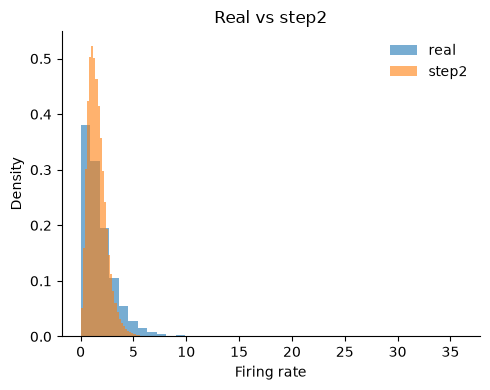

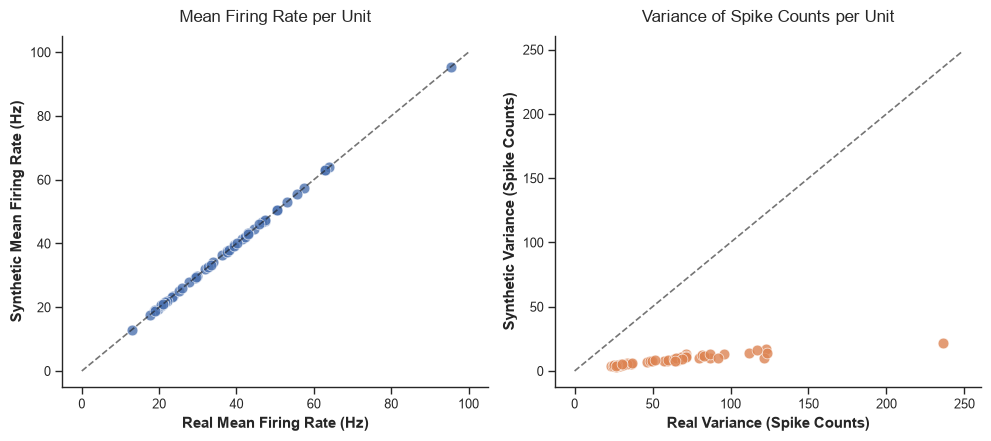

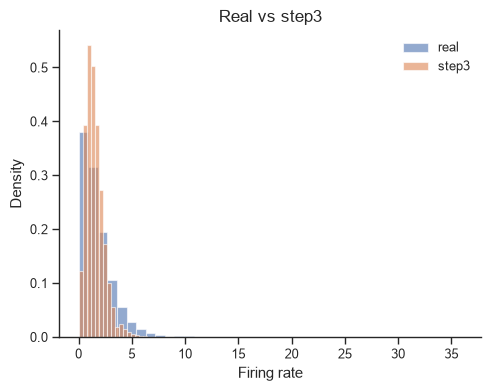

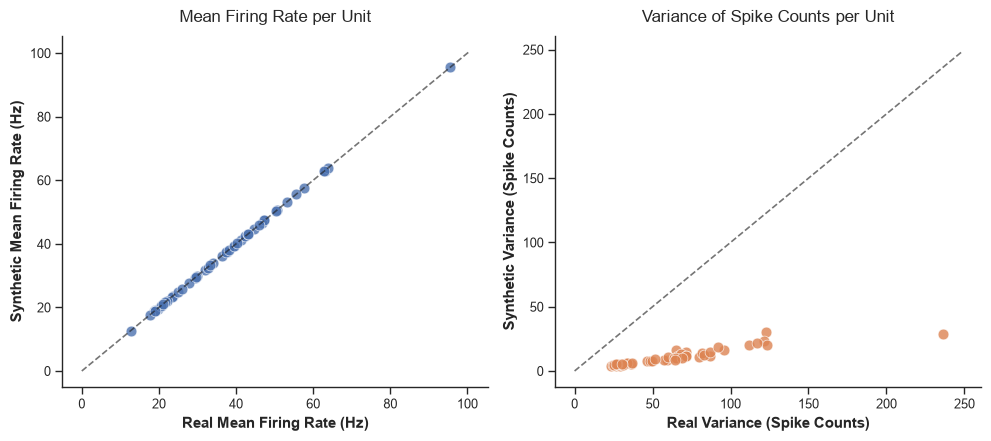

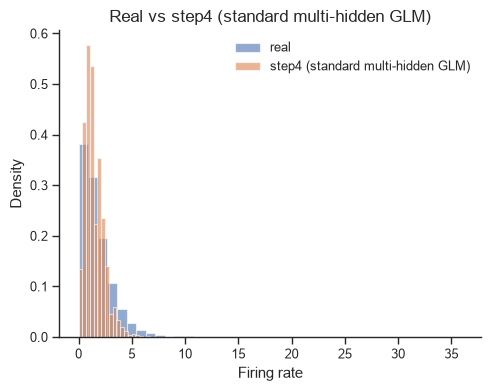

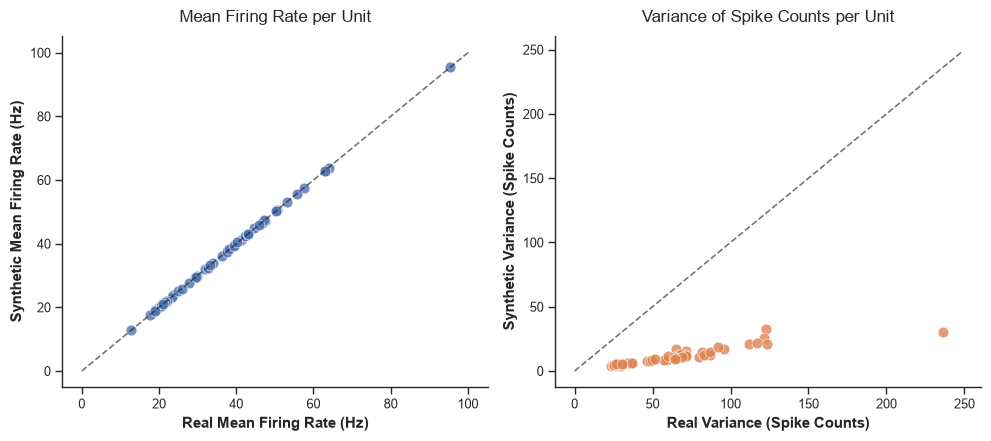

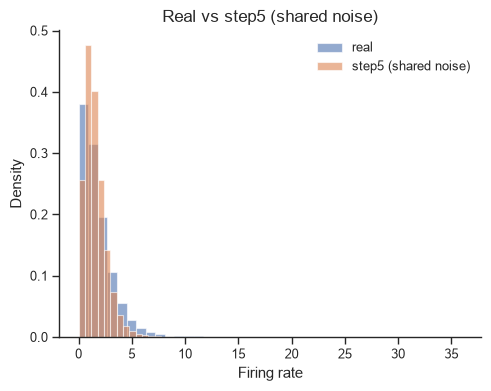

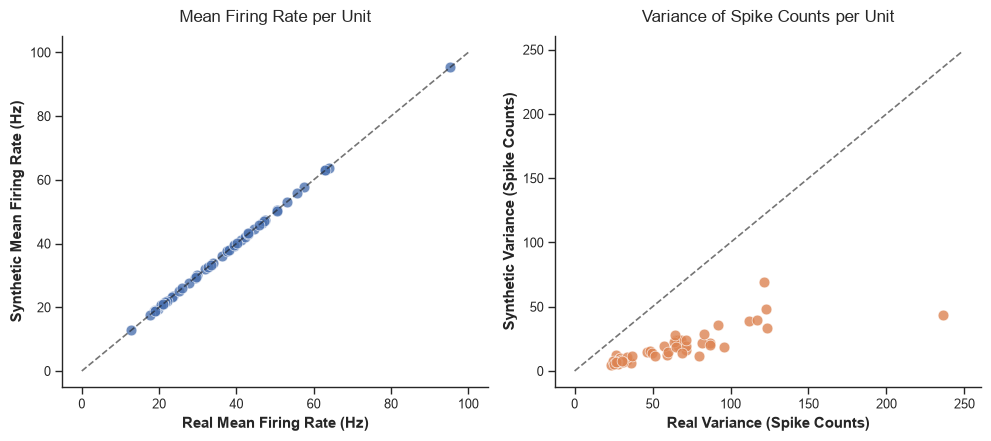

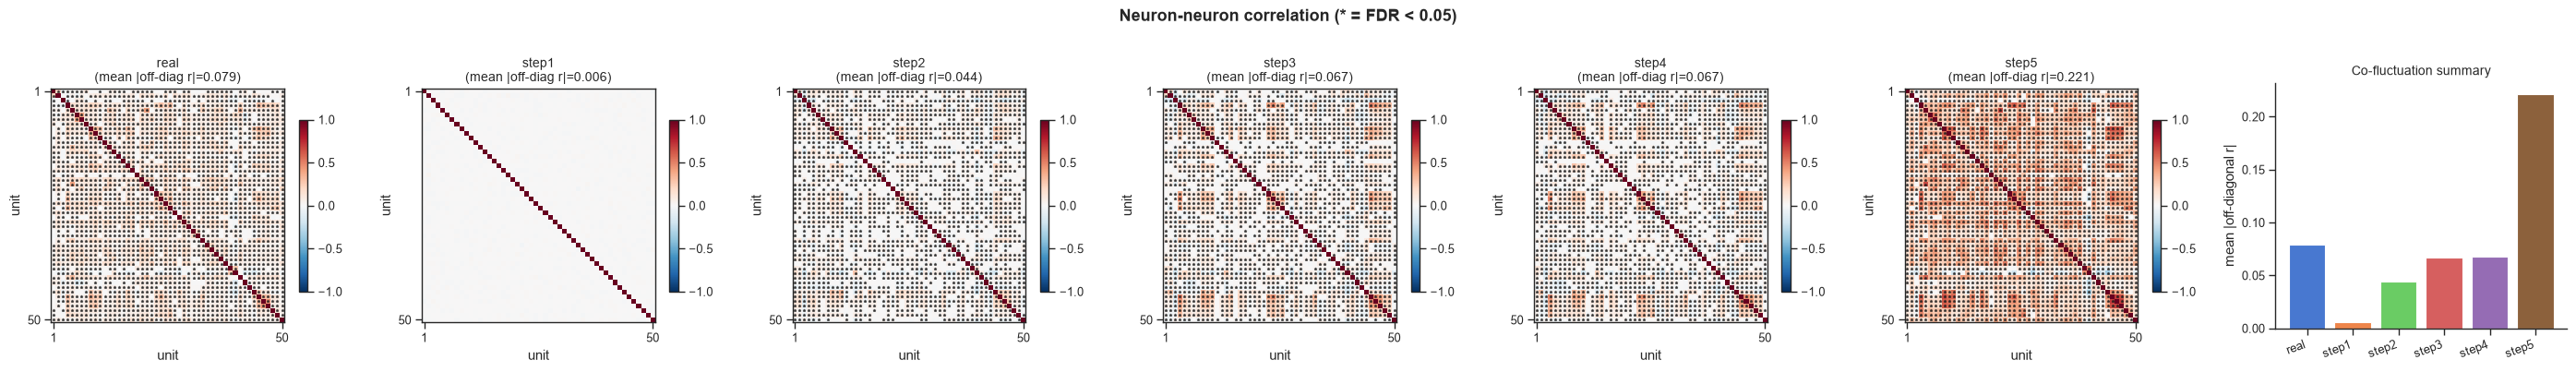

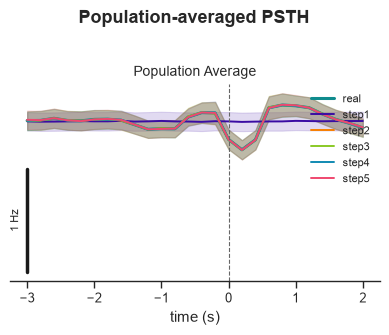

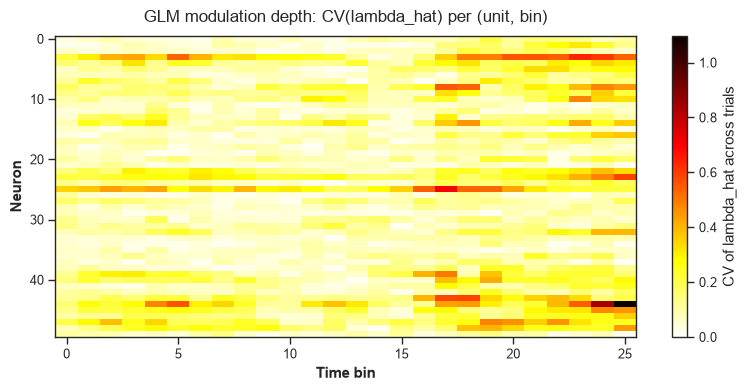

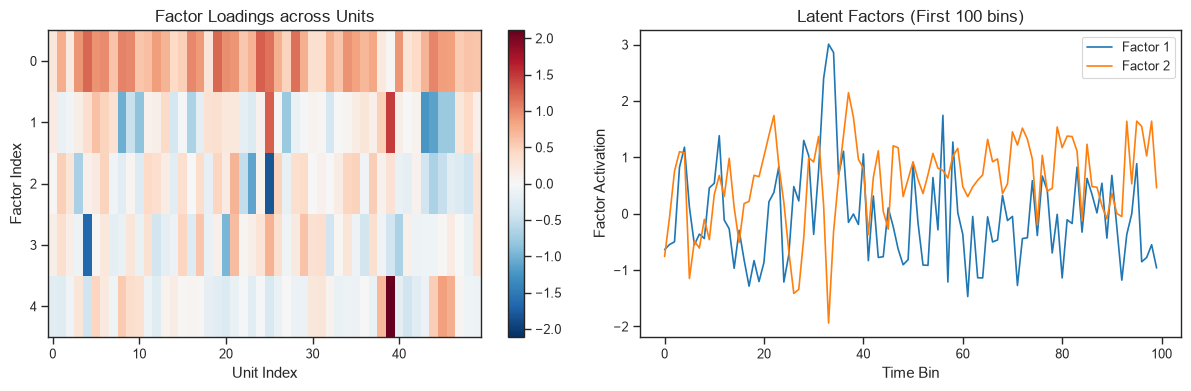

In [18]:
# @title Generate Synthetic Data & Plot
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# =========================================================================
# 0. EXPERIMENT TOGGLES & SWITCHES (EASILY SELECT YOUR SETTINGS HERE)
# =========================================================================
ENABLE_SELECTION_VARIANCE = False   # Toggle: Inject choice/last_choice variance into tslp & tunp
ENABLE_STEP4_RANDOM_LATENT = False  # Toggle: Activate random latent weight matrix in Step 4

# =========================================================================
# 1. SWITCHABLE ENRICHMENT FUNCTION FOR 'tslp' AND 'tunp'
# =========================================================================

def inject_selection_variance(prep, enable=True):

    if not enable:
        print("-> [INFO] Selection variance injection is DISABLED. Using original unmodified features.")
        return

    print("-> [INFO] Injecting choice & last_choice interaction variance into 'tslp' and 'tunp'...")
    t_names = list(prep['task_var_names']) if 'task_var_names' not in globals() else list(task_var_names)

    def get_feature_col(name):
        idx = t_names.index(name)
        if idx in prep['dense_indices']:
            return prep['X_dense_task'][:, prep['dense_indices'].index(idx)].copy()
        elif idx in prep['sparse_indices']:
            return prep['X_sparse_task'][:, prep['sparse_indices'].index(idx)].copy()
        elif 'task_vars' in globals():
            return task_vars[:, idx].copy()
        else:
            raise KeyError(f"Variable '{name}' not found in prep arrays or globals.")

    def set_feature_col(name, val_array):
        idx = t_names.index(name)
        if idx in prep['dense_indices']:
            prep['X_dense_task'][:, prep['dense_indices'].index(idx)] = val_array
        if idx in prep['sparse_indices']:
            prep['X_sparse_task'][:, prep['sparse_indices'].index(idx)] = val_array
        if 'task_vars' in globals():
            task_vars[:, idx] = val_array

    current_choice = get_feature_col('choice')
    last_choice    = get_feature_col('last_choice')

    selection_interaction = np.abs(current_choice - last_choice) + (current_choice * last_choice)

    tslp_val = get_feature_col('tslp') * (1.0 + 0.5 * current_choice)
    tunp_val = get_feature_col('tunp') * (1.0 + 2.5 * selection_interaction)

    scaler = MinMaxScaler(feature_range=(0, 1))
    tslp_val = scaler.fit_transform(tslp_val.reshape(-1, 1)).flatten()
    tunp_val = scaler.fit_transform(tunp_val.reshape(-1, 1)).flatten()

    set_feature_col('tslp', tslp_val)
    set_feature_col('tunp', tunp_val)
    if 'x_dense_vars' in globals(): globals()['x_dense_vars'] = prep['X_dense_task']
    if 'x_sparse_vars' in globals(): globals()['x_sparse_vars'] = prep['X_sparse_task']
    print("-> Successfully enriched 'tslp' and 'tunp'!")

# Execute Enrichment Switch
inject_selection_variance(prep, enable=ENABLE_SELECTION_VARIANCE)
x_dense_vars = prep['X_dense_task']
x_sparse_vars = prep['X_sparse_task']

# =========================================================================
# 2. Select variables for Step 3 & Step 4
# =========================================================================
step3_vars = ['tslp', 'rew', 'choice']
X_dense_3, X_sparse_3 = filter_task_vars(prep, step3_vars)
betas_3 = fit_glm_per_unit_bin(prep['counts'], X_dense_3, X_sparse_3)

step4_vars = ['tslp', 'rew','choice','rew_ratio']
X_dense_4, X_sparse_4 = filter_task_vars(prep, step4_vars)
betas_4 = fit_glm_per_unit_bin(prep['counts'], X_dense_4, X_sparse_4)

lambda_hat_3 = predict_glm_means(betas_3, X_dense_3, X_sparse_3)
lambda_hat_4 = predict_glm_means(betas_4, X_dense_4, X_sparse_4)

# =========================================================================
# 3. Step 4 Random Latent Generator (Forces Shared > Identity)
# =========================================================================
def generate_step4_random_latent_bias(prep, lambda_hat, n_latents=3, latent_strength=0.4, seed=42):
    rng = np.random.default_rng(seed)
    T, N, K = lambda_hat.shape
    
    # 1. Generate low-rank latent fluctuations
    Z = rng.normal(size=(T, n_latents))
    W = rng.normal(size=(n_latents, N))
    raw_proj = Z @ W
    
    # 2. Standardize across time so each unit's perturbation has mean=0 and std=1
    proj_norm = (raw_proj - np.mean(raw_proj, axis=0, keepdims=True)) / np.std(raw_proj, axis=0, keepdims=True)
    
    # 3. Scale by latent_strength (sigma) and subtract sigma^2 / 2 for exact log-normal mean compensation!
    sigma = latent_strength
    log_perturbation = (proj_norm[:, :, np.newaxis] * sigma) - (0.5 * sigma**2)
    
    # E[exp(log_perturbation)] is precisely 1.0 -> mean firing rates stay unaffected!
    modulated_lambda = lambda_hat * np.exp(log_perturbation)
    modulated_lambda = np.clip(modulated_lambda, 1e-8, 1000.0)
    
    synth = rng.poisson(lam=modulated_lambda).astype(float)
    return synth * prep.get('spike_scale', 1.0)


# Select Step 4 data generation method based on your toggle:
if ENABLE_STEP4_RANDOM_LATENT:
    print("-> [INFO] Using Random Latent Bias in Step 4 (favors Conditional/Shared over Identity).")
    # Using latent_strength=0.4 gives natural overdispersion without exploding the variance!
    step4_synthetic = generate_step4_random_latent_bias(prep, lambda_hat_4, n_latents=3, latent_strength=0.4)
    step4_label = "step4 (hidden + random latent bias)"

else:
    print("-> [INFO] Using Standard GLM Poisson sampling in Step 4 (No random latent bias injected).")
    step4_synthetic = generate_step3_glm_poisson(prep, betas_4, X_dense=X_dense_4, X_sparse=X_sparse_4)
    step4_label = "step4 (standard multi-hidden GLM)"

# =========================================================================
# 4. Generate synthetic datasets
# =========================================================================
synthetic_datasets = {
    'step1': generate_step1(prep, noise='poisson'),
    'step2': generate_step2_poisson_binwise(prep),
    'step3': generate_step3_glm_poisson(prep, betas_3, X_dense=X_dense_3, X_sparse=X_sparse_3),
    'step4': step4_synthetic,
    'step5': generate_step5_shared_noise(prep, lambda_hat_3, n_components=5)
}

conditions = {
    'real': Y,
    **synthetic_datasets
}

# =========================================================================
# 5. Plotting & Visual Verification
# =========================================================================
plot_firing_rate_histogram(Y, synthetic_datasets['step2'], test_label="step2")
plot_mean_variance_comparison(Y, synthetic_datasets['step2'], prep)

plot_firing_rate_histogram(Y, synthetic_datasets['step3'], test_label="step3")
plot_mean_variance_comparison(Y, synthetic_datasets['step3'], prep)

plot_firing_rate_histogram(Y, synthetic_datasets['step4'], test_label=step4_label)
plot_mean_variance_comparison(Y, synthetic_datasets['step4'], prep)

plot_firing_rate_histogram(Y, synthetic_datasets['step5'], test_label="step5 (shared noise)")
plot_mean_variance_comparison(Y, synthetic_datasets['step5'], prep)

plot_correlation_matrices(conditions, prep)
plot_population_psth(conditions, prep)
plot_glm_cv_heatmap(lambda_hat_3)

# Visualize Step 5 latents
plot_step5_shared_factors(prep, lambda_hat_3)


In [19]:
# 1. Gather the datasets
training_datasets = {
    'real': Y,
    **synthetic_datasets
}
#    

# 2. Run the full training loop with 10 splits
df_history, df_units, df_seed_summary = run_model_comparisons(
    training_datasets=training_datasets,
    x_position_vars=x_position_vars,
    x_dense_vars=x_dense_vars,
    x_sparse_vars=x_sparse_vars,
    Conf=Conf,
    device=device,
    n_splits=20,
    force_retrain=False,
    use_multi_seed=False,
    hidden_vars_step4=None if ENABLE_STEP4_RANDOM_LATENT else ['rew_ratio']
)

Loading existing progress from CSVs...

Training on real
  [SKIPPED] Model: Zero / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Baseline / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Conditional / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Conditional / Shared (All 20 folds already in CSV)

Training on step1
  [SKIPPED] Model: Zero / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Baseline / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Conditional / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Conditional / Shared (All 20 folds already in CSV)

Training on step2
  [SKIPPED] Model: Zero / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Baseline / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Conditional / Identity (All 20 folds already in CSV)
  [SKIPPED] Model: Conditional / Shared (All 20 folds already in CSV)

Training on step3
  [SKIPPED] Model: Zero / Identity (All 20 folds already i

### SHAP Real

In [20]:
real_targets = ['tunp', 'tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice', 'last_choice']

plot_shap_results(Conf, condition='real', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=real_targets)

plot_pearson_shap_results(Conf, condition='real', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names, target_vars=real_targets)



Plotting Spatiotemporal SHAP Analysis for real - Conditional / Identity
Loaded SHAP tensors (shape: (440, 10, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tunp', 'tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./results_full/SHAP_Plots/real/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [320 238 283  78 167] -> ./results_full/SHAP_Plots/real/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./results_full/SHAP_Plots/real/Conditional_Identity/

Pearson SHAP Correlation for real — Conditional / Identity
Filtering Pearson plots to: ['tunp', 'tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice']
  Computing Pearson r for 'tunp' (var_idx=4)...
    -> Significant cells (p<=0.05): 1188/1300 (91.4%)
  Computing Pearson r for 'tslp' (var_idx=5)...
    -> Significant cells (p<=0.

### SHAP Step3

In [21]:
# %matplotlib inline
# import os
# import numpy as np
# import shap
# import matplotlib.pyplot as plt

# # --- Select a specific unit, bin, and trial to visualize ---
# selected_unit = 20
# selected_bin = 5
# trial_indices = [0, 10, 20, 30, 40]

# condition = 'step3'
# model_label = 'Conditional / Identity'
# n_splits = 10

# all_shap_values_full = []
# all_base_values_full = []
# all_explain_data = []

# print(f"Loading saved SHAP values for condition: {condition} ({model_label})...")
# for fold_idx in range(n_splits):
#     shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
#     if os.path.exists(shap_save_path):
#         data = np.load(shap_save_path)
#         # Load FULL tensors so we can plot 2D Spatiotemporal Heatmaps across all units & bins!
#         all_shap_values_full.append(data['shap_values'])
#         all_base_values_full.append(data['base_values'])
#         all_explain_data.append({
#             'pos': data['explain_pos'],
#             'den': data['explain_den'],
#             'spa': data['explain_spa']
#         })
#     else:
#         print(f"  Fold {fold_idx} not found, skipping...")

# if not all_shap_values_full:
#     print("No SHAP values found to plot. Check if the files exist.")
# else:
#     scaling_factor = 10.0 # <--- Scales SHAP values to display properly in text labels
    
#     # Concatenate full tensors across all folds: shape [N_trials, N_vars, N_bins, N_units]
#     full_sv = np.concatenate(all_shap_values_full, axis=0) * scaling_factor
#     full_bv = np.concatenate(all_base_values_full, axis=0) * scaling_factor
    
#     # Extract slices for the specifically selected unit and bin for standard SHAP plots
#     sv = np.array(full_sv[:, :, selected_bin, selected_unit], copy=True)
#     bv = np.array(full_bv[:, selected_bin, selected_unit], copy=True)
    
#     ex_pos = np.concatenate([d['pos'][:, selected_bin, :] for d in all_explain_data], axis=0)
#     ex_den = np.concatenate([d['den'] for d in all_explain_data], axis=0)
#     ex_spa = np.concatenate([d['spa'] for d in all_explain_data], axis=0)

#     bin_data = np.concatenate([
#         ex_pos,
#         ex_den,
#         (ex_spa > 0).astype(int)
#     ], axis=1)
#     bin_data = np.array(bin_data.astype(float), copy=True)

#     feat_names = []
#     if 'variable_names' in globals() and variable_names is not None:
#         for v in variable_names:
#             if hasattr(v, 'item'):
#                 try: v = v.item()
#                 except: pass
#             if isinstance(v, (list, np.ndarray)) and len(v) > 0:
#                 v = v[0]
#             feat_names.append(str(v).strip("['\"] "))
            
#     n_vars = sv.shape[1]
#     if len(feat_names) < n_vars:
#         missing = n_vars - len(feat_names)
#         if missing == 2:
#             feat_names.extend(['Density (den)', 'Sparsity (spa)'])
#         else:
#             feat_names.extend([f"Feature {i}" for i in range(len(feat_names), n_vars)])
#     elif len(feat_names) > n_vars:
#         feat_names = feat_names[:n_vars]

#     explanation = shap.Explanation(values=sv, base_values=bv, data=bin_data, feature_names=feat_names)
    
#     # Base directory for standard SHAP explanation plots
#     base_file_path = FIGURES + f"shap/{condition}/unit-{selected_unit}-bin-{selected_bin}/"
#     print(f"\nSaving standard SHAP figures to: {base_file_path}")

#     # --- 1. Waterfall Plots (Single Trials) ---
#     for trial_idx in trial_indices:
#         if trial_idx < len(explanation):
#             t_idx = int(trial_idx)
#             save_shap_plot(
#                 lambda t=t_idx: shap.plots.waterfall(explanation[t], max_display=len(feat_names), show=False),
#                 title=f"SHAP Waterfall: Unit {selected_unit} - Bin {selected_bin} - Trial {t_idx}",
#                 file_name=f"trial-{t_idx}",
#                 file_path=os.path.join(base_file_path, "waterfall")
#             )
            
#     # --- 2. Scatter Plots (All Features) ---
#     # for var_idx, variable_name in enumerate(feat_names):
#     #     save_shap_plot(
#     #         lambda v=var_idx: shap.plots.scatter(explanation[:, v], show=False),
#     #         title=f"SHAP Scatter: Unit {selected_unit} - Bin {selected_bin} - {variable_name}",
#     #         file_name=f"variable-{variable_name.replace(' ', '_')}",
#     #         file_path=os.path.join(base_file_path, "scatter")
#     #     )

#     # --- 3. Beeswarm Plot ---
#     save_shap_plot(
#         lambda: shap.plots.beeswarm(explanation, max_display=len(feat_names), show=False),
#         title=f"SHAP Beeswarm: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="beeswarm",
#         file_path=base_file_path
#     )

#     # --- 4. Bar Plot ---
#     save_shap_plot(
#         lambda: shap.plots.bar(explanation, max_display=len(feat_names), show=False),
#         title=f"SHAP Bar: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="bar",
#         file_path=base_file_path
#     )
    
#     # --- 5. Heatmap Plot (Trials vs Features) ---
#     save_shap_plot(
#         lambda: shap.plots.heatmap(explanation, show=False),
#         title=f"SHAP Heatmap: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="heatmap",
#         file_path=base_file_path
#     )

#     # =========================================================================
#     # --- 6. NEW: Per-trial 2D Spatiotemporal SHAP Heatmaps (Bins x Units) ---
#     # =========================================================================
#     bt = bin_times if 'bin_times' in globals() else np.arange(full_sv.shape[2])
#     un = unit_names if 'unit_names' in globals() else np.arange(full_sv.shape[3])
    
#     print(f"Saving Spatiotemporal 2D SHAP maps for trials {trial_indices}...")
#     for t_idx in trial_indices:
#         if t_idx < full_sv.shape[0]:
#             trial_path = FIGURES + f"shap/{condition}/spatiotemporal_2d/trial-{t_idx}/"
#             for variable_idx in range(len(feat_names)):
#                 variable_name = feat_names[variable_idx]
#                 title = f"2D Spatiotemporal SHAP: Trial {t_idx} - {variable_name}"
#                 file_name = f"{variable_name.replace(' ', '_')}"
#                 plot_shap(
#                     shap_values=full_sv[t_idx, variable_idx], 
#                     title=title, 
#                     file_name=file_name, 
#                     file_path=trial_path, 
#                     bin_times=bt, 
#                     unit_names=un, 
#                     cmap="RdBu_r", 
#                     show=False
#                 )

#     # =========================================================================
#     # --- 7. NEW: Global Mean Absolute 2D Spatiotemporal SHAP Heatmaps ---
#     # =========================================================================
#     global_path = FIGURES + f"./shap/{condition}/spatiotemporal_2d/global_mean_abs/"
#     print(f"Saving Global Mean Absolute 2D SHAP maps to: {global_path}...")
#     for variable_idx in range(len(feat_names)):
#         variable_name = feat_names[variable_idx]
#         title = f"Global Mean Abs 2D SHAP: {variable_name}"
#         file_name = f"{variable_name.replace(' ', '_')}"
#         plot_shap(
#             shap_values=np.abs(full_sv[:, variable_idx]).mean(axis=0), 
#             title=title, 
#             file_name=file_name, 
#             file_path=global_path, 
#             bin_times=bt, 
#             unit_names=un, 
#             cmap="magma", 
#             show=False
#         )
#     print("All SHAP visual analyses saved successfully!")


In [22]:
step3_targets = ['tslp', 'rew', 'choice']

plot_shap_results(Conf, condition='step3', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step3_targets)

plot_pearson_shap_results(Conf, condition='step3', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          betas_step3=betas_3, target_vars=step3_targets)



Plotting Spatiotemporal SHAP Analysis for step3 - Conditional / Identity
Loaded SHAP tensors (shape: (440, 10, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./results_full/SHAP_Plots/step3/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [343 137 405  73 296] -> ./results_full/SHAP_Plots/step3/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./results_full/SHAP_Plots/step3/Conditional_Identity/

Pearson SHAP Correlation for step3 — Conditional / Identity
Filtering Pearson plots to: ['tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice']
  Computing Pearson r for 'tslp' (var_idx=5)...
    -> Significant cells (p<=0.05): 1272/1300 (97.8%)
    -> GLM sign agreement (sig. cells only): 57.7%
  Computing Pearson r for 'rew_rate' (v

### SHAP Step4

In [23]:
# %matplotlib inline
# import os
# import numpy as np
# import shap
# import matplotlib.pyplot as plt

# # --- Select a specific unit, bin, and trial to visualize ---
# selected_unit = 20
# selected_bin = 5
# trial_indices = [0, 10, 20, 30, 40]

# condition = 'step4'
# model_label = 'Conditional / Identity'
# n_splits = 10

# all_shap_values_full = []
# all_base_values_full = []
# all_explain_data = []

# print(f"Loading saved SHAP values for condition: {condition} ({model_label})...")
# for fold_idx in range(n_splits):
#     shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
#     if os.path.exists(shap_save_path):
#         data = np.load(shap_save_path)
#         # Load FULL tensors so we can plot 2D Spatiotemporal Heatmaps across all units & bins!
#         all_shap_values_full.append(data['shap_values'])
#         all_base_values_full.append(data['base_values'])
#         all_explain_data.append({
#             'pos': data['explain_pos'],
#             'den': data['explain_den'],
#             'spa': data['explain_spa']
#         })
#     else:
#         print(f"  Fold {fold_idx} not found, skipping...")

# if not all_shap_values_full:
#     print("No SHAP values found to plot. Check if the files exist.")
# else:
#     scaling_factor = 10.0 # <--- Scales SHAP values to display properly in text labels
    
#     # Concatenate full tensors across all folds: shape [N_trials, N_vars, N_bins, N_units]
#     full_sv = np.concatenate(all_shap_values_full, axis=0) * scaling_factor
#     full_bv = np.concatenate(all_base_values_full, axis=0) * scaling_factor
    
#     # Extract slices for the specifically selected unit and bin for standard SHAP plots
#     sv = np.array(full_sv[:, :, selected_bin, selected_unit], copy=True)
#     bv = np.array(full_bv[:, selected_bin, selected_unit], copy=True)
    
#     ex_pos = np.concatenate([d['pos'][:, selected_bin, :] for d in all_explain_data], axis=0)
#     ex_den = np.concatenate([d['den'] for d in all_explain_data], axis=0)
#     ex_spa = np.concatenate([d['spa'] for d in all_explain_data], axis=0)

#     bin_data = np.concatenate([
#         ex_pos,
#         ex_den,
#         (ex_spa > 0).astype(int)
#     ], axis=1)
#     bin_data = np.array(bin_data.astype(float), copy=True)

#     feat_names = []
#     if 'variable_names' in globals() and variable_names is not None:
#         for v in variable_names:
#             if hasattr(v, 'item'):
#                 try: v = v.item()
#                 except: pass
#             if isinstance(v, (list, np.ndarray)) and len(v) > 0:
#                 v = v[0]
#             feat_names.append(str(v).strip("['\"] "))
            
#     n_vars = sv.shape[1]
#     if len(feat_names) < n_vars:
#         missing = n_vars - len(feat_names)
#         if missing == 2:
#             feat_names.extend(['Density (den)', 'Sparsity (spa)'])
#         else:
#             feat_names.extend([f"Feature {i}" for i in range(len(feat_names), n_vars)])
#     elif len(feat_names) > n_vars:
#         feat_names = feat_names[:n_vars]

#     explanation = shap.Explanation(values=sv, base_values=bv, data=bin_data, feature_names=feat_names)
    
#     # Base directory for standard SHAP explanation plots
#     base_file_path = FIGURES + f"shap/{condition}/unit-{selected_unit}-bin-{selected_bin}/"
#     print(f"\nSaving standard SHAP figures to: {base_file_path}")

#     # --- 1. Waterfall Plots (Single Trials) ---
#     for trial_idx in trial_indices:
#         if trial_idx < len(explanation):
#             t_idx = int(trial_idx)
#             save_shap_plot(
#                 lambda t=t_idx: shap.plots.waterfall(explanation[t], max_display=len(feat_names), show=False),
#                 title=f"SHAP Waterfall: Unit {selected_unit} - Bin {selected_bin} - Trial {t_idx}",
#                 file_name=f"trial-{t_idx}",
#                 file_path=os.path.join(base_file_path, "waterfall")
#             )
            
#     # --- 2. Scatter Plots (All Features) ---
#     # for var_idx, variable_name in enumerate(feat_names):
#     #     save_shap_plot(
#     #         lambda v=var_idx: shap.plots.scatter(explanation[:, v], show=False),
#     #         title=f"SHAP Scatter: Unit {selected_unit} - Bin {selected_bin} - {variable_name}",
#     #         file_name=f"variable-{variable_name.replace(' ', '_')}",
#     #         file_path=os.path.join(base_file_path, "scatter")
#     #     )

#     # --- 3. Beeswarm Plot ---
#     save_shap_plot(
#         lambda: shap.plots.beeswarm(explanation, max_display=len(feat_names), show=False),
#         title=f"SHAP Beeswarm: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="beeswarm",
#         file_path=base_file_path
#     )

#     # --- 4. Bar Plot ---
#     save_shap_plot(
#         lambda: shap.plots.bar(explanation, max_display=len(feat_names), show=False),
#         title=f"SHAP Bar: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="bar",
#         file_path=base_file_path
#     )
    
#     # --- 5. Heatmap Plot (Trials vs Features) ---
#     save_shap_plot(
#         lambda: shap.plots.heatmap(explanation, show=False),
#         title=f"SHAP Heatmap: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="heatmap",
#         file_path=base_file_path
#     )

#     # =========================================================================
#     # --- 6. NEW: Per-trial 2D Spatiotemporal SHAP Heatmaps (Bins x Units) ---
#     # =========================================================================
#     bt = bin_times if 'bin_times' in globals() else np.arange(full_sv.shape[2])
#     un = unit_names if 'unit_names' in globals() else np.arange(full_sv.shape[3])
    
#     print(f"Saving Spatiotemporal 2D SHAP maps for trials {trial_indices}...")
#     for t_idx in trial_indices:
#         if t_idx < full_sv.shape[0]:
#             trial_path = FIGURES + f"./shap/{condition}/spatiotemporal_2d/trial-{t_idx}/"
#             for variable_idx in range(len(feat_names)):
#                 variable_name = feat_names[variable_idx]
#                 title = f"2D Spatiotemporal SHAP: Trial {t_idx} - {variable_name}"
#                 file_name = f"{variable_name.replace(' ', '_')}"
#                 plot_shap(
#                     shap_values=full_sv[t_idx, variable_idx], 
#                     title=title, 
#                     file_name=file_name, 
#                     file_path=trial_path, 
#                     bin_times=bt, 
#                     unit_names=un, 
#                     cmap="RdBu_r", 
#                     show=False
#                 )

#     # =========================================================================
#     # --- 7. NEW: Global Mean Absolute 2D Spatiotemporal SHAP Heatmaps ---
#     # =========================================================================
#     global_path = FIGURES + f"shap/{condition}/spatiotemporal_2d/global_mean_abs/"
#     print(f"Saving Global Mean Absolute 2D SHAP maps to: {global_path}...")
#     for variable_idx in range(len(feat_names)):
#         variable_name = feat_names[variable_idx]
#         title = f"Global Mean Abs 2D SHAP: {variable_name}"
#         file_name = f"{variable_name.replace(' ', '_')}"
#         plot_shap(
#             shap_values=np.abs(full_sv[:, variable_idx]).mean(axis=0), 
#             title=title, 
#             file_name=file_name, 
#             file_path=global_path, 
#             bin_times=bt, 
#             unit_names=un, 
#             cmap="magma", 
#             show=False
#         )
#     print("All SHAP visual analyses saved successfully!")


In [24]:
# step4_targets = ['rew_rate', 'rew', 'choice', 'tslp', 'tunp', 'last_choice', 'rew_ratio', 'last_choice']

# plot_shap_results(Conf, condition='step4', model_label='Conditional / Identity',
#                   n_splits=20, variable_names=variable_names,
#                   target_vars=step4_targets)

# plot_pearson_shap_results(Conf, condition='step4', model_label='Conditional / Identity',
#                           n_splits=20, variable_names=variable_names,
#                           betas_step4=betas_4, target_vars=step4_targets)

### SHAP Step5

In [25]:
# %matplotlib inline
# import os
# import numpy as np
# import shap
# import matplotlib.pyplot as plt

# # --- Select a specific unit, bin, and trial to visualize ---
# selected_unit = 20
# selected_bin = 5
# trial_indices = [0, 10, 20, 30, 40]

# condition = 'step5'
# model_label = 'Conditional / Identity'
# n_splits = 10

# all_shap_values_full = []
# all_base_values_full = []
# all_explain_data = []

# print(f"Loading saved SHAP values for condition: {condition} ({model_label})...")
# for fold_idx in range(n_splits):
#     shap_save_path = f"{RESULTS}shap_values_{condition}_{model_label.replace(' / ', '_')}_fold{fold_idx}.npz"
#     if os.path.exists(shap_save_path):
#         data = np.load(shap_save_path)
#         # Load FULL tensors so we can plot 2D Spatiotemporal Heatmaps across all units & bins!
#         all_shap_values_full.append(data['shap_values'])
#         all_base_values_full.append(data['base_values'])
#         all_explain_data.append({
#             'pos': data['explain_pos'],
#             'den': data['explain_den'],
#             'spa': data['explain_spa']
#         })
#     else:
#         print(f"  Fold {fold_idx} not found, skipping...")

# if not all_shap_values_full:
#     print("No SHAP values found to plot. Check if the files exist.")
# else:
#     scaling_factor = 10.0 # <--- Scales SHAP values to display properly in text labels
    
#     # Concatenate full tensors across all folds: shape [N_trials, N_vars, N_bins, N_units]
#     full_sv = np.concatenate(all_shap_values_full, axis=0) * scaling_factor
#     full_bv = np.concatenate(all_base_values_full, axis=0) * scaling_factor
    
#     # Extract slices for the specifically selected unit and bin for standard SHAP plots
#     sv = np.array(full_sv[:, :, selected_bin, selected_unit], copy=True)
#     bv = np.array(full_bv[:, selected_bin, selected_unit], copy=True)
    
#     ex_pos = np.concatenate([d['pos'][:, selected_bin, :] for d in all_explain_data], axis=0)
#     ex_den = np.concatenate([d['den'] for d in all_explain_data], axis=0)
#     ex_spa = np.concatenate([d['spa'] for d in all_explain_data], axis=0)

#     bin_data = np.concatenate([
#         ex_pos,
#         ex_den,
#         (ex_spa > 0).astype(int)
#     ], axis=1)
#     bin_data = np.array(bin_data.astype(float), copy=True)

#     feat_names = []
#     if 'variable_names' in globals() and variable_names is not None:
#         for v in variable_names:
#             if hasattr(v, 'item'):
#                 try: v = v.item()
#                 except: pass
#             if isinstance(v, (list, np.ndarray)) and len(v) > 0:
#                 v = v[0]
#             feat_names.append(str(v).strip("['\"] "))
            
#     n_vars = sv.shape[1]
#     if len(feat_names) < n_vars:
#         missing = n_vars - len(feat_names)
#         if missing == 2:
#             feat_names.extend(['Density (den)', 'Sparsity (spa)'])
#         else:
#             feat_names.extend([f"Feature {i}" for i in range(len(feat_names), n_vars)])
#     elif len(feat_names) > n_vars:
#         feat_names = feat_names[:n_vars]

#     explanation = shap.Explanation(values=sv, base_values=bv, data=bin_data, feature_names=feat_names)
    
#     # Base directory for standard SHAP explanation plots
#     base_file_path = FIGURES + f"shap/{condition}/unit-{selected_unit}-bin-{selected_bin}/"
#     print(f"\nSaving standard SHAP figures to: {base_file_path}")

#     # --- 1. Waterfall Plots (Single Trials) ---
#     for trial_idx in trial_indices:
#         if trial_idx < len(explanation):
#             t_idx = int(trial_idx)
#             save_shap_plot(
#                 lambda t=t_idx: shap.plots.waterfall(explanation[t], max_display=len(feat_names), show=False),
#                 title=f"SHAP Waterfall: Unit {selected_unit} - Bin {selected_bin} - Trial {t_idx}",
#                 file_name=f"trial-{t_idx}",
#                 file_path=os.path.join(base_file_path, "waterfall")
#             )
            
#     # --- 2. Scatter Plots (All Features) ---
#     # for var_idx, variable_name in enumerate(feat_names):
#     #     save_shap_plot(
#     #         lambda v=var_idx: shap.plots.scatter(explanation[:, v], show=False),
#     #         title=f"SHAP Scatter: Unit {selected_unit} - Bin {selected_bin} - {variable_name}",
#     #         file_name=f"variable-{variable_name.replace(' ', '_')}",
#     #         file_path=os.path.join(base_file_path, "scatter")
#     #     )

#     # --- 3. Beeswarm Plot ---
#     save_shap_plot(
#         lambda: shap.plots.beeswarm(explanation, max_display=len(feat_names), show=False),
#         title=f"SHAP Beeswarm: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="beeswarm",
#         file_path=base_file_path
#     )

#     # --- 4. Bar Plot ---
#     save_shap_plot(
#         lambda: shap.plots.bar(explanation, max_display=len(feat_names), show=False),
#         title=f"SHAP Bar: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="bar",
#         file_path=base_file_path
#     )
    
#     # --- 5. Heatmap Plot (Trials vs Features) ---
#     save_shap_plot(
#         lambda: shap.plots.heatmap(explanation, show=False),
#         title=f"SHAP Heatmap: Unit {selected_unit} - Bin {selected_bin}",
#         file_name="heatmap",
#         file_path=base_file_path
#     )

#     # =========================================================================
#     # --- 6. NEW: Per-trial 2D Spatiotemporal SHAP Heatmaps (Bins x Units) ---
#     # =========================================================================
#     bt = bin_times if 'bin_times' in globals() else np.arange(full_sv.shape[2])
#     un = unit_names if 'unit_names' in globals() else np.arange(full_sv.shape[3])
    
#     print(f"Saving Spatiotemporal 2D SHAP maps for trials {trial_indices}...")
#     for t_idx in trial_indices:
#         if t_idx < full_sv.shape[0]:
#             trial_path = FIGURES + f"shap/{condition}/spatiotemporal_2d/trial-{t_idx}/"
#             for variable_idx in range(len(feat_names)):
#                 variable_name = feat_names[variable_idx]
#                 title = f"2D Spatiotemporal SHAP: Trial {t_idx} - {variable_name}"
#                 file_name = f"{variable_name.replace(' ', '_')}"
#                 plot_shap(
#                     shap_values=full_sv[t_idx, variable_idx], 
#                     title=title, 
#                     file_name=file_name, 
#                     file_path=trial_path, 
#                     bin_times=bt, 
#                     unit_names=un, 
#                     cmap="RdBu_r", 
#                     show=False
#                 )

#     # =========================================================================
#     # --- 7. NEW: Global Mean Absolute 2D Spatiotemporal SHAP Heatmaps ---
#     # =========================================================================
#     global_path = FIGURES + f"./shap/{condition}/spatiotemporal_2d/global_mean_abs/"
#     print(f"Saving Global Mean Absolute 2D SHAP maps to: {global_path}...")
#     for variable_idx in range(len(feat_names)):
#         variable_name = feat_names[variable_idx]
#         title = f"Global Mean Abs 2D SHAP: {variable_name}"
#         file_name = f"{variable_name.replace(' ', '_')}"
#         plot_shap(
#             shap_values=np.abs(full_sv[:, variable_idx]).mean(axis=0), 
#             title=title, 
#             file_name=file_name, 
#             file_path=global_path, 
#             bin_times=bt, 
#             unit_names=un, 
#             cmap="magma", 
#             show=False
#         )
#     print("All SHAP visual analyses saved successfully!")


In [26]:
# For step5 you need the FA object — re-run it once to get fa.components_:
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import MinMaxScaler
Y_true = prep['counts']
T, N, K = Y_true.shape
Y_flat  = Y_true.transpose(0,2,1).reshape(T*K, N)
lam_flat = lambda_hat_4.transpose(0,2,1).reshape(T*K, N)
residuals = (Y_flat - lam_flat) / np.sqrt(lam_flat + 1e-8)
fa = FactorAnalysis(n_components=5, random_state=Conf.seed)
fa.fit(residuals)

step5_targets = ['rew','tslp', 'choice']

plot_shap_results(Conf, condition='step5', model_label='Conditional / Identity',
                  n_splits=10, variable_names=variable_names,
                  target_vars=step5_targets)

plot_pearson_shap_results(Conf, condition='step5', model_label='Conditional / Identity',
                          n_splits=10, variable_names=variable_names,
                          fa_components=fa.components_, target_vars=step5_targets)


Plotting Spatiotemporal SHAP Analysis for step5 - Conditional / Identity
Loaded SHAP tensors (shape: (440, 10, 26, 50), scaling: 1.0x)
Filtering 2D plots to: ['tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice']
Generating population-wide overall feature importance (Beeswarm, Bar, Waterfall)...
Generating Global 2D Spatiotemporal maps -> ./results_full/SHAP_Plots/step5/Conditional_Identity/spatiotemporal_global_mean
Generating Per-trial maps & Waterfalls for trials [ 57 204  61  92 332] -> ./results_full/SHAP_Plots/step5/Conditional_Identity/spatiotemporal_trials
SHAP analysis complete! All figures saved in: ./results_full/SHAP_Plots/step5/Conditional_Identity/

Pearson SHAP Correlation for step5 — Conditional / Identity
Filtering Pearson plots to: ['tslp', 'rew_rate', 'rew_ratio', 'rew', 'choice']
  Computing Pearson r for 'tslp' (var_idx=5)...
    -> Significant cells (p<=0.05): 1232/1300 (94.8%)
    -> FA-magnitude vs |Pearson r| correlation: r=-0.061, p=0.0272
  Computing Pearson r f

In [27]:
# if 'step3' in training_datasets:
#     plot_shap_results(Conf, condition='step3', model_label='Conditional / Identity', n_splits=20, variable_names=variable_names)
# if 'step4' in training_datasets:
#     plot_shap_results(Conf, condition='step4', model_label='Conditional / Identity', n_splits=20, variable_names=variable_names)
# if 'step5' in training_datasets:
#     plot_shap_results(Conf, condition='step5', model_label='Conditional / Identity', n_splits=20, variable_names=variable_names)


In [28]:
# # @title Post-Training Stability Plots (Multi-Seed)

# # Select specific folds to plot the seed stability fan plots
# selected_folds = [0]
# max_epochs_training = 500  # Assuming Conf.training.max_epoch = 500

# # Load from disk to ensure we plot EVERYTHING, even skipped models
# hist_csv = RESULTS + "training_history_full.csv"

# if os.path.exists(hist_csv):
#     df_history = pd.read_csv(hist_csv)
    
#     conditions = df_history['condition'].unique()
#     models = df_history['model'].unique()
    
#     for condition in conditions:
#         print(f"\n{'='*40}\nStability for {condition}\n{'='*40}")
#         for model in models:
#             if model == 'Zero / Identity':
#                 continue
                
#             for fold in selected_folds:
#                 sub_hist = df_history[(df_history['condition'] == condition) & 
#                                       (df_history['model'] == model) & 
#                                       (df_history['fold'] == fold)]
                
#                 if sub_hist.empty:
#                     continue
                
#                 # Reconstruct all_histories and sub_sum dynamically!
#                 all_histories = []
#                 seed_rows = []
                
#                 for seed in sorted(sub_hist['seed'].unique()):
#                     seed_df = sub_hist[sub_hist['seed'] == seed].sort_values('epoch')
#                     all_histories.append(seed_df.to_dict('list'))
                    
#                     val_loss_arr = seed_df['valid_loss_epoch'].dropna().values
#                     tr_loss_arr = seed_df['train_loss_epoch'].dropna().values
#                     val_mse_arr = seed_df['valid_mse_epoch'].dropna().values if 'valid_mse_epoch' in seed_df else []
                    
#                     final_val = float(val_loss_arr[-1]) if len(val_loss_arr) > 0 else np.nan
#                     final_tr = float(tr_loss_arr[-1]) if len(tr_loss_arr) > 0 else np.nan
#                     final_mse = float(val_mse_arr[-1]) if len(val_mse_arr) > 0 else np.nan
                    
#                     conv_epoch = int(seed_df['epoch'].max()) if not seed_df.empty else 0
#                     jitter = float(pd.Series(val_loss_arr).rolling(5, min_periods=2).std().mean())
#                     stopped = conv_epoch < (max_epochs_training - 1)
                    
#                     seed_rows.append({
#                         "seed": seed,
#                         "final_valid_loss": final_val,
#                         "final_train_loss": final_tr,
#                         "final_valid_mse": final_mse,
#                         "convergence_epoch": conv_epoch,
#                         "mean_jitter": jitter,
#                         "stopped_early": stopped,
#                         "condition": condition,
#                         "fold": fold,
#                         "model": model
#                     })
                    
#                 sub_sum = pd.DataFrame(seed_rows)
                
#                 plot_seed_stability(
#                     all_histories,
#                     sub_sum,
#                     title=f"Stability: {model} (Fold {fold}) [{condition}]",
#                     smooth_window=7,
#                     save_path=f"{FIGURES}stability_{condition}_{model.replace(' / ', '_')}_fold{fold}.png"
#                 )

In [29]:
if not df_history.empty and not df_units.empty:
    for condition in training_datasets.keys():
        
        # 1. Existing overall loss curves plot
        # plot_loss_curves_per_epoch(
        #     df_history, 
        #     condition=condition, 
        #     save_path=FIGURES + f"loss_curves_{condition}.png"
        # )
        
        # # 2. Existing scatter plot
        # plot_model_comparison_scatter_by_unit(
        #     df_units, 
        #     ref_model='Conditional / Identity',
        #     metric='mse', 
        #     condition=condition, 
        #     save_path=FIGURES + f"scatter_unit_{condition}.png"
        # )
        
        # 3. Detailed Training History Plots (Conditional / Identity, Fold 0 ONLY)
        model_name = "Conditional / Identity"
        
        # Filter to just ONE specific run (Condition + Model + Fold 0)
        single_fold_hist = df_history[
            (df_history['condition'] == condition) & 
            (df_history['model'] == model_name) & 
            (df_history['fold'] == 0) &
            (df_history['seed'] == 0)
        ]
        
        # Make sure we actually have data before trying to plot
        if not single_fold_hist.empty:
            safe_model_name = model_name.replace(" / ", "_").replace(" ", "")
            
            # Call your new function!
            plot_training_history(
                history=single_fold_hist,
                title=f"History: {model_name} (Fold 0, {condition})",
                save_path=FIGURES + f"training_history_{condition}_{safe_model_name}_fold0.png",
                smooth_window=5
            )

Saved → ./figures_full/training_history_real_Conditional_Identity_fold0.png
Saved → ./figures_full/training_history_step1_Conditional_Identity_fold0.png
Saved → ./figures_full/training_history_step2_Conditional_Identity_fold0.png
Saved → ./figures_full/training_history_step3_Conditional_Identity_fold0.png
Saved → ./figures_full/training_history_step4_Conditional_Identity_fold0.png
Saved → ./figures_full/training_history_step5_Conditional_Identity_fold0.png


In [30]:
if 'df_history' in locals() and not df_history.empty:
    # Optional but recommended: Sort by epoch to ensure .last() gets the final training step
    # (Change 'epoch' if your step column is named differently, like 'step')
    if 'epoch' in df_history.columns:
        df_history = df_history.sort_values(by=['condition', 'model', 'fold', 'epoch'])

    for condition in df_history['condition'].unique():
        cond_hist = df_history[df_history['condition'] == condition]
        
        # Get the LAST validation NLL for each fold and model (using .last() instead of .min())
        last_nll = cond_hist.groupby(['model', 'fold'], as_index=False)['valid_loss_epoch'].last()
        
        # Rename the columns to match what plot_step_boxplot expects
        last_nll = last_nll.rename(columns={'model': 'model_label', 'valid_loss_epoch': 'nll'})
        
        plot_step_boxplot(
            df_step=last_nll, 
            step_name=condition, 
            metric='nll', 
            # Updated the filename to reflect it's the last epoch
            save_path=FIGURES + f"boxplot_{condition}_nll_folds_last.png" 
        )

In [31]:
# # Assuming you have your history dataframe loaded (e.g., as df_history or existing_history_df)
# # df_history = pd.read_csv(RESULTS + "training_history_full.csv")

# if 'df_history' in locals() and not df_history.empty:
#     for condition in df_history['condition'].unique():
#         cond_hist = df_history[df_history['condition'] == condition]
        
#         # Get the best (minimum) validation NLL for each fold and model
#         best_nll = cond_hist.groupby(['model', 'fold'], as_index=False)['valid_loss_epoch'].min()
        
#         # Rename the columns to match what plot_step_boxplot expects
#         best_nll = best_nll.rename(columns={'model': 'model_label', 'valid_loss_epoch': 'nll'})
        
#         plot_step_boxplot(
#             df_step=best_nll, 
#             step_name=condition, 
#             metric='nll', 
#             save_path=FIGURES + f"boxplot_{condition}_nll_folds.png"
#         )


In [32]:
# Loop through your results and generate the fold-level boxplots
if 'df_units' in locals() and not df_units.empty:
    for condition in df_units['condition'].unique():
        
        cond_df = df_units[df_units['condition'] == condition]
        
        available_metrics = [m for m in ['pearson', 'mse', 'r2'] if m in cond_df.columns]
        cond_df_folds = cond_df.groupby(['model_label', 'fold'], as_index=False)[available_metrics].mean()
        
        if 'pearson' in available_metrics:
            plot_step_boxplot(
                df_step=cond_df_folds, 
                step_name=condition, 
                metric='pearson', 
                save_path=FIGURES + f"boxplot_{condition}_pearson_folds.png"
            )
            
        if 'mse' in available_metrics:
            plot_step_boxplot(
                df_step=cond_df_folds, 
                step_name=condition, 
                metric='mse', 
                save_path=FIGURES + f"boxplot_{condition}_mse_folds.png"
            )
            
        if 'r2' in available_metrics:
            plot_step_boxplot(
                df_step=cond_df_folds, 
                step_name=condition, 
                metric='r2', 
                save_path=FIGURES + f"boxplot_{condition}_r2_folds.png"
            )


In [33]:
# # Loop through your results and generate BOTH boxplots and separated scatters
# if 'df_units' in locals() and not df_units.empty:
#     for condition in df_units['condition'].unique():
        
#         cond_df = df_units[df_units['condition'] == condition]
        
#         # Aggregate by fold
#         available_metrics = [m for m in ['pearson', 'mse', 'r2'] if m in cond_df.columns]
#         cond_df_folds = cond_df.groupby(['model_label', 'fold'], as_index=False)[available_metrics].mean()
        
#         for metric in available_metrics:            
#             # Plot the Separated Swarm Scatter
#             plot_step_scatter_separated(
#                 df_step=cond_df_folds, 
#                 step_name=condition, 
#                 metric=metric, 
#                 save_path=FIGURES + f"scatter_separated_{condition}_{metric}_folds.png"
#             )


In [34]:
if 'df_units' in locals() and not df_units.empty:
    
    # OPTION A: Loop through all conditions, and compare the MODELS against each other
    print("--- Comparing Models for each Condition ---")
    for condition in df_units['condition'].unique():
        plot_statistics_heatmap(
            df=df_units, 
            filter_col='condition', 
            filter_val=condition, 
            compare_col='model_label', 
            metric='pearson',
            magnitude_threshold=0.005,
            save_path=FIGURES + f"stats_models_in_{condition}_pearson.png"
        )

        plot_statistics_heatmap(
            df=df_units, 
            filter_col='condition', 
            filter_val=condition, 
            compare_col='model_label', 
            metric='r2',
            magnitude_threshold=0.005,
            save_path=FIGURES + f"stats_models_in_{condition}_r2.png"
        )

        plot_statistics_heatmap(
            df=df_units, 
            filter_col='condition', 
            filter_val=condition, 
            compare_col='model_label', 
            metric='mse',
            magnitude_threshold=0.005,
            save_path=FIGURES + f"stats_models_in_{condition}_mse.png"
        )


--- Comparing Models for each Condition ---
Saved -> ./figures_full/stats_models_in_real_pearson.png
Saved -> ./figures_full/stats_models_in_real_r2.png
Saved -> ./figures_full/stats_models_in_real_mse.png
Saved -> ./figures_full/stats_models_in_step1_pearson.png
Saved -> ./figures_full/stats_models_in_step1_r2.png
Saved -> ./figures_full/stats_models_in_step1_mse.png
Saved -> ./figures_full/stats_models_in_step2_pearson.png
Saved -> ./figures_full/stats_models_in_step2_r2.png
Saved -> ./figures_full/stats_models_in_step2_mse.png
Saved -> ./figures_full/stats_models_in_step3_pearson.png
Saved -> ./figures_full/stats_models_in_step3_r2.png
Saved -> ./figures_full/stats_models_in_step3_mse.png
Saved -> ./figures_full/stats_models_in_step4_pearson.png
Saved -> ./figures_full/stats_models_in_step4_r2.png
Saved -> ./figures_full/stats_models_in_step4_mse.png
Saved -> ./figures_full/stats_models_in_step5_pearson.png
Saved -> ./figures_full/stats_models_in_step5_r2.png
Saved -> ./figures_full

In [35]:
if 'df_units' in locals() and not df_units.empty:
    print("--- Generating Traffic-Light Summaries ---")
    
    for condition in df_units['condition'].unique():
        # 1. Filter to the specific condition
        cond_df = df_units[df_units['condition'] == condition]
        
        # 2. Safely figure out which metrics we actually have in our dataframe
        # (This prevents crashes if 'r2' or 'nll' are missing)
        available_metrics = [m for m in ['pearson', 'r2', 'mse'] if m in cond_df.columns]
        
        # 3. Call your traffic-light summary function!
        plot_step_model_summary(
            df=cond_df, 
            step_name=condition, 
            metrics=available_metrics,
            save_path=FIGURES + f"summary_heatmap_{condition}.png"
        )


--- Generating Traffic-Light Summaries ---
Saved -> ./figures_full/summary_heatmap_real.png
Saved -> ./figures_full/summary_heatmap_step1.png
Saved -> ./figures_full/summary_heatmap_step2.png
Saved -> ./figures_full/summary_heatmap_step3.png
Saved -> ./figures_full/summary_heatmap_step4.png
Saved -> ./figures_full/summary_heatmap_step5.png


In [36]:
if 'df_units' in locals() and not df_units.empty:
    print("--- Generating Global Model x Condition Heatmaps ---")
    
    available_metrics = [m for m in ['pearson', 'mse', 'r2'] if m in df_units.columns]
    
    for metric in available_metrics:
        
        col_map = "viridis" if metric in ['pearson', 'r2'] else "magma"
        
        plot_metric_heatmap(
            df=df_units,
            metric=metric,
            model_col="model_label",
            condition_col="condition",
            save_path=FIGURES + f"heatmap_Models_x_Conditions_{metric}.png",
            magnitude_threshold=0.005,
            cmap=col_map,
            title=f"Overall Summary: {metric.capitalize()} (Models x Conditions)"
        )


--- Generating Global Model x Condition Heatmaps ---
Saved -> ./figures_full/heatmap_Models_x_Conditions_pearson.png
Saved -> ./figures_full/heatmap_Models_x_Conditions_mse.png
Saved -> ./figures_full/heatmap_Models_x_Conditions_r2.png
